# Notebook 4.1 – Refinamento do Modelo de Clustering

**Objetivo**: Refinar o modelo de clustering K-Means (k=6) com base nas seguintes melhorias:

1. **Remoção de outliers extremos** (7 complexos dos clusters 2 e 5)
2. **Remoção de features geográficas identitárias** (26 UFs one-hot)
3. **Remoção de features binárias de ruído** (caso_extremo_atividade, natureza_nao_informada)
4. **Re-treinamento com 893 complexos e 47 features**

---

## 🎯 Motivação do Refinamento

### Problemas Identificados no Notebook 4 (Exploratório):

**1. Outliers Extremos**
- Cluster 2 (6 complexos, 0.7%): 100% Brasil independente, baixíssima atividade
- Cluster 5 (1 complexo, 0.1%): Valores extremos (score_curadoria +9.0, sessões_especiais +11.5)
- **Decisão**: Remover para modelo refinado

**2. Geografia Subdimensionada**
- 26 features UF (one-hot) contribuem apenas **2.3% da variância total**
- Features contínuas dominam 93%+ da variância
- **Problema**: Distância ortogonal artificial penaliza similaridade comportamental
- **Decisão**: Remover UFs, usar apenas para profiling posterior

**3. Features de Ruído**
- `caso_extremo_atividade`: 7 casos (0.8%) - marca apenas os outliers
- `natureza_nao_informada`: 2 casos (0.2%) - ruído puro
- **Decisão**: Remover


---

## 🔧 Features Mantidas (47)

**Contínuas operacionais (35)**: Todas mantidas  
**Contexto estrutural agregado (8)**:
- `e_capital` (1 binária)
- `porte_municipio_cat_*` (4 one-hot)
- `faixa_renda_cat_*` (3 one-hot)

**Binárias operacionais (4)**:
- `baixa_atividade` (24 casos, 2.7%)
- `operacao_nao_comercial` (4 casos, 0.4% - obrigatória Art. 6º)
- `exibidor_independente` (178 casos, 19.8%)
- `natureza_nao_privada` (52 casos, 5.8%)

---

## Pipeline do Projeto

- **Notebook 0**: Ingestão e limpeza de sessões (2023–2025)
- **Notebook 0.5**: Enriquecimento com informações de produtoras/distribuidoras
- **Notebook 1**: EDA avançada por sessões/obras/complexos
- **Notebook 2**: Feature engineering por complexo (~50+ features)
- **Notebook 3**: Pré-processamento e seleção de features ✅
- **Notebook 4**: Clusterização exploratória (k=6) ✅
- **Notebook 4.1**: **Refinamento do modelo (ESTAMOS AQUI)** 🎯
- **Notebook 5**: Validação temporal dos clusters em 2025

---

## Dados de Entrada

Artefatos produzidos no **Notebook 4** (exploratório):

1. **df_features_final.parquet**: DataFrame (900, 78) com IDs, metadados e features originais
2. **lista_final_de_features.json**: Lista ordenada das 75 features
3. **metadata_preprocessamento.json**: Metadados do pré-processamento
4. **resumo_clusters_k6_exploratorio.parquet**: Resumo dos clusters do modelo exploratório
5. **resumo_geografico_k6_exploratorio.parquet**: Distribuição geográfica do modelo exploratório


---

# 1. Setup e Carregamento

## 1.1 Importações

In [1]:
# ===============================
# Manipulação de dados e sistema
# ===============================
import os
import json
import pickle
from pathlib import Path
from random import sample

import numpy as np
import pandas as pd

# ===============================
# Pré-processamento
# ===============================
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

# ===============================
# Clustering e redução de dimensão
# ===============================
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import hdbscan

# ===============================
# Métricas de avaliação
# ===============================
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score
)

# ===============================
# Modelos
# ===============================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# ===============================
# Estatística
# ===============================
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ===============================
# Explainability
# ===============================
import shap

# ===============================
# Visualização
# ===============================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ===============================
# Configurações gerais
# ===============================
import warnings
warnings.filterwarnings('ignore')

print("✅ Importações concluídas")


✅ Importações concluídas


In [2]:
%load_ext watermark
%watermark -a "Guilherme Gustavo Roca Arenales" --iversions

Author: Guilherme Gustavo Roca Arenales

statsmodels: 0.14.5
matplotlib : 3.10.8
json       : 2.0.9
shap       : 0.48.0
seaborn    : 0.13.2
sklearn    : 1.7.2
numpy      : 2.3.4
hdbscan    : 0.8.39
pandas     : 2.3.3



## 1.2 Configurações Gerais

In [3]:
# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Seed para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Configurações definidas")

✅ Configurações definidas


## 1.3 Carregamento dos Dados

In [4]:
# Definir paths
BASES_DIR = Path('../Bases')
print("=" * 80)
print("CARREGAMENTO DE DADOS")
print("=" * 80)
# 1. Carregar DataFrame com features originais e metadados
df_features = pd.read_parquet(BASES_DIR / 'df_features_final.parquet')
print(f"\n✅ df_features_final.parquet carregado: shape {df_features.shape}")
# 2. Carregar lista de features (ordem das colunas)
with open(BASES_DIR / 'lista_final_de_features.json', 'r', encoding='utf-8') as f:
    features_info = json.load(f)
    feature_names = features_info['features']
print(f"✅ lista_final_de_features.json carregada: {len(feature_names)} features")
# 3. Carregar metadata (opcional, para log)
with open(BASES_DIR / 'metadata_preprocessamento.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)
print(f"✅ metadata_preprocessamento.json carregada")
print(f"   Processamento: {metadata.get('data_processamento', 'N/A')}")
print(f"   Notebook origem: {metadata.get('notebook', 'N/A')}")
# 4. Carregar resultados do modelo exploratório (Notebook 4)
df_resumo_exp = pd.read_parquet(BASES_DIR / 'resumo_clusters_k6_exploratorio.parquet')
print(f"\n✅ resumo_clusters_k6_exploratorio.parquet carregado: shape {df_resumo_exp.shape}")
df_geo_exp = pd.read_parquet(BASES_DIR / 'resumo_geografico_k6_exploratorio.parquet')
print(f"✅ resumo_geografico_k6_exploratorio.parquet carregado: shape {df_geo_exp.shape}")
print("\n" + "=" * 80)
print("✅ TODOS OS DADOS CARREGADOS COM SUCESSO")
print("=" * 80)

CARREGAMENTO DE DADOS

✅ df_features_final.parquet carregado: shape (900, 78)
✅ lista_final_de_features.json carregada: 75 features
✅ metadata_preprocessamento.json carregada
   Processamento: 2025-12-18T13:06:18.160679
   Notebook origem: Notebook_3_Preprocessamento.ipynb

✅ resumo_clusters_k6_exploratorio.parquet carregado: shape (6, 38)
✅ resumo_geografico_k6_exploratorio.parquet carregado: shape (6, 8)

✅ TODOS OS DADOS CARREGADOS COM SUCESSO


## 1.4 Verificações Iniciais e Identificação de Outliers

In [5]:
print("=" * 80)
print("IDENTIFICAÇÃO E ANÁLISE DETALHADA DOS OUTLIERS")
print("=" * 80)

# Verificar shapes
n_complexos = len(df_features)
n_features_originais = len(feature_names)

print(f"\n1. Dados carregados:")
print(f"   - Complexos: {n_complexos}")
print(f"   - Features originais: {n_features_originais}")
print(f"   - Colunas no DataFrame: {len(df_features.columns)}")

# Verificar se tem cluster_k6 do modelo exploratório
if 'cluster_k6' not in df_features.columns:
    print("\n⚠️  ATENÇÃO: Coluna 'cluster_k6' não encontrada!")
    print("   Será necessário carregar labels do Notebook 4 separadamente.")
    
    # Tentar carregar labels separadamente
    try:
        labels_exp = pd.read_parquet(BASES_DIR / 'labels_k6.parquet')
        df_features = df_features.merge(
            labels_exp[['REGISTRO_COMPLEXO', 'cluster_k6']], 
            on='REGISTRO_COMPLEXO', 
            how='left'
        )
        print("   ✅ Labels do modelo exploratório carregados de labels_k6.parquet")
    except FileNotFoundError:
        print("   ❌ ERRO: labels_k6.parquet não encontrado!")
        print("   Execute Notebook 4 completamente antes de prosseguir.")
        raise
else:
    print("\n✅ Coluna 'cluster_k6' encontrada no DataFrame")

# Distribuição dos clusters do modelo exploratório
print(f"\n2. Distribuição dos clusters (Modelo Exploratório):")
dist_exp = df_features['cluster_k6'].value_counts().sort_index()
for cluster_id, count in dist_exp.items():
    pct = (count / n_complexos) * 100
    print(f"   Cluster {cluster_id}: {count:4d} ({pct:5.1f}%)")

# ========================================================================
# CARREGAR DADOS CADASTRAIS DA ANCINE
# ========================================================================

print(f"\n3. Carregando dados cadastrais da ANCINE...")
print(f"   {'─' * 76}")

URL_SALAS = "https://dados.ancine.gov.br/dados-abertos/salas-de-exibicao-e-complexos.csv"

try:
    df_cadastro = pd.read_csv(
        URL_SALAS,
        encoding='utf-8',
        sep=';',
        dtype={'REGISTRO_COMPLEXO': str, 'REGISTRO_SALA': str}
    )
    
    # Limpar espaços em branco dos nomes das colunas
    df_cadastro.columns = df_cadastro.columns.str.strip()
    
    # Limpar espaços em branco dos valores de texto
    for col in df_cadastro.select_dtypes(include=['object']).columns:
        if df_cadastro[col].dtype == 'object':
            df_cadastro[col] = df_cadastro[col].str.strip()
    
    # Selecionar apenas colunas de interesse e remover duplicatas por complexo
    colunas_interesse = [
        'NOME_COMPLEXO',
        'REGISTRO_COMPLEXO',
        'SITUACAO_COMPLEXO',
        'DATA_SITUACAO_COMPLEXO',
        'MUNICIPIO_COMPLEXO',
        'UF_COMPLEXO',
        'OPERACAO_USUAL',
        'NOME_EXIBIDOR',
        'SITUACAO_EXIBIDOR',
        'NOME_GRUPO_EXIBIDOR'
    ]
    
    df_cadastro_complexos = df_cadastro[colunas_interesse].drop_duplicates(
        subset='REGISTRO_COMPLEXO'
    ).copy()
    
    print(f"   ✅ Dados cadastrais carregados: {len(df_cadastro_complexos)} complexos")
    
    # Verificar se os outliers estão no cadastro
    outliers_ids = df_features[df_features['cluster_k6'].isin([2, 5])]['REGISTRO_COMPLEXO'].unique()
    cadastrados = df_cadastro_complexos['REGISTRO_COMPLEXO'].isin(outliers_ids).sum()
    print(f"   ✅ Outliers encontrados no cadastro: {cadastrados}/{len(outliers_ids)}")
    
except Exception as e:
    print(f"   ⚠️  Erro ao carregar dados da ANCINE: {e}")
    print(f"   Prosseguindo sem informações cadastrais detalhadas.")
    df_cadastro_complexos = None

# ========================================================================
# IDENTIFICAÇÃO DETALHADA DOS CANDIDATOS A REMOÇÃO
# ========================================================================

print(f"\n4. Candidatos a remoção (Outliers dos Clusters 2 e 5):")
print(f"   {'═' * 76}")

outliers_cluster_2 = df_features[df_features['cluster_k6'] == 2].copy()
outliers_cluster_5 = df_features[df_features['cluster_k6'] == 5].copy()

# Merge com dados cadastrais se disponível
if df_cadastro_complexos is not None:
    outliers_cluster_2 = outliers_cluster_2.merge(
        df_cadastro_complexos,
        on='REGISTRO_COMPLEXO',
        how='left',
        suffixes=('', '_cadastro')
    )
    outliers_cluster_5 = outliers_cluster_5.merge(
        df_cadastro_complexos,
        on='REGISTRO_COMPLEXO',
        how='left',
        suffixes=('', '_cadastro')
    )

# ========================================================================
# EXIBIR CLUSTER 2
# ========================================================================

print(f"\n   🔴 CLUSTER 2 - {len(outliers_cluster_2)} complexos")
print(f"   {'─' * 76}")
print(f"   Perfil: Baixa atividade + 100% Brasil Independente\n")

for idx, row in outliers_cluster_2.iterrows():
    reg = row['REGISTRO_COMPLEXO']
    print(f"   📍 Complexo {reg}")
    print(f"      {'┄' * 72}")
    
    # Informações básicas
    if 'NOME_COMPLEXO' in row and pd.notna(row['NOME_COMPLEXO']):
        print(f"      Nome: {row['NOME_COMPLEXO']}")
    
    mun = row.get('MUNICIPIO_COMPLEXO', row.get('municipio', 'N/A'))
    uf = row.get('UF_COMPLEXO', row.get('UF', 'N/A'))
    print(f"      Localização: {mun}/{uf}")
    
    # Situação
    if 'SITUACAO_COMPLEXO' in row and pd.notna(row['SITUACAO_COMPLEXO']):
        situacao = row['SITUACAO_COMPLEXO']
        data_sit = row.get('DATA_SITUACAO_COMPLEXO', 'N/A')
        print(f"      Situação: {situacao} (desde {data_sit})")
    
    # Operação
    if 'OPERACAO_USUAL' in row and pd.notna(row['OPERACAO_USUAL']):
        print(f"      Operação usual: {row['OPERACAO_USUAL']}")
    
    # Exibidor
    if 'NOME_EXIBIDOR' in row and pd.notna(row['NOME_EXIBIDOR']):
        exibidor = row['NOME_EXIBIDOR']
        sit_exib = row.get('SITUACAO_EXIBIDOR', 'N/A')
        print(f"      Exibidor: {exibidor} ({sit_exib})")
    
    # Grupo
    if 'NOME_GRUPO_EXIBIDOR' in row and pd.notna(row['NOME_GRUPO_EXIBIDOR']):
        print(f"      Grupo: {row['NOME_GRUPO_EXIBIDOR']}")
    
    # Features do modelo
    if 'baixa_atividade' in row:
        print(f"      Baixa atividade: {'SIM' if row['baixa_atividade'] == 1 else 'NÃO'}")
    if 'pct_dias_operando' in row:
        print(f"      % dias operando: {row['pct_dias_operando']:.1%}")
    if 'num_salas' in row:
        print(f"      Número de salas: {row['num_salas']:.0f}")
    
    print()

# ========================================================================
# EXIBIR CLUSTER 5
# ========================================================================

print(f"\n   🔴 CLUSTER 5 - {len(outliers_cluster_5)} complexo(s)")
print(f"   {'─' * 76}")
print(f"   Perfil: Curadoria extrema (score +9.0) + Sessões especiais (+11.5)\n")

for idx, row in outliers_cluster_5.iterrows():
    reg = row['REGISTRO_COMPLEXO']
    print(f"   📍 Complexo #{reg}")
    print(f"      {'┄' * 72}")
    
    # Informações básicas
    if 'NOME_COMPLEXO' in row and pd.notna(row['NOME_COMPLEXO']):
        print(f"      Nome: {row['NOME_COMPLEXO']}")
    
    mun = row.get('MUNICIPIO_COMPLEXO', row.get('municipio', 'N/A'))
    uf = row.get('UF_COMPLEXO', row.get('UF', 'N/A'))
    print(f"      Localização: {mun}/{uf}")
    
    # Situação
    if 'SITUACAO_COMPLEXO' in row and pd.notna(row['SITUACAO_COMPLEXO']):
        situacao = row['SITUACAO_COMPLEXO']
        data_sit = row.get('DATA_SITUACAO_COMPLEXO', 'N/A')
        print(f"      Situação: {situacao} (desde {data_sit})")
    
    # Operação
    if 'OPERACAO_USUAL' in row and pd.notna(row['OPERACAO_USUAL']):
        print(f"      Operação usual: {row['OPERACAO_USUAL']}")
    
    # Exibidor
    if 'NOME_EXIBIDOR' in row and pd.notna(row['NOME_EXIBIDOR']):
        exibidor = row['NOME_EXIBIDOR']
        sit_exib = row.get('SITUACAO_EXIBIDOR', 'N/A')
        print(f"      Exibidor: {exibidor} ({sit_exib})")
    
    # Grupo
    if 'NOME_GRUPO_EXIBIDOR' in row and pd.notna(row['NOME_GRUPO_EXIBIDOR']):
        print(f"      Grupo: {row['NOME_GRUPO_EXIBIDOR']}")
    
    # Features do modelo (valores normalizados)
    if 'score_curadoria_scaled' in df_features.columns:
        score_val = df_features.loc[df_features['REGISTRO_COMPLEXO'] == reg, 'score_curadoria_scaled'].values
        if len(score_val) > 0:
            print(f"      Score curadoria (Z-score): {score_val[0]:+.2f}")
    
    if 'pct_sessoes_especiais_scaled' in df_features.columns:
        especiais_val = df_features.loc[df_features['REGISTRO_COMPLEXO'] == reg, 'pct_sessoes_especiais_scaled'].values
        if len(especiais_val) > 0:
            print(f"      Sessões especiais (Z-score): {especiais_val[0]:+.2f}")
    
    if 'num_salas' in row:
        print(f"      Número de salas: {row['num_salas']:.0f}")
    
    print()

# ========================================================================
# RESUMO DOS CANDIDATOS
# ========================================================================

n_candidatos = len(outliers_cluster_2) + len(outliers_cluster_5)
print(f"   {'═' * 76}")
print(f"   📊 TOTAL DE CANDIDATOS A REMOÇÃO: {n_candidatos}")
print(f"   {'═' * 76}")
print(f"\n   ℹ️  Analise os complexos acima e defina quais remover na próxima célula.\n")

print("=" * 80)

IDENTIFICAÇÃO E ANÁLISE DETALHADA DOS OUTLIERS

1. Dados carregados:
   - Complexos: 900
   - Features originais: 75
   - Colunas no DataFrame: 78

⚠️  ATENÇÃO: Coluna 'cluster_k6' não encontrada!
   Será necessário carregar labels do Notebook 4 separadamente.
   ✅ Labels do modelo exploratório carregados de labels_k6.parquet

2. Distribuição dos clusters (Modelo Exploratório):
   Cluster 0:  395 ( 43.9%)
   Cluster 1:  422 ( 46.9%)
   Cluster 2:    6 (  0.7%)
   Cluster 3:   46 (  5.1%)
   Cluster 4:   30 (  3.3%)
   Cluster 5:    1 (  0.1%)

3. Carregando dados cadastrais da ANCINE...
   ────────────────────────────────────────────────────────────────────────────
   ✅ Dados cadastrais carregados: 1980 complexos
   ✅ Outliers encontrados no cadastro: 7/7

4. Candidatos a remoção (Outliers dos Clusters 2 e 5):
   ════════════════════════════════════════════════════════════════════════════

   🔴 CLUSTER 2 - 6 complexos
   ─────────────────────────────────────────────────────────────────

## 1.5 Configuração e Validação da Remoção de Complexos Outliers

In [6]:
# ========================================================================
# CONFIGURAÇÃO: LISTA MANUAL DE COMPLEXOS A REMOVER
# ========================================================================


COMPLEXOS_A_REMOVER = ['17778', '19846', '28343', '31000', '34842', '6616'
    # Exemplos (descomente os que deseja remover):
    # '14823',  # SINDICATO DOS BANCÁRIOS - Porto Alegre/RS
    # '17778',  # CINE ARCOS - Arcos/MG (FECHADO)
    # '19846',  # JOSUÊ'S CINE SANONTE - Santo Antônio do Monte/MG (FECHADO TEMP.)
    # ... adicionar outros conforme análise
]

print("=" * 80)
print("CONFIGURAÇÃO E VALIDAÇÃO DA REMOÇÃO DE OUTLIERS")
print("=" * 80)

print(f"\n⚙️  Complexos configurados para remoção: {len(COMPLEXOS_A_REMOVER)}")

if len(COMPLEXOS_A_REMOVER) > 0:
    print(f"\n   Lista de complexos a remover:")
    for reg in COMPLEXOS_A_REMOVER:
        # Buscar no df_features (para cluster, mun, uf)
        info = df_features[df_features['REGISTRO_COMPLEXO'] == reg]
        
        if len(info) > 0:
            row = info.iloc[0]
            mun = row.get('municipio', 'N/A')
            uf = row.get('UF', 'N/A')
            cluster = row.get('cluster_k6', 'N/A')
            
            # Buscar nome no cadastro ANCINE (onde ele REALMENTE está)
            cadastro_info = df_cadastro_complexos[df_cadastro_complexos['REGISTRO_COMPLEXO'] == reg]
            nome = cadastro_info.iloc[0]['NOME_COMPLEXO'] if len(cadastro_info) > 0 else 'N/A'
            
            nome_display = nome[:50] if len(nome) > 50 else nome
            print(f"      • {reg} - {nome_display} ({mun}/{uf}) [Cluster {cluster}]")
        else:
            print(f"      • {reg} - ⚠️  NÃO ENCONTRADO NO DATASET!")
else:
    print(f"   ℹ️  Lista vazia - nenhum complexo será removido")

# ========================================================================
# VALIDAÇÕES
# ========================================================================

print(f"\n{'─' * 80}")
print("VALIDAÇÕES:")
print(f"{'─' * 80}")

# 1. Verificar IDs válidos
ids_invalidos = [reg for reg in COMPLEXOS_A_REMOVER if reg not in df_features['REGISTRO_COMPLEXO'].values]

if len(ids_invalidos) > 0:
    print(f"\n❌ ERRO: IDs inválidos encontrados na lista COMPLEXOS_A_REMOVER:")
    for reg in ids_invalidos:
        print(f"   • {reg}")
    print(f"\nCorrija a lista antes de prosseguir!")
    raise ValueError("IDs inválidos na lista COMPLEXOS_A_REMOVER")
else:
    print(f"✅ Todos os IDs são válidos")

# 2. Verificar se são outliers dos clusters 2 ou 5
outliers_validos = df_features[df_features['cluster_k6'].isin([2, 5])]['REGISTRO_COMPLEXO'].values
ids_fora_outliers = [reg for reg in COMPLEXOS_A_REMOVER if reg not in outliers_validos]

if len(ids_fora_outliers) > 0:
    print(f"\n⚠️  ATENÇÃO: Complexos na lista que NÃO são dos clusters 2 ou 5:")
    for reg in ids_fora_outliers:
        cluster = df_features[df_features['REGISTRO_COMPLEXO'] == reg]['cluster_k6'].values[0]
        print(f"   • {reg} (Cluster {cluster})")
    print(f"\n   Recomenda-se remover apenas outliers dos clusters 2 e 5.")
    print(f"   Prossiga com cautela se intencional.")
else:
    print(f"✅ Todos os IDs são dos clusters 2 ou 5 (outliers)")

# ========================================================================
# ESTATÍSTICAS FINAIS
# ========================================================================

print(f"\n{'═' * 80}")
print("ESTATÍSTICAS FINAIS:")
print(f"{'═' * 80}")

n_total = len(df_features)
n_candidatos = len(df_features[df_features['cluster_k6'].isin([2, 5])])
n_remocao = len(COMPLEXOS_A_REMOVER)
n_final = n_total - n_remocao

pct_remocao = (n_remocao / n_total * 100) if n_total > 0 else 0

print(f"\n📊 Dataset original:")
print(f"   • Total de complexos: {n_total}")
print(f"   • Candidatos a remoção (Clusters 2+5): {n_candidatos} ({n_candidatos/n_total*100:.1f}%)")

print(f"\n⚠️  Remoção configurada:")
print(f"   • Complexos a remover: {n_remocao} ({pct_remocao:.1f}%)")
print(f"   • Complexos restantes: {n_final} ({100-pct_remocao:.1f}%)")

if n_remocao > 0:
    # Distribuição por cluster dos removidos
    print(f"\n   Distribuição dos removidos por cluster:")
    for cluster_id in [2, 5]:
        n_cluster = df_features[
            (df_features['cluster_k6'] == cluster_id) & 
            (df_features['REGISTRO_COMPLEXO'].isin(COMPLEXOS_A_REMOVER))
        ].shape[0]
        if n_cluster > 0:
            print(f"      • Cluster {cluster_id}: {n_cluster}")

print(f"\n{'═' * 80}")

if n_remocao == 0:
    print(f"ℹ️  MODO: Nenhuma remoção configurada")
    print(f"   O refinamento será executado com todos os {n_total} complexos.")
elif n_remocao == n_candidatos:
    print(f"✅ MODO: Remoção completa de outliers")
    print(f"   Todos os {n_candidatos} candidatos serão removidos.")
else:
    print(f"⚙️  MODO: Remoção parcial de outliers")
    print(f"   {n_remocao} de {n_candidatos} candidatos serão removidos.")

print(f"{'═' * 80}")
print(f"\n✅ Configuração validada")
print("=" * 80)

CONFIGURAÇÃO E VALIDAÇÃO DA REMOÇÃO DE OUTLIERS

⚙️  Complexos configurados para remoção: 6

   Lista de complexos a remover:
      • 17778 - CINE ARCOS (ARCOS/MG) [Cluster 2]
      • 19846 - JOSUÉ´S CINE SAMONTE (SANTO ANTÔNIO DO MONTE/MG) [Cluster 2]
      • 28343 - JOSUE'S CINE UNIVERSITÁRIO FORMIGA (FORMIGA/MG) [Cluster 2]
      • 31000 - JOSUÉ´S CINE HOTEL FAZENDA SOBRADINHO (CÓRREGO FUNDO/MG) [Cluster 2]
      • 34842 - JOSUÉS CINE PAINS (PAINS/MG) [Cluster 2]
      • 6616 - CINESESC (SÃO PAULO/SP) [Cluster 5]

────────────────────────────────────────────────────────────────────────────────
VALIDAÇÕES:
────────────────────────────────────────────────────────────────────────────────
✅ Todos os IDs são válidos
✅ Todos os IDs são dos clusters 2 ou 5 (outliers)

════════════════════════════════════════════════════════════════════════════════
ESTATÍSTICAS FINAIS:
════════════════════════════════════════════════════════════════════════════════

📊 Dataset original:
   • Total de complex

## 1.6 Resumo do Modelo Exploratório (Baseline)

In [7]:
print("=" * 80)
print("BASELINE - MODELO EXPLORATÓRIO (Notebook 4)")
print("=" * 80)

print("\n📊 Resumo dos Clusters:")
print("─" * 80)
display(df_resumo_exp)

print("\n📍 Distribuição Geográfica:")
print("─" * 80)
display(df_geo_exp)

print("\n" + "=" * 80)
print("✅ Baseline documentado - seguir para refinamento na Seção 2")
print("=" * 80)

BASELINE - MODELO EXPLORATÓRIO (Notebook 4)

📊 Resumo dos Clusters:
────────────────────────────────────────────────────────────────────────────────


,Cluster,N,Pct,desproporcao_blockbuster_scaled,entropia_distribuidora_scaled,entropia_faixa_horaria_scaled,entropia_modalidade_scaled,entropia_nacionalidade_scaled,ingressos_per_capita_municipio_scaled,intensidade_exibicao_scaled,num_obras_ultranicho_scaled,num_salas_scaled,obras_cinema_mundial_scaled,pct_dias_operando_scaled,pct_modalidade_b_scaled,pct_modalidade_c_scaled,pct_modalidade_d_scaled,pct_obras_cinema_mundial_scaled,pct_obras_exclusivas_scaled,pct_obras_nao_anglo_scaled,pct_obras_ultranicho_scaled,pct_publico_obras_top5_scaled,pct_sessoes_brasileiras_scaled,pct_sessoes_com_distribuidor_scaled,pct_sessoes_distrib_independente_scaled,pct_sessoes_especiais_scaled,pct_sessoes_legendadas_scaled,pct_sessoes_major_scaled,pct_sessoes_obras_top5_scaled,pct_sessoes_produtora_independente_scaled,perfil_independente_scaled,pib_per_capita_scaled,populacao_scaled,porte_medio_distribuidora_scaled,produtora_nivel_medio_complexo_scaled,score_curadoria_scaled,sessoes_por_dia_sala_scaled,volume_log_scaled
0,0,395,43.9%,0.0048,0.1263,-0.4829,0.2326,-0.4909,-0.0371,-0.4306,-0.1476,-0.6536,-0.7905,-0.2663,0.1702,-0.0435,0.1205,-0.7235,-0.1209,-0.6499,-0.1333,0.4459,-0.3401,0.2382,-0.1553,-0.2243,-0.3872,0.5394,0.5982,-0.1881,0.2499,-0.1190,-0.4456,0.2107,-0.0547,-0.6325,-0.4008,-0.5041
1,1,422,46.9%,0.3625,0.3620,0.5712,-0.3034,0.0288,0.2161,0.6111,-0.1248,0.7807,0.6547,0.4916,-0.2549,-0.0461,-0.1024,0.3745,-0.1531,0.1484,-0.1320,0.1320,-0.0745,0.1836,-0.1325,-0.1761,0.1277,0.0214,-0.0921,-0.1612,-0.4665,0.0568,0.1507,0.1600,0.3040,0.2352,0.4662,0.7284
2,2,6,0.7%,-0.4381,-5.1204,-5.4591,-0.5167,-1.7073,-0.9273,-2.1256,-0.1623,-1.1601,-1.1384,-2.2895,-0.4058,-0.0278,-0.1530,-1.6873,-0.1732,5.0789,-0.1511,-3.3429,7.9956,0.2407,9.1659,-0.2503,-0.4414,-4.2105,-4.1855,8.3456,4.4064,-0.0892,-0.4730,-9.1386,-2.3744,-1.4207,-3.2005,-3.2161
3,3,46,5.1%,-0.3358,-2.5510,-0.3047,0.2726,2.0121,-0.8971,-0.3919,1.9738,-0.6245,1.2882,-0.5873,-0.0076,0.1948,0.0272,2.4298,1.8134,2.6271,1.7496,-2.2760,1.7349,-1.4066,0.9388,1.2800,2.3115,-2.8626,-2.8217,1.5085,1.5137,0.1600,0.6755,-1.4842,-1.2702,2.7243,0.1113,-0.5707
4,4,30,3.3%,-4.5524,-1.6718,-0.0933,0.6407,3.2011,-0.9588,-1.8921,0.2359,-1.1477,-0.5702,-2.0488,1.4392,-0.0464,-0.1530,0.7818,0.4462,1.3829,0.4925,-3.5462,1.2746,-3.2436,0.6170,3.1361,-0.2395,-2.0351,-1.3928,0.7654,0.0106,0.5225,2.7131,-0.8534,-1.0381,0.8257,-0.7991,-2.0653
5,5,1,0.1%,-0.2355,-4.4177,-0.7380,7.4841,3.4088,-0.9478,-0.2586,14.0950,-1.1601,0.6572,-0.0453,-0.0684,29.2474,-0.1530,2.6509,16.5853,1.2807,14.0367,-0.6813,-0.2203,-10.9971,0.5640,11.4733,2.5478,-4.0919,-0.7440,-0.0997,1.7893,0.5359,2.7636,-2.0301,-2.8496,9.0138,-0.3847,-0.7788



📍 Distribuição Geográfica:
────────────────────────────────────────────────────────────────────────────────


,Cluster,N,Pct_Capital,Pct_Interior,Top_3_UFs,Porte_Principal,Concentracao_Top3,N_UFs_Presentes
0,0,395,7.3418,92.6582,SP(20%) + MG(12%) + PR(10%),Grande (45%),44.0506,25
1,1,422,47.3934,52.6066,SP(34%) + RJ(12%) + MG(8%),Metropole (40%),55.2133,27
2,2,6,16.6667,83.3333,MG(83%) + RS(16%),Pequeno (66%),100.0000,2
3,3,46,86.9565,13.0435,RJ(26%) + SP(19%) + BA(10%),Metropole (73%),56.5217,17
4,4,30,100.0000,0.0000,SP(96%) + RJ(3%),Metropole (100%),100.0000,2
5,5,1,100.0000,0.0000,SP(100%),Metropole (100%),100.0000,1



✅ Baseline documentado - seguir para refinamento na Seção 2


# 2 Preparação dos Dados

## 2.1 Remoção dos Outliers

In [8]:
print("=" * 80)
print("SEÇÃO 2 - PREPARAÇÃO DOS DADOS PARA REFINAMENTO")
print("=" * 80)

print("\n" + "=" * 80)
print("2.1 - REMOÇÃO DOS OUTLIERS")
print("=" * 80)

# Contagem inicial
n_original = len(df_features)
n_remover = len(COMPLEXOS_A_REMOVER)

print(f"\nDataset original: {n_original} complexos")
print(f"Outliers a remover: {n_remover}")

# Filtrar dataset
df_features_clean = df_features[~df_features['REGISTRO_COMPLEXO'].isin(COMPLEXOS_A_REMOVER)].copy()

n_final = len(df_features_clean)
print(f"\n✅ Dataset limpo: {n_final} complexos")
print(f"   Removidos: {n_original - n_final}")

# Validação
outliers_restantes = df_features_clean['REGISTRO_COMPLEXO'].isin(COMPLEXOS_A_REMOVER).sum()
assert outliers_restantes == 0, f"❌ ERRO: {outliers_restantes} outliers ainda presentes!"

print(f"\n✅ Validação: nenhum outlier selecionado restante")

# Distribuição dos clusters após remoção
print(f"\nDistribuição dos clusters (pós-remoção):")
dist_clean = df_features_clean['cluster_k6'].value_counts().sort_index()
for cluster_id, count in dist_clean.items():
    pct = (count / n_final) * 100
    print(f"   Cluster {cluster_id}: {count:4d} ({pct:5.1f}%)")

print("\n" + "=" * 80)

SEÇÃO 2 - PREPARAÇÃO DOS DADOS PARA REFINAMENTO

2.1 - REMOÇÃO DOS OUTLIERS

Dataset original: 900 complexos
Outliers a remover: 6

✅ Dataset limpo: 894 complexos
   Removidos: 6

✅ Validação: nenhum outlier selecionado restante

Distribuição dos clusters (pós-remoção):
   Cluster 0:  395 ( 44.2%)
   Cluster 1:  422 ( 47.2%)
   Cluster 2:    1 (  0.1%)
   Cluster 3:   46 (  5.1%)
   Cluster 4:   30 (  3.4%)



## 2.2 Remoção de Features Geográficas (UFs)

In [9]:
print("=" * 80)
print("2.2 - REMOÇÃO DE FEATURES GEOGRÁFICAS (UFs)")
print("=" * 80)

# Identificar features de UF (one-hot encoding)
features_uf = [f for f in feature_names if f.startswith('UF_')]

print(f"\nFeatures de UF identificadas: {len(features_uf)}")
print(f"\nLista completa:")
for i, uf_feat in enumerate(features_uf, 1):
    uf = uf_feat.replace('UF_', '')
    print(f"   {i:2d}. {uf_feat:15s} ({uf})")

# Features que permanecem
features_manter = [f for f in feature_names if f not in features_uf]

print(f"\n{'─' * 80}")
print(f"RESUMO:")
print(f"{'─' * 80}")
print(f"   Features originais:        {len(feature_names)}")
print(f"   Features UF (removidas):   {len(features_uf)}")
print(f"   Features mantidas:         {len(features_manter)}")
print(f"{'─' * 80}")

# Atualizar lista de features
feature_names_clean = features_manter.copy()

print(f"\n✅ Lista de features atualizada: {len(feature_names_clean)} features")

print("\n" + "=" * 80)

2.2 - REMOÇÃO DE FEATURES GEOGRÁFICAS (UFs)

Features de UF identificadas: 26

Lista completa:
    1. UF_AL           (AL)
    2. UF_AM           (AM)
    3. UF_AP           (AP)
    4. UF_BA           (BA)
    5. UF_CE           (CE)
    6. UF_DF           (DF)
    7. UF_ES           (ES)
    8. UF_GO           (GO)
    9. UF_MA           (MA)
   10. UF_MG           (MG)
   11. UF_MS           (MS)
   12. UF_MT           (MT)
   13. UF_PA           (PA)
   14. UF_PB           (PB)
   15. UF_PE           (PE)
   16. UF_PI           (PI)
   17. UF_PR           (PR)
   18. UF_RJ           (RJ)
   19. UF_RN           (RN)
   20. UF_RO           (RO)
   21. UF_RR           (RR)
   22. UF_RS           (RS)
   23. UF_SC           (SC)
   24. UF_SE           (SE)
   25. UF_SP           (SP)
   26. UF_TO           (TO)

────────────────────────────────────────────────────────────────────────────────
RESUMO:
────────────────────────────────────────────────────────────────────────────────
   Fea

## 2.3 Features Restantes (Pós-Remoção UFs)

In [10]:
print("=" * 80)
print("2.3 - FEATURES RESTANTES (PÓS-REMOÇÃO UFs)")
print("=" * 80)

print(f"\nTotal de features mantidas: {len(feature_names_clean)}")

# Organizar por tipo
features_continuas = [f for f in feature_names_clean if f.endswith('_scaled')]
features_porte = [f for f in feature_names_clean if f.startswith('porte_municipio_cat_')]
features_renda = [f for f in feature_names_clean if f.startswith('faixa_renda_cat_')]
features_binarias = [f for f in feature_names_clean if f in [
    'baixa_atividade', 'e_capital', 'operacao_nao_comercial',
    'natureza_nao_informada', 'exibidor_independente', 
    'natureza_nao_privada', 'caso_extremo_atividade'
]]

print(f"\n{'─' * 80}")
print(f"COMPOSIÇÃO DAS {len(feature_names_clean)} FEATURES:")
print(f"{'─' * 80}")
print(f"   Contínuas (_scaled):           {len(features_continuas):2d}")
print(f"   Porte município (one-hot):     {len(features_porte):2d}")
print(f"   Faixa renda (one-hot):         {len(features_renda):2d}")
print(f"   Binárias operacionais:         {len(features_binarias):2d}")
print(f"{'─' * 80}")

print(f"\n📊 FEATURES CONTÍNUAS ({len(features_continuas)}):")
for i, feat in enumerate(features_continuas, 1):
    nome = feat.replace('_scaled', '').replace('_', ' ')
    print(f"   {i:2d}. {feat}")

print(f"\n📍 CONTEXTO ESTRUTURAL ({len(features_porte) + len(features_renda)}):")
print(f"\n   Porte do município ({len(features_porte)}):")
for feat in features_porte:
    print(f"      • {feat}")
print(f"\n   Faixa de renda ({len(features_renda)}):")
for feat in features_renda:
    print(f"      • {feat}")

print(f"\n🔘 BINÁRIAS OPERACIONAIS ({len(features_binarias)}):")
for feat in features_binarias:
    # Mostrar distribuição
    count = df_features_clean[feat].sum() if feat in df_features_clean.columns else 0
    pct = (count / len(df_features_clean) * 100) if len(df_features_clean) > 0 else 0
    print(f"   • {feat:30s}: {count:3d} ({pct:4.1f}%)")

print("\n" + "=" * 80)

2.3 - FEATURES RESTANTES (PÓS-REMOÇÃO UFs)

Total de features mantidas: 49

────────────────────────────────────────────────────────────────────────────────
COMPOSIÇÃO DAS 49 FEATURES:
────────────────────────────────────────────────────────────────────────────────
   Contínuas (_scaled):           35
   Porte município (one-hot):      4
   Faixa renda (one-hot):          3
   Binárias operacionais:          7
────────────────────────────────────────────────────────────────────────────────

📊 FEATURES CONTÍNUAS (35):
    1. num_salas_scaled
    2. pct_dias_operando_scaled
    3. sessoes_por_dia_sala_scaled
    4. volume_log_scaled
    5. pct_sessoes_major_scaled
    6. pct_sessoes_distrib_independente_scaled
    7. porte_medio_distribuidora_scaled
    8. pct_sessoes_com_distribuidor_scaled
    9. pct_sessoes_produtora_independente_scaled
   10. produtora_nivel_medio_complexo_scaled
   11. pct_sessoes_brasileiras_scaled
   12. pct_sessoes_especiais_scaled
   13. pct_modalidade_b_scaled


 ## 2.4 Remoção de Features Adicionais

In [11]:
print("=" * 80)
print("2.4 - REMOÇÃO DE FEATURES ADICIONAIS")
print("=" * 80)

# ========================================================================
# CONFIGURAÇÃO: Features adicionais a remover
# ========================================================================

FEATURES_REMOVER_ADICIONAIS = [
    #'caso_extremo_atividade', 
]

print(f"\nFeatures adicionais a remover: {len(FEATURES_REMOVER_ADICIONAIS)}")

if len(FEATURES_REMOVER_ADICIONAIS) > 0:
    print(f"\nLista:")
    for feat in FEATURES_REMOVER_ADICIONAIS:
        # Verificar se existe
        if feat in feature_names_clean:
            # Mostrar estatísticas se for binária
            if feat in df_features_clean.columns:
                count = df_features_clean[feat].sum()
                pct = (count / len(df_features_clean) * 100)
                print(f"   • {feat:30s}: {count:3d} ({pct:4.1f}%)")
            else:
                print(f"   • {feat}")
        else:
            print(f"   ⚠️  {feat} - NÃO ENCONTRADA na lista!")
    
    # Remover das features
    features_remover_validas = [f for f in FEATURES_REMOVER_ADICIONAIS if f in feature_names_clean]
    feature_names_clean = [f for f in feature_names_clean if f not in features_remover_validas]
    
    print(f"\n✅ Removidas {len(features_remover_validas)} features")
else:
    print(f"\n   ℹ️  Lista vazia - nenhuma feature adicional removida")

# ========================================================================
# RESUMO FINAL DE REMOÇÕES
# ========================================================================

print(f"\n{'═' * 80}")
print(f"RESUMO TOTAL DE REMOÇÕES:")
print(f"{'═' * 80}")

features_removidas_total = features_uf + FEATURES_REMOVER_ADICIONAIS

print(f"\n   Features originais:              {len(feature_names)}")
print(f"   Features removidas (UFs):        {len(features_uf)}")
print(f"   Features removidas (adicionais): {len(FEATURES_REMOVER_ADICIONAIS)}")
print(f"   {'─' * 76}")
print(f"   TOTAL REMOVIDO:                  {len(features_removidas_total)}")
print(f"   FEATURES FINAIS:                 {len(feature_names_clean)}")
print(f"{'═' * 80}")

print(f"\nLista completa de features removidas ({len(features_removidas_total)}):")
for i, feat in enumerate(features_removidas_total, 1):
    print(f"   {i:2d}. {feat}")

print("\n" + "=" * 80)

2.4 - REMOÇÃO DE FEATURES ADICIONAIS

Features adicionais a remover: 0

   ℹ️  Lista vazia - nenhuma feature adicional removida

════════════════════════════════════════════════════════════════════════════════
RESUMO TOTAL DE REMOÇÕES:
════════════════════════════════════════════════════════════════════════════════

   Features originais:              75
   Features removidas (UFs):        26
   Features removidas (adicionais): 0
   ────────────────────────────────────────────────────────────────────────────
   TOTAL REMOVIDO:                  26
   FEATURES FINAIS:                 49
════════════════════════════════════════════════════════════════════════════════

Lista completa de features removidas (26):
    1. UF_AL
    2. UF_AM
    3. UF_AP
    4. UF_BA
    5. UF_CE
    6. UF_DF
    7. UF_ES
    8. UF_GO
    9. UF_MA
   10. UF_MG
   11. UF_MS
   12. UF_MT
   13. UF_PA
   14. UF_PB
   15. UF_PE
   16. UF_PI
   17. UF_PR
   18. UF_RJ
   19. UF_RN
   20. UF_RO
   21. UF_RR
   22. UF_

## 2.5 Extração da Matriz X_clean

In [12]:
print("=" * 80)
print("2.5 - EXTRAÇÃO DA MATRIZ DE FEATURES")
print("=" * 80)

print(f"\nExtraindo matriz X_clean com {len(feature_names_clean)} features...")

# Extrair apenas as features que permaneceram
X_clean = df_features_clean[feature_names_clean].values

print(f"\n✅ Matriz X_clean extraída")
print(f"   Shape: {X_clean.shape}")
print(f"   Dtype: {X_clean.dtype}")

# Verificações de integridade
n_nulls = np.isnan(X_clean).sum()
n_infs = np.isinf(X_clean).sum()

print(f"\nVerificações de integridade:")
print(f"   Valores nulos:     {n_nulls}")
print(f"   Valores infinitos: {n_infs}")

if n_nulls > 0:
    print(f"   ❌ ERRO: Matriz contém valores nulos!")
    raise ValueError("Matriz X_clean contém valores nulos")

if n_infs > 0:
    print(f"   ❌ ERRO: Matriz contém valores infinitos!")
    raise ValueError("Matriz X_clean contém valores infinitos")

print(f"   ✅ Nenhum valor nulo ou infinito")

# Estatísticas básicas (features ainda estão com normalização antiga)
print(f"\nEstatísticas das features (normalização antiga):")
print(f"   Média global:  {X_clean.mean():.6f}")
print(f"   Std global:    {X_clean.std():.6f}")
print(f"   Min global:    {X_clean.min():.2f}")
print(f"   Max global:    {X_clean.max():.2f}")

print("\n" + "=" * 80)

2.5 - EXTRAÇÃO DA MATRIZ DE FEATURES

Extraindo matriz X_clean com 49 features...

✅ Matriz X_clean extraída
   Shape: (894, 49)
   Dtype: float64

Verificações de integridade:
   Valores nulos:     0
   Valores infinitos: 0
   ✅ Nenhum valor nulo ou infinito

Estatísticas das features (normalização antiga):
   Média global:  0.044544
   Std global:    0.799344
   Min global:    -10.87
   Max global:    22.14



## 2.6 Re-normalização das Features Contínuas

In [13]:
print("=" * 80)
print("2.6 - RE-NORMALIZAÇÃO DAS FEATURES CONTÍNUAS")
print("=" * 80)

# Identificar features contínuas (sufixo _scaled) e não-contínuas
features_continuas_idx = [i for i, f in enumerate(feature_names_clean) if f.endswith('_scaled')]
features_nao_continuas_idx = [i for i, f in enumerate(feature_names_clean) if not f.endswith('_scaled')]

n_continuas = len(features_continuas_idx)
n_nao_continuas = len(features_nao_continuas_idx)

print(f"\nComposição da matriz:")
print(f"   Features contínuas (_scaled):     {n_continuas}")
print(f"   Features não-contínuas (one-hot): {n_nao_continuas}")
print(f"   Total:                            {len(feature_names_clean)}")

# Separar features contínuas e não-contínuas
X_continuas = X_clean[:, features_continuas_idx]
X_nao_continuas = X_clean[:, features_nao_continuas_idx]

print(f"\n{'─' * 80}")
print(f"ANTES DA RE-NORMALIZAÇÃO (features contínuas):")
print(f"{'─' * 80}")
print(f"   Shape: {X_continuas.shape}")
print(f"   Média: {X_continuas.mean():.6f}")
print(f"   Std:   {X_continuas.std():.6f}")
print(f"   Min:   {X_continuas.min():.2f}")
print(f"   Max:   {X_continuas.max():.2f}")

# Re-normalizar features contínuas
scaler = StandardScaler()
X_continuas_normalized = scaler.fit_transform(X_continuas)

print(f"\n{'─' * 80}")
print(f"APÓS RE-NORMALIZAÇÃO (features contínuas):")
print(f"{'─' * 80}")
print(f"   Shape: {X_continuas_normalized.shape}")
print(f"   Média: {X_continuas_normalized.mean():.6f}")
print(f"   Std:   {X_continuas_normalized.std():.6f}")
print(f"   Min:   {X_continuas_normalized.min():.2f}")
print(f"   Max:   {X_continuas_normalized.max():.2f}")

# Reconstruir matriz completa
X_clean_normalized = np.zeros_like(X_clean)
X_clean_normalized[:, features_continuas_idx] = X_continuas_normalized
X_clean_normalized[:, features_nao_continuas_idx] = X_nao_continuas

print(f"\n{'═' * 80}")
print(f"MATRIZ FINAL RE-NORMALIZADA:")
print(f"{'═' * 80}")
print(f"   Shape: {X_clean_normalized.shape}")
print(f"   Média global: {X_clean_normalized.mean():.6f}")
print(f"   Std global:   {X_clean_normalized.std():.6f}")
print(f"   Min global:   {X_clean_normalized.min():.2f}")
print(f"   Max global:   {X_clean_normalized.max():.2f}")

# Validação final
n_nulls = np.isnan(X_clean_normalized).sum()
n_infs = np.isinf(X_clean_normalized).sum()

print(f"\nValidação final:")
print(f"   Valores nulos:     {n_nulls}")
print(f"   Valores infinitos: {n_infs}")

assert n_nulls == 0, "❌ ERRO: Matriz normalizada contém nulos!"
assert n_infs == 0, "❌ ERRO: Matriz normalizada contém infinitos!"

print(f"   ✅ Matriz válida e pronta para clustering")

# Substituir X_clean pela versão normalizada
X_final = X_clean_normalized

print(f"\n✅ X_final criado: {X_final.shape}")

print("\n" + "=" * 80)

2.6 - RE-NORMALIZAÇÃO DAS FEATURES CONTÍNUAS

Composição da matriz:
   Features contínuas (_scaled):     35
   Features não-contínuas (one-hot): 14
   Total:                            49

────────────────────────────────────────────────────────────────────────────────
ANTES DA RE-NORMALIZAÇÃO (features contínuas):
────────────────────────────────────────────────────────────────────────────────
   Shape: (894, 35)
   Média: 0.000808
   Std:   0.914196
   Min:   -10.87
   Max:   22.14

────────────────────────────────────────────────────────────────────────────────
APÓS RE-NORMALIZAÇÃO (features contínuas):
────────────────────────────────────────────────────────────────────────────────
   Shape: (894, 35)
   Média: -0.000000
   Std:   1.000000
   Min:   -11.66
   Max:   24.98

════════════════════════════════════════════════════════════════════════════════
MATRIZ FINAL RE-NORMALIZADA:
════════════════════════════════════════════════════════════════════════════════
   Shape: (894, 49)
 

## 2.7 Resumo Comparativo Final

In [14]:
print("=" * 80)
print("2.7 - RESUMO COMPARATIVO: EXPLORATÓRIO vs REFINADO")
print("=" * 80)

# ========================================================================
# DADOS DO MODELO EXPLORATÓRIO (Notebook 4)
# ========================================================================

n_exp = 900
features_exp = 75
features_uf_exp = 26
features_continuas_exp = 35
features_contexto_exp = 8  # porte (4) + renda (3) + e_capital (1)
features_binarias_exp = 7
silhouette_exp = 0.2024
davies_bouldin_exp = 1.274
calinski_exp = 166.7

# ========================================================================
# DADOS DO MODELO REFINADO (Atual)
# ========================================================================

n_ref = len(df_features_clean)
features_ref = len(feature_names_clean)
features_uf_ref = 0
outliers_removidos = len(COMPLEXOS_A_REMOVER)
features_removidas_total = len(features_uf) + len(FEATURES_REMOVER_ADICIONAIS)

# Contar por tipo
features_continuas_ref = len([f for f in feature_names_clean if f.endswith('_scaled')])
features_porte_ref = len([f for f in feature_names_clean if f.startswith('porte_municipio_cat_')])
features_renda_ref = len([f for f in feature_names_clean if f.startswith('faixa_renda_cat_')])
features_ecapital_ref = 1 if 'e_capital' in feature_names_clean else 0
features_binarias_ref = len([f for f in feature_names_clean if f in [
    'baixa_atividade', 'operacao_nao_comercial', 'exibidor_independente', 'natureza_nao_privada'
]])

features_contexto_ref = features_porte_ref + features_renda_ref + features_ecapital_ref

# Calcular candidatos vs removidos
n_candidatos = 7  # Clusters 2 (6) + 5 (1) do modelo exploratório
n_mantidos = n_candidatos - outliers_removidos

# ========================================================================
# TABELA COMPARATIVA
# ========================================================================

print("\n" + "=" * 80)
print("COMPARAÇÃO MODELO EXPLORATÓRIO vs REFINADO")
print("=" * 80)

comparacao = {
    'Aspecto': [
        'N complexos',
        'N features',
        'Features UF (one-hot)',
        'Features contínuas',
        'Features contexto agregado',
        'Features binárias',
        'Outliers',
        'Normalização'
    ],
    'Exploratório (NB 4)': [
        f'{n_exp}',
        f'{features_exp}',
        f'{features_uf_exp}',
        f'{features_continuas_exp}',
        f'{features_contexto_exp}',
        f'{features_binarias_exp}',
        f'{n_candidatos} (clusters 2, 5)',
        'Com outliers'
    ],
    'Refinado (NB 4.1)': [
        f'{n_ref} (-{n_exp - n_ref})',
        f'{features_ref} (-{features_exp - features_ref})',
        f'{features_uf_ref} (removidas)',
        f'{features_continuas_ref}',
        f'{features_contexto_ref}',
        f'{features_binarias_ref}',
        f'{n_mantidos} ({outliers_removidos} removidos)',
        'Menos outliers'
    ]
}

df_comparacao = pd.DataFrame(comparacao)
display(df_comparacao)

# ========================================================================
# ESTATÍSTICAS DETALHADAS
# ========================================================================

print("\n" + "─" * 80)
print("DETALHAMENTO DO MODELO REFINADO:")
print("─" * 80)

print(f"\n📊 Complexos:")
print(f"   • Dataset original:        {n_exp}")
print(f"   • Candidatos a remoção:    {n_candidatos} (clusters 2+5)")
print(f"   • Outliers removidos:      {outliers_removidos}")
print(f"   • Outliers mantidos:       {n_mantidos}")
print(f"   • Dataset refinado:        {n_ref} ({n_ref/n_exp*100:.1f}%)")

print(f"\n🔧 Features:")
print(f"   • Features originais:      {features_exp}")
print(f"   • Features removidas:      {features_removidas_total}")
print(f"     - UFs (one-hot):         {len(features_uf)}")
print(f"     - Adicionais:            {len(FEATURES_REMOVER_ADICIONAIS)}")
print(f"   • Features finais:         {features_ref}")

print(f"\n📐 Composição final:")
print(f"   • Contínuas (_scaled):     {features_continuas_ref} ({features_continuas_ref/features_ref*100:.1f}%)")
print(f"   • Contexto agregado:       {features_contexto_ref} ({features_contexto_ref/features_ref*100:.1f}%)")
print(f"   • Binárias operacionais:   {features_binarias_ref} ({features_binarias_ref/features_ref*100:.1f}%)")

print(f"\n📊 Matriz final:")
print(f"   • Shape: {X_final.shape}")
print(f"   • Dtype: {X_final.dtype}")
print(f"   • Média: {X_final.mean():.6f} (≈ 0)")
print(f"   • Std:   {X_final.std():.6f} (≈ 1)")

print("\n" + "=" * 80)
print("✅ PREPARAÇÃO DOS DADOS CONCLUÍDA")
print("=" * 80)
print("\n   Pronto para Seção 3 - Clustering Refinado com k=6")
print("=" * 80)

2.7 - RESUMO COMPARATIVO: EXPLORATÓRIO vs REFINADO

COMPARAÇÃO MODELO EXPLORATÓRIO vs REFINADO


,Aspecto,Exploratório (NB 4),Refinado (NB 4.1)
0,N complexos,900,894 (-6)
1,N features,75,49 (-26)
2,Features UF (one-hot),26,0 (removidas)
3,Features contínuas,35,35
4,Features contexto agregado,8,8
5,Features binárias,7,4
6,Outliers,"7 (clusters 2, 5)",1 (6 removidos)
7,Normalização,Com outliers,Menos outliers



────────────────────────────────────────────────────────────────────────────────
DETALHAMENTO DO MODELO REFINADO:
────────────────────────────────────────────────────────────────────────────────

📊 Complexos:
   • Dataset original:        900
   • Candidatos a remoção:    7 (clusters 2+5)
   • Outliers removidos:      6
   • Outliers mantidos:       1
   • Dataset refinado:        894 (99.3%)

🔧 Features:
   • Features originais:      75
   • Features removidas:      26
     - UFs (one-hot):         26
     - Adicionais:            0
   • Features finais:         49

📐 Composição final:
   • Contínuas (_scaled):     35 (71.4%)
   • Contexto agregado:       8 (16.3%)
   • Binárias operacionais:   4 (8.2%)

📊 Matriz final:
   • Shape: (894, 49)
   • Dtype: float64
   • Média: 0.043967 (≈ 0)
   • Std:   0.869666 (≈ 1)

✅ PREPARAÇÃO DOS DADOS CONCLUÍDA

   Pronto para Seção 3 - Clustering Refinado com k=6


# 3 Exploração do Espaço de Features e escolha de K

## 3.1 Diagnóstico do Espaço de Features Refinado

In [15]:
print("=" * 80)
print("SEÇÃO 3 - EXPLORAÇÃO DO ESPAÇO REFINADO E ESCOLHA DE k")
print("=" * 80)

print("\n" + "=" * 80)
print("3.1 - DIAGNÓSTICO DO ESPAÇO DE FEATURES REFINADO")
print("=" * 80)

# Converter para DataFrame para análise
X_df = pd.DataFrame(X_final, columns=feature_names_clean)

print(f"\nDimensões do espaço refinado:")
print(f"   • Complexos: {X_final.shape[0]}")
print(f"   • Features:  {X_final.shape[1]}")
print(f"   • Dtype:     {X_final.dtype}")

# Estatísticas globais
print(f"\nEstatísticas globais:")
print(f"   • Média:  {X_final.mean():.6f}")
print(f"   • Std:    {X_final.std():.6f}")
print(f"   • Min:    {X_final.min():.2f}")
print(f"   • Max:    {X_final.max():.2f}")

# Estatísticas descritivas das primeiras 10 features
print(f"\n{'─' * 80}")
print("Estatísticas descritivas (primeiras 10 features):")
print(f"{'─' * 80}")
display(X_df.iloc[:, :10].describe())

# Separar features por tipo
features_continuas = [f for f in feature_names_clean if f.endswith('_scaled')]
features_nao_continuas = [f for f in feature_names_clean if not f.endswith('_scaled')]

print(f"\n{'─' * 80}")
print("COMPOSIÇÃO DAS FEATURES:")
print(f"{'─' * 80}")
print(f"   Features contínuas (_scaled):     {len(features_continuas)} (var=1.0 por normalização)")
print(f"   Features não-contínuas:           {len(features_nao_continuas)} (one-hot, binárias)")

# Análise de variância APENAS para features não-normalizadas
if len(features_nao_continuas) > 0:
    X_nao_cont = X_df[features_nao_continuas]
    variancias_nao_cont = X_nao_cont.var().sort_values(ascending=False)
    
    print(f"\n{'─' * 80}")
    print(f"VARIÂNCIA DAS FEATURES NÃO-NORMALIZADAS ({len(features_nao_continuas)}):")
    print(f"{'─' * 80}")
    
    for i, (feat, var) in enumerate(variancias_nao_cont.items(), 1):
        # Identificar tipo
        if feat.startswith('porte_municipio_cat_'):
            tipo = "one-hot porte"
        elif feat.startswith('faixa_renda_cat_'):
            tipo = "one-hot renda"
        elif feat in ['baixa_atividade', 'e_capital', 'operacao_nao_comercial', 
                      'exibidor_independente', 'natureza_nao_privada']:
            tipo = "binária"
        else:
            tipo = "outra"
        
        print(f"   {i:2d}. {feat:35s}: {var:.4f}  [{tipo}]")

# Comparação com modelo exploratório (conceitual)
print(f"\n{'═' * 80}")
print("COMPARAÇÃO CONCEITUAL COM MODELO EXPLORATÓRIO:")
print(f"{'═' * 80}")
print(f"   Exploratório:  900 complexos × 75 features")
print(f"   Refinado:      {X_final.shape[0]} complexos × {X_final.shape[1]} features")
print(f"   Redução:       -{900 - X_final.shape[0]} complexos, -{75 - X_final.shape[1]} features")
print(f"\n   → Espaço mais compacto e focado em features comportamentais")

print("\n" + "=" * 80)

SEÇÃO 3 - EXPLORAÇÃO DO ESPAÇO REFINADO E ESCOLHA DE k

3.1 - DIAGNÓSTICO DO ESPAÇO DE FEATURES REFINADO

Dimensões do espaço refinado:
   • Complexos: 894
   • Features:  49
   • Dtype:     float64

Estatísticas globais:
   • Média:  0.043967
   • Std:    0.869666
   • Min:    -11.66
   • Max:    24.98

────────────────────────────────────────────────────────────────────────────────
Estatísticas descritivas (primeiras 10 features):
────────────────────────────────────────────────────────────────────────────────


,num_salas_scaled,pct_dias_operando_scaled,sessoes_por_dia_sala_scaled,volume_log_scaled,pct_sessoes_major_scaled,pct_sessoes_distrib_independente_scaled,porte_medio_distribuidora_scaled,pct_sessoes_com_distribuidor_scaled,pct_sessoes_produtora_independente_scaled,produtora_nivel_medio_complexo_scaled
count,894.0000,894.0000,894.0000,894.0000,894.0000,894.0000,894.0000,894.0000,894.0000,894.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000
std,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006,1.0006
min,-1.1693,-2.9170,-4.3209,-5.4419,-4.7015,-0.4242,-10.1658,-11.6552,-1.2542,-8.0943
25%,-0.7956,-0.0563,-0.6154,-0.5178,-0.0700,-0.4242,0.1084,0.1551,-0.3997,-0.0733
50%,-0.0481,0.5574,0.2145,0.2667,0.1573,-0.2513,0.2378,0.2480,-0.2179,0.2314
75%,0.6994,0.5816,0.7419,0.7236,0.4856,-0.0950,0.3447,0.3095,0.0013,0.4251
max,5.1843,0.5913,2.5368,1.5645,1.6927,10.6483,0.4935,0.3491,10.1385,2.6273



────────────────────────────────────────────────────────────────────────────────
COMPOSIÇÃO DAS FEATURES:
────────────────────────────────────────────────────────────────────────────────
   Features contínuas (_scaled):     35 (var=1.0 por normalização)
   Features não-contínuas:           14 (one-hot, binárias)

────────────────────────────────────────────────────────────────────────────────
VARIÂNCIA DAS FEATURES NÃO-NORMALIZADAS (14):
────────────────────────────────────────────────────────────────────────────────
    1. faixa_renda_cat_Media_Baixa        : 0.2236  [one-hot renda]
    2. e_capital                          : 0.2232  [binária]
    3. porte_municipio_cat_Metropole      : 0.2074  [one-hot porte]
    4. faixa_renda_cat_Media_Alta         : 0.1913  [one-hot renda]
    5. exibidor_independente              : 0.1596  [binária]
    6. faixa_renda_cat_Baixa              : 0.1521  [one-hot renda]
    7. porte_municipio_cat_Medio          : 0.1212  [one-hot porte]
    8. natur

## 3.2 Matriz de Correlação (Top 30 Features)

3.2 - MATRIZ DE CORRELAÇÃO (TOP 30 FEATURES CONTÍNUAS)

Total de features contínuas: 35

Top 30 features selecionadas por variância de correlação:
    1. pct_sessoes_major_scaled                      (var_corr: 0.3032)
    2. pct_obras_nao_anglo_scaled                    (var_corr: 0.2696)
    3. porte_medio_distribuidora_scaled              (var_corr: 0.2682)
    4. entropia_distribuidora_scaled                 (var_corr: 0.2659)
    5. pct_publico_obras_top5_scaled                 (var_corr: 0.2657)
    6. pct_sessoes_obras_top5_scaled                 (var_corr: 0.2513)
    7. entropia_nacionalidade_scaled                 (var_corr: 0.2356)
    8. pct_sessoes_distrib_independente_scaled       (var_corr: 0.2342)
    9. pct_sessoes_brasileiras_scaled                (var_corr: 0.2309)
   10. score_curadoria_scaled                        (var_corr: 0.2170)
   11. pct_sessoes_produtora_independente_scaled     (var_corr: 0.2101)
   12. pct_sessoes_com_distribuidor_scaled           (var_cor

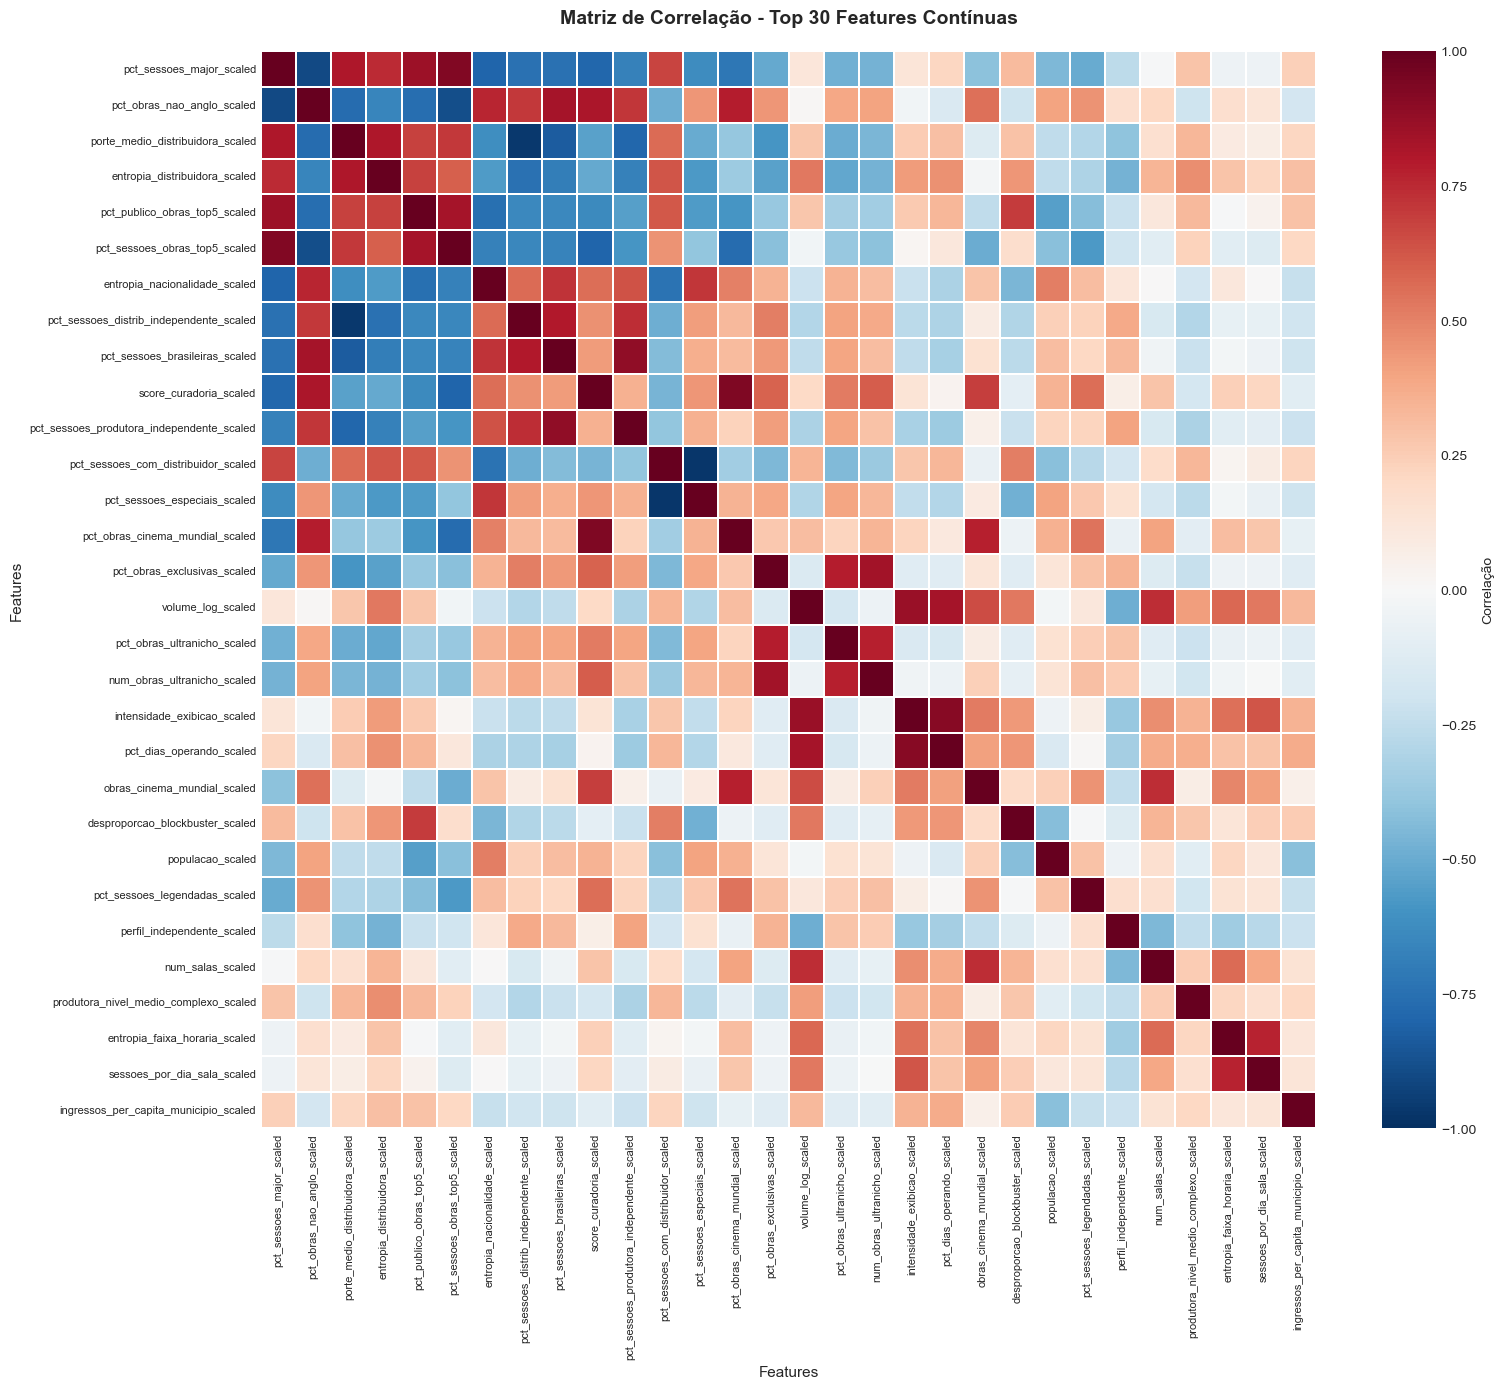


✅ Heatmap gerado com 30 features



In [16]:
##### print("=" * 80)
print("3.2 - MATRIZ DE CORRELAÇÃO (TOP 30 FEATURES CONTÍNUAS)")
print("=" * 80)

# Selecionar apenas features contínuas
features_continuas = [f for f in feature_names_clean if f.endswith('_scaled')]
X_continuas_df = X_df[features_continuas]

print(f"\nTotal de features contínuas: {len(features_continuas)}")

# Calcular correlação
corr_matrix = X_continuas_df.corr()

# Identificar top 30 features por variância das correlações
# (features que mais variam em correlação com outras = mais interessantes)
corr_variance = corr_matrix.var(axis=1).sort_values(ascending=False)
top_30_features = corr_variance.head(30).index.tolist()

print(f"\nTop 30 features selecionadas por variância de correlação:")
for i, feat in enumerate(top_30_features, 1):
    var_corr = corr_variance[feat]
    print(f"   {i:2d}. {feat:45s} (var_corr: {var_corr:.4f})")

# Matriz de correlação reduzida (top 30)
corr_top30 = corr_matrix.loc[top_30_features, top_30_features]

# Identificar correlações altas
print(f"\n{'─' * 80}")
print("CORRELAÇÕES ALTAS (|r| > 0.8):")
print(f"{'─' * 80}")

correlacoes_altas = []
for i in range(len(top_30_features)):
    for j in range(i+1, len(top_30_features)):
        feat_i = top_30_features[i]
        feat_j = top_30_features[j]
        corr_val = corr_top30.iloc[i, j]
        if abs(corr_val) > 0.8:
            correlacoes_altas.append((feat_i, feat_j, corr_val))

if len(correlacoes_altas) > 0:
    correlacoes_altas_sorted = sorted(correlacoes_altas, key=lambda x: abs(x[2]), reverse=True)
    for feat_i, feat_j, corr_val in correlacoes_altas_sorted:
        sinal = "+" if corr_val > 0 else "-"
        print(f"   {sinal} {feat_i:40s} × {feat_j:40s}: {corr_val:+.3f}")
else:
    print("   ✅ Nenhuma correlação |r| > 0.8 encontrada (multicolinearidade baixa)")

# Visualização - Heatmap
fig, ax = plt.subplots(figsize=(16, 14))

sns.heatmap(
    corr_top30,
    annot=False,
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlação'},
    linewidths=0.1,
    linecolor='white',
    ax=ax
)

plt.title('Matriz de Correlação - Top 30 Features Contínuas', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Features', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

print(f"\n✅ Heatmap gerado com {len(top_30_features)} features")

print("\n" + "=" * 80)

## 3.2 PCA Exploratória

3.3 - PCA EXPLORATÓRIA

PCA aplicado ao espaço refinado:
   • Shape da matriz: (894, 49)
   • Componentes calculados: 49

────────────────────────────────────────────────────────────────────────────────
VARIÂNCIA EXPLICADA (primeiros 20 componentes):
────────────────────────────────────────────────────────────────────────────────
   PC 1: 32.20%  (acumulado: 32.20%)
   PC 2: 16.75%  (acumulado: 48.94%)
   PC 3:  6.54%  (acumulado: 55.49%)
   PC 4:  5.25%  (acumulado: 60.74%)
   PC 5:  4.67%  (acumulado: 65.40%)
   PC 6:  3.67%  (acumulado: 69.07%)
   PC 7:  3.16%  (acumulado: 72.23%)
   PC 8:  2.83%  (acumulado: 75.06%)
   PC 9:  2.73%  (acumulado: 77.79%)
   PC10:  2.55%  (acumulado: 80.34%)

════════════════════════════════════════════════════════════════════════════════
   PC1 + PC2: 48.94% da variância
════════════════════════════════════════════════════════════════════════════════

   Exploratório (NB 4): PC1+PC2 = 45.77%
   Refinado (NB 4.1):   PC1+PC2 = 48.94%
   → Espaço refina

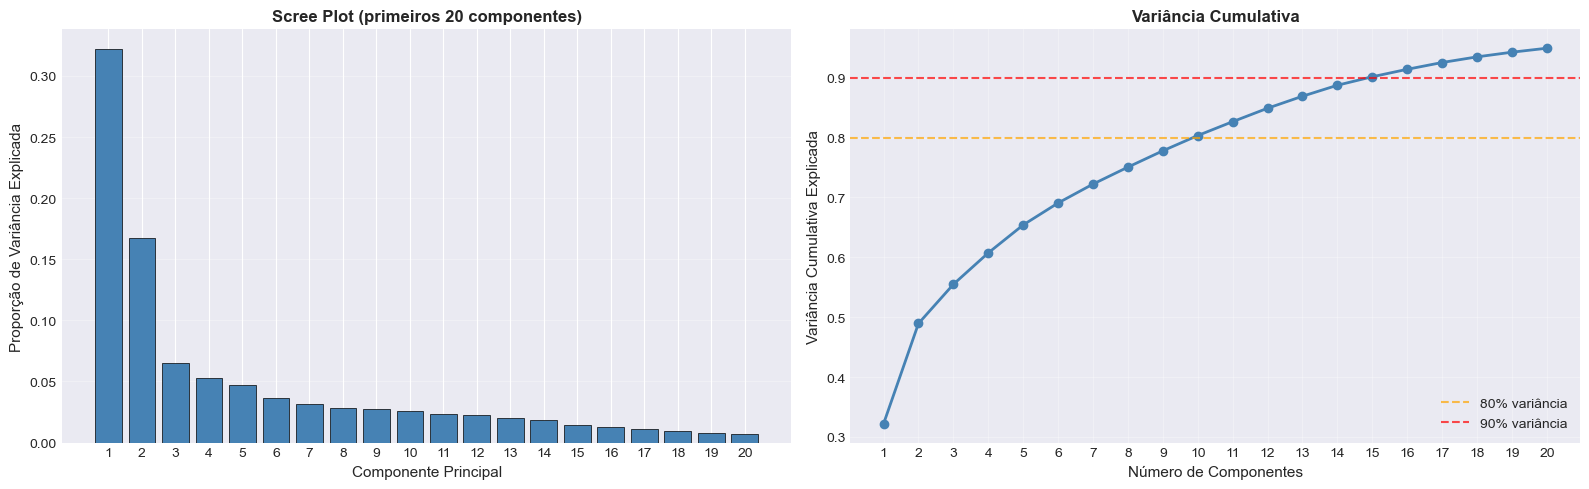


✅ Scree plot e variância cumulativa gerados



In [17]:
print("=" * 80)
print("3.3 - PCA EXPLORATÓRIA")
print("=" * 80)

# Aplicar PCA com todos os componentes
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_final)

n_components = min(20, len(pca_full.explained_variance_ratio_))

print(f"\nPCA aplicado ao espaço refinado:")
print(f"   • Shape da matriz: {X_final.shape}")
print(f"   • Componentes calculados: {len(pca_full.explained_variance_ratio_)}")

# Variância explicada pelos primeiros componentes
print(f"\n{'─' * 80}")
print(f"VARIÂNCIA EXPLICADA (primeiros {n_components} componentes):")
print(f"{'─' * 80}")

for i in range(min(10, n_components)):
    var_exp = pca_full.explained_variance_ratio_[i]
    var_cum = pca_full.explained_variance_ratio_[:i+1].sum()
    print(f"   PC{i+1:2d}: {var_exp:6.2%}  (acumulado: {var_cum:6.2%})")

# PC1 + PC2
var_pc1_pc2 = pca_full.explained_variance_ratio_[:2].sum()
print(f"\n{'═' * 80}")
print(f"   PC1 + PC2: {var_pc1_pc2:.2%} da variância")
print(f"{'═' * 80}")

# Comparação com Notebook 4 (45.77%)
print(f"\n   Exploratório (NB 4): PC1+PC2 = 45.77%")
print(f"   Refinado (NB 4.1):   PC1+PC2 = {var_pc1_pc2:.2%}")
if var_pc1_pc2 > 0.4577:
    diff = var_pc1_pc2 - 0.4577
    print(f"   → Espaço refinado é {diff:.1%} MAIS compacto em 2D")
else:
    diff = 0.4577 - var_pc1_pc2
    print(f"   → Espaço refinado é {diff:.1%} MENOS compacto em 2D")

# Quantos componentes para 90%?
var_cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(var_cumsum >= 0.90) + 1

print(f"\n{'─' * 80}")
print(f"COMPONENTES NECESSÁRIOS:")
print(f"{'─' * 80}")
print(f"   Para 80% da variância: {np.argmax(var_cumsum >= 0.80) + 1} componentes")
print(f"   Para 90% da variância: {n_90} componentes")
print(f"   Para 95% da variância: {np.argmax(var_cumsum >= 0.95) + 1} componentes")

# Visualizações
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
ax1.bar(range(1, n_components+1), pca_full.explained_variance_ratio_[:n_components], 
        color='steelblue', edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Componente Principal', fontsize=11)
ax1.set_ylabel('Proporção de Variância Explicada', fontsize=11)
ax1.set_title(f'Scree Plot (primeiros {n_components} componentes)', 
              fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3, axis='y')
ax1.set_xticks(range(1, n_components+1))

# Variância cumulativa
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_[:n_components])
ax2.plot(range(1, n_components+1), cumsum_var, marker='o', linewidth=2, 
         markersize=6, color='steelblue')
ax2.axhline(y=0.80, color='orange', linestyle='--', alpha=0.7, label='80% variância')
ax2.axhline(y=0.90, color='red', linestyle='--', alpha=0.7, label='90% variância')
ax2.set_xlabel('Número de Componentes', fontsize=11)
ax2.set_ylabel('Variância Cumulativa Explicada', fontsize=11)
ax2.set_title('Variância Cumulativa', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)
ax2.set_xticks(range(1, n_components+1))

plt.tight_layout()
plt.show()

print(f"\n✅ Scree plot e variância cumulativa gerados")

print("\n" + "=" * 80)

## 3.4 Visualização PCA 2D (Sem Clusters)

3.4 - VISUALIZAÇÃO PCA 2D (SEM CLUSTERS)

PCA 2D aplicado:
   • PC1: 32.20% da variância
   • PC2: 16.75% da variância
   • Total (PC1+PC2): 48.94%


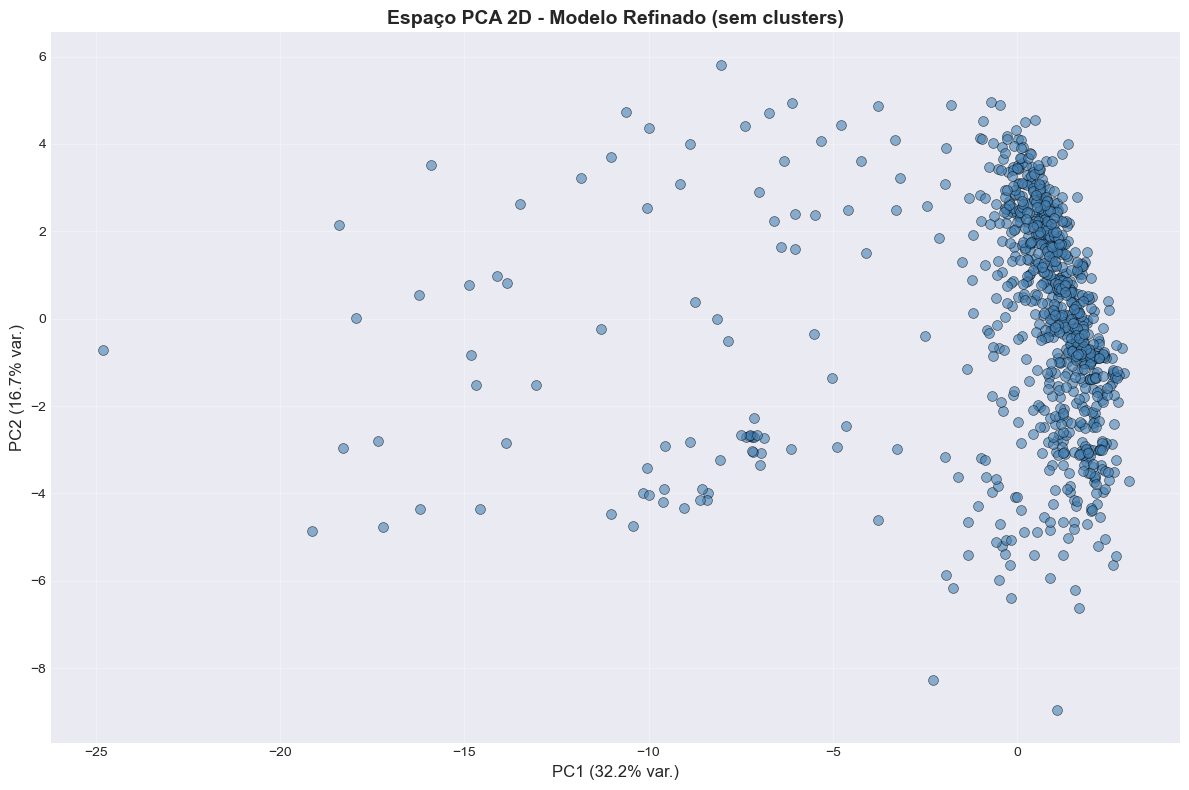


✅ Scatter plot PCA 2D gerado
   Total de complexos plotados: 894



In [18]:
print("=" * 80)
print("3.4 - VISUALIZAÇÃO PCA 2D (SEM CLUSTERS)")
print("=" * 80)

# Aplicar PCA 2D
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_final)

var_pc1 = pca_2d.explained_variance_ratio_[0]
var_pc2 = pca_2d.explained_variance_ratio_[1]
var_total = var_pc1 + var_pc2

print(f"\nPCA 2D aplicado:")
print(f"   • PC1: {var_pc1:.2%} da variância")
print(f"   • PC2: {var_pc2:.2%} da variância")
print(f"   • Total (PC1+PC2): {var_total:.2%}")

# Visualização
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
           alpha=0.6, s=50, c='steelblue', edgecolors='k', linewidths=0.5)

ax.set_xlabel(f'PC1 ({var_pc1:.1%} var.)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_pc2:.1%} var.)', fontsize=12)
ax.set_title('Espaço PCA 2D - Modelo Refinado (sem clusters)', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Scatter plot PCA 2D gerado")
print(f"   Total de complexos plotados: {len(X_pca_2d)}")

print("\n" + "=" * 80)

## 3.5 Exploração Sistemática de k (4-8)

In [19]:
print("=" * 80)
print("3.5 - EXPLORAÇÃO SISTEMÁTICA DE k (4-8)")
print("=" * 80)

# Definir faixa de k a explorar
k_values = range(4, 9)  # k = 4, 5, 6, 7, 8

# Armazenar métricas
results = {
    'k': [],
    'inercia': [],
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': []
}

# Armazenar modelos (para análise posterior se necessário)
modelos_kmeans_refinado = {}

print(f"\nTestando k de {min(k_values)} a {max(k_values)}...\n")

for k in k_values:
    print(f"  Testando k={k}...", end=" ")
    
    # Treinar KMeans
    kmeans = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
        max_iter=500
    )
    labels = kmeans.fit_predict(X_final)
    
    # Calcular métricas
    inercia = kmeans.inertia_
    silhouette = silhouette_score(X_final, labels)
    davies_bouldin = davies_bouldin_score(X_final, labels)
    calinski = calinski_harabasz_score(X_final, labels)
    
    # Armazenar
    results['k'].append(k)
    results['inercia'].append(inercia)
    results['silhouette'].append(silhouette)
    results['davies_bouldin'].append(davies_bouldin)
    results['calinski_harabasz'].append(calinski)
    
    modelos_kmeans_refinado[k] = kmeans
    
    print(f"✓ (Silhouette: {silhouette:.4f})")

# Criar DataFrame com resultados
df_metricas_refinado = pd.DataFrame(results)

print("\n" + "=" * 80)
print("MÉTRICAS DO MODELO REFINADO:")
print("=" * 80)
display(df_metricas_refinado)

print("\n✅ Exploração concluída - 5 modelos treinados")
print("=" * 80)

3.5 - EXPLORAÇÃO SISTEMÁTICA DE k (4-8)

Testando k de 4 a 8...

  Testando k=4... ✓ (Silhouette: 0.2071)
  Testando k=5... ✓ (Silhouette: 0.1619)
  Testando k=6... ✓ (Silhouette: 0.1712)
  Testando k=7... ✓ (Silhouette: 0.1605)
  Testando k=8... ✓ (Silhouette: 0.1694)

MÉTRICAS DO MODELO REFINADO:


,k,inercia,silhouette,davies_bouldin,calinski_harabasz
0,4,19054.0648,0.2071,1.7338,213.4739
1,5,17850.7248,0.1619,1.8755,185.6885
2,6,16701.8282,0.1712,1.7399,170.8077
3,7,15817.2812,0.1605,1.6103,158.3978
4,8,15155.3296,0.1694,1.5369,147.0682



✅ Exploração concluída - 5 modelos treinados


## 3.6 Visualizações das Métricas

3.6 - VISUALIZAÇÕES DAS MÉTRICAS


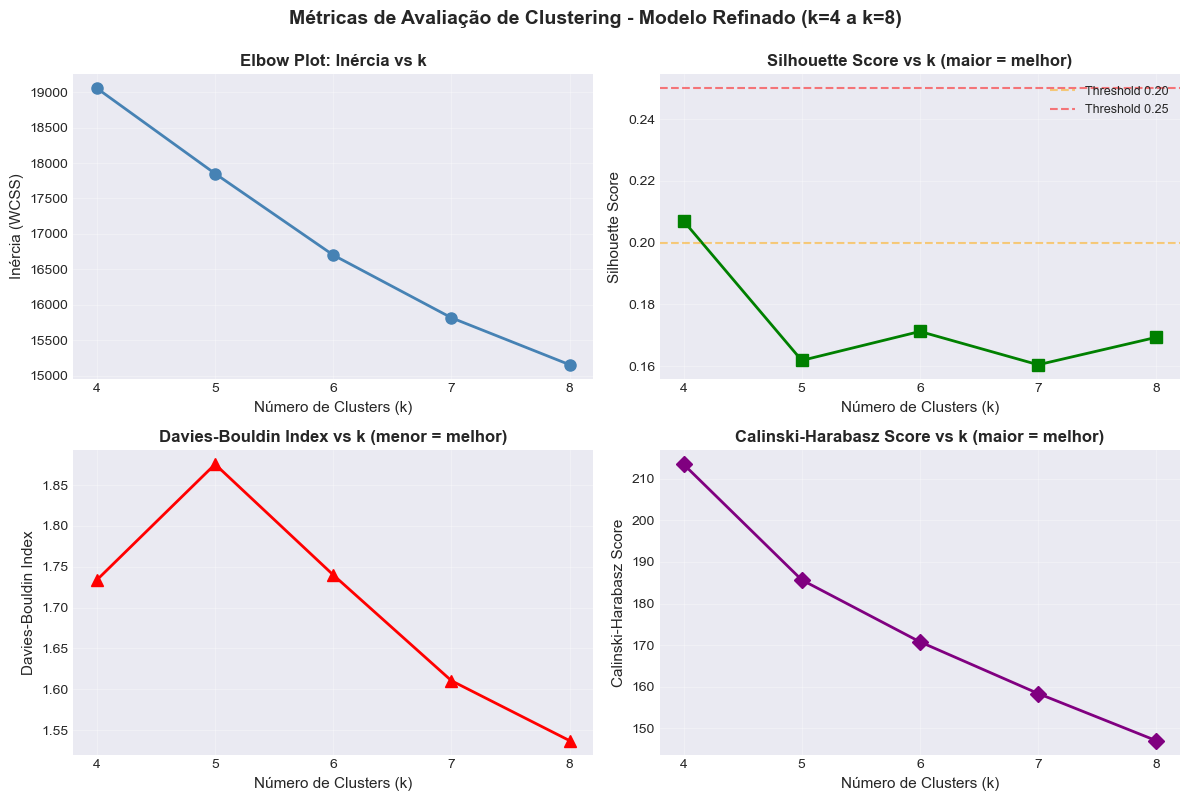


✅ Gráficos de métricas gerados


In [20]:
print("=" * 80)
print("3.6 - VISUALIZAÇÕES DAS MÉTRICAS")
print("=" * 80)

# Criar figura com 4 subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Métricas de Avaliação de Clustering - Modelo Refinado (k=4 a k=8)', 
             fontsize=14, fontweight='bold', y=0.995)

# 1. Elbow Plot (Inércia)
ax1 = axes[0, 0]
ax1.plot(df_metricas_refinado['k'], df_metricas_refinado['inercia'], 
         marker='o', linewidth=2, markersize=8, color='steelblue')
ax1.set_xlabel('Número de Clusters (k)', fontsize=11)
ax1.set_ylabel('Inércia (WCSS)', fontsize=11)
ax1.set_title('Elbow Plot: Inércia vs k', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xticks(df_metricas_refinado['k'])

# 2. Silhouette Score
ax2 = axes[0, 1]
ax2.plot(df_metricas_refinado['k'], df_metricas_refinado['silhouette'], 
         marker='s', linewidth=2, markersize=8, color='green')
ax2.axhline(y=0.20, color='orange', linestyle='--', alpha=0.5, label='Threshold 0.20')
ax2.axhline(y=0.25, color='red', linestyle='--', alpha=0.5, label='Threshold 0.25')
ax2.set_xlabel('Número de Clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score vs k (maior = melhor)', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_xticks(df_metricas_refinado['k'])

# 3. Davies-Bouldin Index
ax3 = axes[1, 0]
ax3.plot(df_metricas_refinado['k'], df_metricas_refinado['davies_bouldin'], 
         marker='^', linewidth=2, markersize=8, color='red')
ax3.set_xlabel('Número de Clusters (k)', fontsize=11)
ax3.set_ylabel('Davies-Bouldin Index', fontsize=11)
ax3.set_title('Davies-Bouldin Index vs k (menor = melhor)', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)
ax3.set_xticks(df_metricas_refinado['k'])

# 4. Calinski-Harabasz Score
ax4 = axes[1, 1]
ax4.plot(df_metricas_refinado['k'], df_metricas_refinado['calinski_harabasz'], 
         marker='D', linewidth=2, markersize=8, color='purple')
ax4.set_xlabel('Número de Clusters (k)', fontsize=11)
ax4.set_ylabel('Calinski-Harabasz Score', fontsize=11)
ax4.set_title('Calinski-Harabasz Score vs k (maior = melhor)', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)
ax4.set_xticks(df_metricas_refinado['k'])

plt.tight_layout()
plt.show()

print("\n✅ Gráficos de métricas gerados")
print("=" * 80)

## 3.7 Comparação Detalhada com Modelo Exploratório

In [21]:
print("=" * 80)
print("3.7 - COMPARAÇÃO DETALHADA: EXPLORATÓRIO vs REFINADO")
print("=" * 80)

# Dados do modelo exploratório (Notebook 4) - hardcoded conforme imagem fornecida
df_metricas_exploratorio = pd.DataFrame({
    'k': [4, 5, 6, 7, 8],
    'inercia': [20465.7541, 18772.3107, 17481.3045, 16253.6844, 15326.9371],
    'silhouette': [0.1916, 0.1991, 0.2024, 0.1488, 0.1630],
    'davies_bouldin': [1.3458, 1.1369, 1.2741, 1.4289, 1.4756],
    'calinski_harabasz': [194.3280, 178.9008, 166.7230, 160.5035, 153.4345]
})

print("\n" + "=" * 80)
print("TABELA 1: MODELO EXPLORATÓRIO (Notebook 4)")
print("=" * 80)
display(df_metricas_exploratorio)

print("\n" + "=" * 80)
print("TABELA 2: MODELO REFINADO (Notebook 4.1)")
print("=" * 80)
display(df_metricas_refinado)

# Calcular diferenças (Δ = Refinado - Exploratório)
df_comparacao = pd.DataFrame({
    'k': df_metricas_refinado['k'],
    'Silhouette_Exp': df_metricas_exploratorio['silhouette'],
    'Silhouette_Ref': df_metricas_refinado['silhouette'],
    'Δ_Silhouette': df_metricas_refinado['silhouette'] - df_metricas_exploratorio['silhouette'],
    'Δ%_Silhouette': ((df_metricas_refinado['silhouette'] - df_metricas_exploratorio['silhouette']) / 
                      df_metricas_exploratorio['silhouette'] * 100),
    'Davies_Exp': df_metricas_exploratorio['davies_bouldin'],
    'Davies_Ref': df_metricas_refinado['davies_bouldin'],
    'Δ_Davies': df_metricas_refinado['davies_bouldin'] - df_metricas_exploratorio['davies_bouldin'],
    'Calinski_Exp': df_metricas_exploratorio['calinski_harabasz'],
    'Calinski_Ref': df_metricas_refinado['calinski_harabasz'],
    'Δ_Calinski': df_metricas_refinado['calinski_harabasz'] - df_metricas_exploratorio['calinski_harabasz']
})

print("\n" + "=" * 80)
print("TABELA 3: COMPARAÇÃO DETALHADA (Δ = Refinado - Exploratório)")
print("=" * 80)
display(df_comparacao)

# Análise textual
print("\n" + "=" * 80)
print("ANÁLISE COMPARATIVA POR MÉTRICA:")
print("=" * 80)

print("\n📊 SILHOUETTE SCORE (maior = melhor):")
print("─" * 80)
for idx, row in df_comparacao.iterrows():
    k = int(row['k'])
    delta = row['Δ_Silhouette']
    delta_pct = row['Δ%_Silhouette']
    
    if delta > 0:
        status = "✅ MELHORA"
        emoji = "📈"
    elif delta < -0.01:
        status = "❌ PIORA"
        emoji = "📉"
    else:
        status = "≈ IGUAL"
        emoji = "➡️"
    
    print(f"   k={k}: {row['Silhouette_Exp']:.4f} → {row['Silhouette_Ref']:.4f} "
          f"({delta:+.4f}, {delta_pct:+.1f}%)  {emoji} {status}")

print("\n📊 DAVIES-BOULDIN INDEX (menor = melhor):")
print("─" * 80)
for idx, row in df_comparacao.iterrows():
    k = int(row['k'])
    delta = row['Δ_Davies']
    
    if delta < 0:
        status = "✅ MELHORA"
        emoji = "📈"
    elif delta > 0.1:
        status = "❌ PIORA"
        emoji = "📉"
    else:
        status = "≈ IGUAL"
        emoji = "➡️"
    
    print(f"   k={k}: {row['Davies_Exp']:.4f} → {row['Davies_Ref']:.4f} "
          f"({delta:+.4f})  {emoji} {status}")

print("\n📊 CALINSKI-HARABASZ SCORE (maior = melhor):")
print("─" * 80)
for idx, row in df_comparacao.iterrows():
    k = int(row['k'])
    delta = row['Δ_Calinski']
    
    if delta > 0:
        status = "✅ MELHORA"
        emoji = "📈"
    elif delta < -10:
        status = "❌ PIORA"
        emoji = "📉"
    else:
        status = "≈ IGUAL"
        emoji = "➡️"
    
    print(f"   k={k}: {row['Calinski_Exp']:.2f} → {row['Calinski_Ref']:.2f} "
          f"({delta:+.2f})  {emoji} {status}")

# Identificar melhor k em cada modelo
print("\n" + "=" * 80)
print("MELHOR k POR MÉTRICA:")
print("=" * 80)

best_sil_exp_idx = df_metricas_exploratorio['silhouette'].idxmax()
best_sil_ref_idx = df_metricas_refinado['silhouette'].idxmax()
best_dav_exp_idx = df_metricas_exploratorio['davies_bouldin'].idxmin()
best_dav_ref_idx = df_metricas_refinado['davies_bouldin'].idxmin()
best_cal_exp_idx = df_metricas_exploratorio['calinski_harabasz'].idxmax()
best_cal_ref_idx = df_metricas_refinado['calinski_harabasz'].idxmax()

k_best_sil_exp = int(df_metricas_exploratorio.loc[best_sil_exp_idx, 'k'])
k_best_sil_ref = int(df_metricas_refinado.loc[best_sil_ref_idx, 'k'])
k_best_dav_exp = int(df_metricas_exploratorio.loc[best_dav_exp_idx, 'k'])
k_best_dav_ref = int(df_metricas_refinado.loc[best_dav_ref_idx, 'k'])
k_best_cal_exp = int(df_metricas_exploratorio.loc[best_cal_exp_idx, 'k'])
k_best_cal_ref = int(df_metricas_refinado.loc[best_cal_ref_idx, 'k'])

print(f"\n   Silhouette (maior):      Exploratório k={k_best_sil_exp}  |  Refinado k={k_best_sil_ref}")
print(f"   Davies-Bouldin (menor):  Exploratório k={k_best_dav_exp}  |  Refinado k={k_best_dav_ref}")
print(f"   Calinski (maior):        Exploratório k={k_best_cal_exp}  |  Refinado k={k_best_cal_ref}")

print("\n" + "=" * 80)

3.7 - COMPARAÇÃO DETALHADA: EXPLORATÓRIO vs REFINADO

TABELA 1: MODELO EXPLORATÓRIO (Notebook 4)


,k,inercia,silhouette,davies_bouldin,calinski_harabasz
0,4,20465.7541,0.1916,1.3458,194.3280
1,5,18772.3107,0.1991,1.1369,178.9008
2,6,17481.3045,0.2024,1.2741,166.7230
3,7,16253.6844,0.1488,1.4289,160.5035
4,8,15326.9371,0.1630,1.4756,153.4345



TABELA 2: MODELO REFINADO (Notebook 4.1)


,k,inercia,silhouette,davies_bouldin,calinski_harabasz
0,4,19054.0648,0.2071,1.7338,213.4739
1,5,17850.7248,0.1619,1.8755,185.6885
2,6,16701.8282,0.1712,1.7399,170.8077
3,7,15817.2812,0.1605,1.6103,158.3978
4,8,15155.3296,0.1694,1.5369,147.0682



TABELA 3: COMPARAÇÃO DETALHADA (Δ = Refinado - Exploratório)


,k,Silhouette_Exp,Silhouette_Ref,Δ_Silhouette,Δ%_Silhouette,Davies_Exp,Davies_Ref,Δ_Davies,Calinski_Exp,Calinski_Ref,Δ_Calinski
0,4,0.1916,0.2071,0.0155,8.0646,1.3458,1.7338,0.3880,194.3280,213.4739,19.1459
1,5,0.1991,0.1619,-0.0372,-18.7035,1.1369,1.8755,0.7386,178.9008,185.6885,6.7877
2,6,0.2024,0.1712,-0.0312,-15.3906,1.2741,1.7399,0.4658,166.7230,170.8077,4.0847
3,7,0.1488,0.1605,0.0117,7.8417,1.4289,1.6103,0.1814,160.5035,158.3978,-2.1057
4,8,0.1630,0.1694,0.0064,3.8987,1.4756,1.5369,0.0613,153.4345,147.0682,-6.3663



ANÁLISE COMPARATIVA POR MÉTRICA:

📊 SILHOUETTE SCORE (maior = melhor):
────────────────────────────────────────────────────────────────────────────────
   k=4: 0.1916 → 0.2071 (+0.0155, +8.1%)  📈 ✅ MELHORA
   k=5: 0.1991 → 0.1619 (-0.0372, -18.7%)  📉 ❌ PIORA
   k=6: 0.2024 → 0.1712 (-0.0312, -15.4%)  📉 ❌ PIORA
   k=7: 0.1488 → 0.1605 (+0.0117, +7.8%)  📈 ✅ MELHORA
   k=8: 0.1630 → 0.1694 (+0.0064, +3.9%)  📈 ✅ MELHORA

📊 DAVIES-BOULDIN INDEX (menor = melhor):
────────────────────────────────────────────────────────────────────────────────
   k=4: 1.3458 → 1.7338 (+0.3880)  📉 ❌ PIORA
   k=5: 1.1369 → 1.8755 (+0.7386)  📉 ❌ PIORA
   k=6: 1.2741 → 1.7399 (+0.4658)  📉 ❌ PIORA
   k=7: 1.4289 → 1.6103 (+0.1814)  📉 ❌ PIORA
   k=8: 1.4756 → 1.5369 (+0.0613)  ➡️ ≈ IGUAL

📊 CALINSKI-HARABASZ SCORE (maior = melhor):
────────────────────────────────────────────────────────────────────────────────
   k=4: 194.33 → 213.47 (+19.15)  📈 ✅ MELHORA
   k=5: 178.90 → 185.69 (+6.79)  📈 ✅ MELHORA
   k=6: 166.7

## 3.8 Análise Detalhada de Candidatos + Decisão

In [22]:
print("=" * 80)
print("3.8 - ANÁLISE DETALHADA DOS CANDIDATOS E DECISÃO DE k_final")
print("=" * 80)

# Melhor k por métrica
best_sil = int(df_metricas_refinado.loc[df_metricas_refinado['silhouette'].idxmax(), 'k'])
best_dav = int(df_metricas_refinado.loc[df_metricas_refinado['davies_bouldin'].idxmin(), 'k'])
best_cal = int(df_metricas_refinado.loc[df_metricas_refinado['calinski_harabasz'].idxmax(), 'k'])

print(f"\n{'═' * 80}")
print("MELHOR k POR MÉTRICA:")
print(f"{'═' * 80}")
print(f"   Silhouette:     k={best_sil}")
print(f"   Davies-Bouldin: k={best_dav}")
print(f"   Calinski:       k={best_cal}")

# Placar
vitorias = {}
for k in df_metricas_refinado['k'].values:
    vitorias[int(k)] = 0
vitorias[best_sil] += 1
vitorias[best_dav] += 1
vitorias[best_cal] += 1

print(f"\n{'─' * 80}")
print("PLACAR:")
print(f"{'─' * 80}")
for k, wins in sorted(vitorias.items(), key=lambda x: x[1], reverse=True):
    emoji = "🏆" if wins == 3 else "🥇" if wins == 2 else "🥉" if wins == 1 else ""
    print(f"   k={k}: {wins} vitória(s) {emoji}")

# Distribuição detalhada
print(f"\n{'═' * 80}")
print("DISTRIBUIÇÃO DE COMPLEXOS POR CLUSTER:")
print(f"{'═' * 80}")

for k in df_metricas_refinado['k'].values:
    labels = modelos_kmeans_refinado[int(k)].labels_
    counts = pd.Series(labels).value_counts().sort_index()
    pcts = (counts / len(labels) * 100).round(1)
    
    print(f"\n{'─' * 80}")
    print(f"k = {int(k)} clusters:")
    print(f"{'─' * 80}")
    
    for cluster_id in range(int(k)):
        n = counts.get(cluster_id, 0)
        p = pcts.get(cluster_id, 0.0)
        
        if n == 1:
            emoji = "🔴"
            obs = "SINGLETON"
        elif n < 20:
            emoji = "🟡"
            obs = "Pequeno"
        elif p > 40:
            emoji = "🔵"
            obs = "Grande"
        else:
            emoji = "🟢"
            obs = ""
        
        print(f"   Cluster {cluster_id}: {n:3d} ({p:5.1f}%)  {emoji} {obs}")

# Recomendação
k_rec = max(vitorias.items(), key=lambda x: x[1])[0]
labels_rec = modelos_kmeans_refinado[k_rec].labels_
tem_sing = (pd.Series(labels_rec).value_counts() == 1).any()

print(f"\n{'═' * 80}")
print(f"RECOMENDAÇÃO: k={k_rec}")
if tem_sing:
    print(f"   ⚠️  Contém singleton - considere remover e re-treinar")
print(f"{'═' * 80}")

k_final = k_rec

print(f"\n✅ k_final = {k_final}")
print("=" * 80)

3.8 - ANÁLISE DETALHADA DOS CANDIDATOS E DECISÃO DE k_final

════════════════════════════════════════════════════════════════════════════════
MELHOR k POR MÉTRICA:
════════════════════════════════════════════════════════════════════════════════
   Silhouette:     k=4
   Davies-Bouldin: k=8
   Calinski:       k=4

────────────────────────────────────────────────────────────────────────────────
PLACAR:
────────────────────────────────────────────────────────────────────────────────
   k=4: 2 vitória(s) 🥇
   k=8: 1 vitória(s) 🥉
   k=5: 0 vitória(s) 
   k=6: 0 vitória(s) 
   k=7: 0 vitória(s) 

════════════════════════════════════════════════════════════════════════════════
DISTRIBUIÇÃO DE COMPLEXOS POR CLUSTER:
════════════════════════════════════════════════════════════════════════════════

────────────────────────────────────────────────────────────────────────────────
k = 4 clusters:
────────────────────────────────────────────────────────────────────────────────
   Cluster 0:  52 (  5

In [23]:
print("=" * 80)
print("3.8.1 - IDENTIFICAÇÃO DO COMPLEXO ISOLADO (SINGLETON)")
print("=" * 80)

singletons_info = []

for k in range(4, 9):
    labels = modelos_kmeans_refinado[k].labels_
    cluster_counts = pd.Series(labels).value_counts()
    singleton_clusters = cluster_counts[cluster_counts == 1].index.tolist()
    
    if singleton_clusters:
        for cluster_id in singleton_clusters:
            idx = np.where(labels == cluster_id)[0][0]
            registro = df_features_clean.iloc[idx]['REGISTRO_COMPLEXO']
            singletons_info.append({'k': k, 'cluster': cluster_id, 'registro': registro})
            print(f"   k={k}, Cluster {cluster_id}: registro={registro}")

if not singletons_info:
    print("   ✅ Nenhum singleton")
else:
    unique = list(set([s['registro'] for s in singletons_info]))
    print(f"\n{'─' * 80}")
    
    if len(unique) == 1:
        print(f"⚠️  SEMPRE O MESMO: {unique[0]} ({len(singletons_info)} vezes)")
        registro_problema = unique[0]
    else:
        print(f"⚠️  MÚLTIPLOS: {len(unique)} diferentes")
        registro_problema = unique[0]
    
    print(f"\n{'═' * 80}")
    print("INFORMAÇÕES CADASTRAIS:")
    print(f"{'═' * 80}")
    
    cadastro_filtrado = df_cadastro_complexos[df_cadastro_complexos['REGISTRO_COMPLEXO'] == registro_problema]
    
    if len(cadastro_filtrado) == 0:
        print(f"\n❌ REGISTRO {registro_problema} NÃO ENCONTRADO NO CADASTRO ANCINE")
    else:
        info = cadastro_filtrado.iloc[0]
        
        print(f"\n📍 {info['NOME_COMPLEXO']}")
        print(f"   {info['MUNICIPIO_COMPLEXO']}/{info['UF_COMPLEXO']}")
        print(f"   Operação: {info['OPERACAO_USUAL']}")
        print(f"   Situação: {info['SITUACAO_COMPLEXO']} ({info['DATA_SITUACAO_COMPLEXO']})")
        print(f"   Exibidor: {info['NOME_EXIBIDOR']}")
        print(f"   Grupo: {info['NOME_GRUPO_EXIBIDOR']}")
    
    print(f"\n{'─' * 80}")
    print("TOP 15 FEATURES EXTREMAS:")
    print(f"{'─' * 80}")
    
    idx_array = df_features_clean[df_features_clean['REGISTRO_COMPLEXO'] == registro_problema].index[0]
    features = X_final[idx_array]
    sorted_feats = sorted(zip(feature_names_clean, features), key=lambda x: abs(x[1]), reverse=True)
    
    for i, (feat, val) in enumerate(sorted_feats[:15], 1):
        emoji = "🔴" if val > 3 else "🔵" if val < -3 else "🟡" if abs(val) > 2 else "🟢"
        print(f"   {i:2d}. {feat:45s}: {val:+7.2f}  {emoji}")

print("\n" + "=" * 80)

3.8.1 - IDENTIFICAÇÃO DO COMPLEXO ISOLADO (SINGLETON)
   ✅ Nenhum singleton



# 4 Seleção avançada de features

## 4.1 Matriz de Correlação

In [87]:
# Matriz de correlação
corr_matrix = np.corrcoef(X_final.T)

# Encontrar pares altamente correlacionados
threshold = 0.85
pares_redundantes = []

for i in range(len(feature_names_clean)):
    for j in range(i+1, len(feature_names_clean)):
        corr_val = abs(corr_matrix[i, j])
        if corr_val > threshold:
            pares_redundantes.append({
                'feat1': feature_names_clean[i],
                'feat2': feature_names_clean[j],
                'corr': corr_matrix[i, j],
                'corr_abs': corr_val
            })

df_corr = pd.DataFrame(pares_redundantes).sort_values('corr_abs', ascending=False)

print(f"Pares com |correlação| > {threshold}:")
display(df_corr)

print("\n🎯 AÇÃO: De cada par, remova a feature MENOS interpretável")

Pares com |correlação| > 0.85:


,feat1,feat2,corr,corr_abs
6,pct_sessoes_com_distribuidor_scaled,pct_sessoes_especiais_scaled,-0.9728,0.9728
5,pct_sessoes_distrib_independente_scaled,porte_medio_distribuidora_scaled,-0.9649,0.9649
10,perfil_independente_scaled,exibidor_independente,0.9580,0.9580
9,pct_obras_cinema_mundial_scaled,score_curadoria_scaled,0.9336,0.9336
3,pct_sessoes_major_scaled,pct_sessoes_obras_top5_scaled,0.9252,0.9252
0,pct_dias_operando_scaled,intensidade_exibicao_scaled,0.9092,0.9092
4,pct_sessoes_major_scaled,pct_obras_nao_anglo_scaled,-0.9062,0.9062
7,pct_sessoes_produtora_independente_scaled,pct_sessoes_brasileiras_scaled,0.8876,0.8876
8,pct_sessoes_obras_top5_scaled,pct_obras_nao_anglo_scaled,-0.8853,0.8853
1,volume_log_scaled,intensidade_exibicao_scaled,0.8645,0.8645



🎯 AÇÃO: De cada par, remova a feature MENOS interpretável


In [88]:
# Baseline (todas features)
kmeans_base = KMeans(n_clusters=6, random_state=42, n_init=20)
labels_base = kmeans_base.fit_predict(X_final)
sil_base = silhouette_score(X_final, labels_base)

print(f"Silhouette baseline (50 features): {sil_base:.4f}\n")

# Testar remoção de cada feature
importancias = []

for i, feat in enumerate(feature_names_clean):
    # Remover feature i
    X_temp = np.delete(X_final, i, axis=1)
    
    # Re-clusterizar
    kmeans_temp = KMeans(n_clusters=6, random_state=42, n_init=20)
    labels_temp = kmeans_temp.fit_predict(X_temp)
    sil_temp = silhouette_score(X_temp, labels_temp)
    
    delta = sil_temp - sil_base
    
    importancias.append({
        'feature': feat,
        'silhouette_sem': sil_temp,
        'delta': delta,
        'melhora': 'SIM' if delta > 0 else 'NÃO'
    })
    
    if (i+1) % 10 == 0:
        print(f"Processado {i+1}/{len(feature_names_clean)}...")

df_imp = pd.DataFrame(importancias).sort_values('delta', ascending=False)

print("\n" + "="*80)
print("FEATURES QUE MELHORAM O MODELO SE REMOVIDAS (delta > 0):")
print("="*80)
display(df_imp[df_imp['delta'] > 0])

print("\n" + "="*80)
print("FEATURES QUE MAIS PREJUDICAM SE REMOVIDAS (delta < -0.01):")
print("="*80)
display(df_imp[df_imp['delta'] < -0.01].head(10))

Silhouette baseline (50 features): 0.1712

Processado 10/49...
Processado 20/49...
Processado 30/49...
Processado 40/49...

FEATURES QUE MELHORAM O MODELO SE REMOVIDAS (delta > 0):


,feature,silhouette_sem,delta,melhora
19,pib_per_capita_scaled,0.2064,0.0352,SIM
15,pct_sessoes_legendadas_scaled,0.2062,0.0349,SIM
2,sessoes_por_dia_sala_scaled,0.1757,0.0045,SIM
41,faixa_renda_cat_Media_Baixa,0.1752,0.0040,SIM
37,porte_municipio_cat_Muito_Grande,0.1730,0.0017,SIM
47,natureza_nao_privada,0.1713,0.0000,SIM
44,operacao_nao_comercial,0.1713,0.0000,SIM



FEATURES QUE MAIS PREJUDICAM SE REMOVIDAS (delta < -0.01):


,feature,silhouette_sem,delta,melhora
40,faixa_renda_cat_Media_Alta,0.1600,-0.0112,NÃO
46,exibidor_independente,0.1600,-0.0112,NÃO
23,entropia_faixa_horaria_scaled,0.1598,-0.0114,NÃO
8,pct_sessoes_produtora_independente_scaled,0.1596,-0.0116,NÃO
32,score_curadoria_scaled,0.1595,-0.0117,NÃO
39,faixa_renda_cat_Baixa,0.1594,-0.0119,NÃO
5,pct_sessoes_distrib_independente_scaled,0.1586,-0.0127,NÃO
27,pct_obras_exclusivas_scaled,0.1585,-0.0127,NÃO
13,pct_modalidade_c_scaled,0.1582,-0.0131,NÃO
38,porte_municipio_cat_Pequeno,0.1581,-0.0131,NÃO


In [89]:

# VIF para features contínuas
features_cont_idx = [i for i, f in enumerate(feature_names_clean) if f.endswith('_scaled')]
X_cont = X_final[:, features_cont_idx]
features_cont_nomes = [feature_names_clean[i] for i in features_cont_idx]

vif_data = []
for i in range(X_cont.shape[1]):
    vif = variance_inflation_factor(X_cont, i)
    vif_data.append({'feature': features_cont_nomes[i], 'VIF': vif})

df_vif = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print("VIF (Variance Inflation Factor):")
print("  VIF > 10: Multicolinearidade ALTA ⚠️")
print("  VIF > 5:  Multicolinearidade MODERADA")
display(df_vif)

print("\n🎯 AÇÃO: Remover features com VIF > 10")

VIF (Variance Inflation Factor):
  VIF > 10: Multicolinearidade ALTA ⚠️
  VIF > 5:  Multicolinearidade MODERADA


,feature,VIF
16,pct_publico_obras_top5_scaled,inf
17,pct_sessoes_obras_top5_scaled,inf
10,pct_sessoes_brasileiras_scaled,inf
27,pct_obras_exclusivas_scaled,inf
29,pct_obras_ultranicho_scaled,inf
30,pct_obras_nao_anglo_scaled,inf
31,desproporcao_blockbuster_scaled,inf
32,score_curadoria_scaled,inf
26,pct_obras_cinema_mundial_scaled,inf
33,intensidade_exibicao_scaled,48.8512



🎯 AÇÃO: Remover features com VIF > 10


## 4.2 Remoção de features avançada

## 4.2.1 Rodada 1

In [90]:
features_remover_fase1 = [
    # 1-2: DERIVADAS (combinações matemáticas de outras features)
    'desproporcao_blockbuster_scaled',      # = pct_publico_top5 / pct_sessoes_top5
    'intensidade_exibicao_scaled',          # = sessoes_por_dia_sala × pct_dias_operando
    
    # 3-4: VIF INFINITO + Redundância Comprovada
    'pct_obras_ultranicho_scaled',          # Redundante com num_obras_ultranicho
    'pct_sessoes_obras_top5_scaled',        # Redundante com pct_publico_obras_top5
    
    # 5-6: CORRELAÇÃO ALTA (> 0.95) + VIF Alto
    'pct_sessoes_com_distribuidor_scaled',  # Corr 0.97 com pct_sessoes_especiais
    'porte_medio_distribuidora_scaled',     # Corr 0.96 com pct_sessoes_distrib_independente
]

In [91]:
# Identificar índices
indices_remover = [i for i, f in enumerate(feature_names_clean) 
                   if f in features_remover_fase1]

# Criar novo X
X_fase1 = np.delete(X_final, indices_remover, axis=1)

# Nova lista de features
features_fase1 = [f for f in feature_names_clean 
                  if f not in features_remover_fase1]

print(f"Features removidas: {len(features_remover_fase1)}")
print(f"Features restantes: {len(features_fase1)}")

Features removidas: 6
Features restantes: 43


In [92]:
resultados_fase1 = []

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_fase1)
    
    resultados_fase1.append({
        'k': k,
        'silhouette': silhouette_score(X_fase1, labels),
        'davies_bouldin': davies_bouldin_score(X_fase1, labels),
        'calinski_harabasz': calinski_harabasz_score(X_fase1, labels),
        'inertia': kmeans.inertia_
    })

df_resultados_fase1 = pd.DataFrame(resultados_fase1)
print("\nRESULTADOS FASE 1:")
display(df_resultados_fase1)


RESULTADOS FASE 1:


,k,silhouette,davies_bouldin,calinski_harabasz,inertia
0,4,0.2048,1.7253,197.2463,16458.2271
1,5,0.1629,1.9147,171.4808,15467.0366
2,6,0.1496,1.7000,155.0083,14631.0209
3,7,0.1555,1.6633,142.4482,13954.6104
4,8,0.1608,1.4998,137.4512,13135.8831


In [93]:
# Apenas contínuas
features_cont_fase1 = [f for f in features_fase1 if f.endswith('_scaled')]
idx_cont = [i for i, f in enumerate(features_fase1) if f.endswith('_scaled')]
X_cont_fase1 = X_fase1[:, idx_cont]

vif_fase1 = []
for i in range(len(features_cont_fase1)):
    vif = variance_inflation_factor(X_cont_fase1, i)
    vif_fase1.append({'feature': features_cont_fase1[i], 'VIF': vif})

df_vif_fase1 = pd.DataFrame(vif_fase1).sort_values('VIF', ascending=False)

print("\nVIF APÓS FASE 1:")
print(f"Features com VIF > 30: {len(df_vif_fase1[df_vif_fase1['VIF'] > 30])}")
print(f"Features com VIF = inf: {len(df_vif_fase1[df_vif_fase1['VIF'] == np.inf])}")
display(df_vif_fase1.head(15))


VIF APÓS FASE 1:
Features com VIF > 30: 4
Features com VIF = inf: 3


,feature,VIF
8,pct_sessoes_brasileiras_scaled,inf
23,pct_obras_cinema_mundial_scaled,inf
26,pct_obras_nao_anglo_scaled,inf
27,score_curadoria_scaled,226.6831
24,pct_obras_exclusivas_scaled,25.8811
3,volume_log_scaled,22.7888
4,pct_sessoes_major_scaled,18.8625
0,num_salas_scaled,9.0867
1,pct_dias_operando_scaled,9.0474
22,obras_cinema_mundial_scaled,9.0176


In [94]:
corr_matrix_fase1 = np.corrcoef(X_fase1.T)

# Pares com |corr| > 0.85
pares_fase1 = []
for i in range(len(features_fase1)):
    for j in range(i+1, len(features_fase1)):
        corr_val = abs(corr_matrix_fase1[i, j])
        if corr_val > 0.85:
            pares_fase1.append({
                'feat1': features_fase1[i],
                'feat2': features_fase1[j],
                'corr_abs': corr_val
            })

df_corr_fase1 = pd.DataFrame(pares_fase1).sort_values('corr_abs', ascending=False)

print(f"\nPARES COM |CORRELAÇÃO| > 0.85:")
print(f"Total: {len(df_corr_fase1)}")
display(df_corr_fase1)



PARES COM |CORRELAÇÃO| > 0.85:
Total: 5


,feat1,feat2,corr_abs
4,perfil_independente_scaled,exibidor_independente,0.9580
3,pct_obras_cinema_mundial_scaled,score_curadoria_scaled,0.9336
1,pct_sessoes_major_scaled,pct_obras_nao_anglo_scaled,0.9062
2,pct_sessoes_produtora_independente_scaled,pct_sessoes_brasileiras_scaled,0.8876
0,pct_sessoes_major_scaled,pct_publico_obras_top5_scaled,0.8545


## 4.2.2 Rodada 2

In [95]:
# FASE 2: Remoção de baixa_atividade + features adicionais

print("=" * 80)
print("FASE 2: REMOÇÃO DE COMPLEXOS E FEATURES")
print("=" * 80)

# USAR df_features_clean (894 linhas, alinhado com X_fase1)
mask_baixa_atividade = df_features_clean['baixa_atividade'] == 1  # ← CORREÇÃO AQUI
n_baixa_atividade = mask_baixa_atividade.sum()

print(f"\n📊 Complexos com baixa_atividade=1: {n_baixa_atividade} ({n_baixa_atividade/len(df_features_clean)*100:.1f}%)")

if n_baixa_atividade > 0:
    print("\nComplexos a remover:")
    display(df_features_clean[mask_baixa_atividade][['REGISTRO_COMPLEXO', 'municipio', 'UF']])

# Remover complexos
df_features_fase2 = df_features_clean[~mask_baixa_atividade].copy()
X_fase2_temp = X_fase1[~mask_baixa_atividade.values]

print(f"\n✅ Complexos restantes: {len(df_features_fase2)}")

# Features a remover
features_remover_fase2 = [
    'score_curadoria_scaled',
    'baixa_atividade'
]

print(f"\n📋 Features a remover:")
for feat in features_remover_fase2:
    existe = feat in features_fase1
    print(f"  {'✓' if existe else '✗'} {feat}")

indices_remover_fase2 = [i for i, f in enumerate(features_fase1) if f in features_remover_fase2]

X_fase2 = np.delete(X_fase2_temp, indices_remover_fase2, axis=1)
features_fase2 = [f for f in features_fase1 if f not in features_remover_fase2]

print(f"\n✅ Fase 2 concluída:")
print(f"  Complexos: {X_fase2.shape[0]}")
print(f"  Features: {X_fase2.shape[1]}")

print("\n" + "=" * 80)

FASE 2: REMOÇÃO DE COMPLEXOS E FEATURES

📊 Complexos com baixa_atividade=1: 19 (2.1%)

Complexos a remover:


,REGISTRO_COMPLEXO,municipio,UF
54,15266,CÁCERES,MT
136,19476,UMUARAMA,PR
555,41391,GUANAMBI,BA
607,43979,URUGUAIANA,RS
649,45293,SÃO PAULO,SP
742,52336,LUCAS DO RIO VERDE,MT
813,58670,MONTE CARMELO,MG
826,59894,SÃO PAULO,SP
827,59895,SÃO PAULO,SP
828,59897,SÃO PAULO,SP



✅ Complexos restantes: 875

📋 Features a remover:
  ✓ score_curadoria_scaled
  ✓ baixa_atividade

✅ Fase 2 concluída:
  Complexos: 875
  Features: 41



In [96]:
# Re-clusterização Fase 2

print("=" * 80)
print("CLUSTERIZAÇÃO FASE 2")
print("=" * 80)

resultados_fase2 = []

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_fase2)
    
    sil = silhouette_score(X_fase2, labels)
    db = davies_bouldin_score(X_fase2, labels)
    ch = calinski_harabasz_score(X_fase2, labels)
    
    resultados_fase2.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'inertia': kmeans.inertia_
    })
    
    print(f"k={k}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.1f}")

df_resultados_fase2 = pd.DataFrame(resultados_fase2)

print("\n" + "=" * 80)
print("COMPARAÇÃO FASE 1 vs FASE 2:")
print("=" * 80)

# Comparação Fase 1 vs Fase 2

print("\n" + "=" * 80)
print("COMPARAÇÃO FASE 1 vs FASE 2:")
print("=" * 80)

print(f"\n{'k':>3} | {'Sil_Fase1':>10} | {'Sil_Fase2':>10} | {'Delta':>8}")
print("-" * 40)

for i in range(len(df_resultados_fase1)):
    k = int(df_resultados_fase1.iloc[i]['k'])  # ← Converter aqui
    sil1 = df_resultados_fase1.iloc[i]['silhouette']
    sil2 = df_resultados_fase2.iloc[i]['silhouette']
    delta = sil2 - sil1
    simbolo = "↑" if delta > 0 else "↓"
    print(f"{k:3d} | {sil1:10.4f} | {sil2:10.4f} | {delta:+7.4f} {simbolo}")

print("\n" + "=" * 80)

CLUSTERIZAÇÃO FASE 2
k=4: Silhouette=0.1984, DB=1.7407, CH=183.8
k=5: Silhouette=0.2003, DB=1.4983, CH=158.4
k=6: Silhouette=0.1328, DB=1.9199, CH=141.9
k=7: Silhouette=0.1535, DB=1.6561, CH=136.3
k=8: Silhouette=0.1387, DB=1.7089, CH=125.9

COMPARAÇÃO FASE 1 vs FASE 2:

COMPARAÇÃO FASE 1 vs FASE 2:

  k |  Sil_Fase1 |  Sil_Fase2 |    Delta
----------------------------------------
  4 |     0.2048 |     0.1984 | -0.0064 ↓
  5 |     0.1629 |     0.2003 | +0.0373 ↑
  6 |     0.1496 |     0.1328 | -0.0168 ↓
  7 |     0.1555 |     0.1535 | -0.0020 ↓
  8 |     0.1608 |     0.1387 | -0.0221 ↓



In [97]:
# Diagnóstico VIF e Correlação - Fase 2

print("=" * 80)
print("DIAGNÓSTICO FASE 2")
print("=" * 80)

# VIF
features_cont_fase2 = [f for f in features_fase2 if f.endswith('_scaled')]
idx_cont = [i for i, f in enumerate(features_fase2) if f.endswith('_scaled')]
X_cont_fase2 = X_fase2[:, idx_cont]

vif_fase2 = []
for i in range(len(features_cont_fase2)):
    vif = variance_inflation_factor(X_cont_fase2, i)
    vif_fase2.append({'feature': features_cont_fase2[i], 'VIF': vif})

df_vif_fase2 = pd.DataFrame(vif_fase2).sort_values('VIF', ascending=False)

print(f"\nVIF APÓS FASE 2:")
print(f"Features com VIF > 30: {len(df_vif_fase2[df_vif_fase2['VIF'] > 30])}")
print(f"Features com VIF = inf: {len(df_vif_fase2[df_vif_fase2['VIF'] == np.inf])}")
display(df_vif_fase2.head(15))

# Correlação
corr_matrix_fase2 = np.corrcoef(X_fase2.T)

pares_fase2 = []
for i in range(len(features_fase2)):
    for j in range(i+1, len(features_fase2)):
        corr_val = abs(corr_matrix_fase2[i, j])
        if corr_val > 0.85:
            pares_fase2.append({
                'feat1': features_fase2[i],
                'feat2': features_fase2[j],
                'corr_abs': corr_val
            })

df_corr_fase2 = pd.DataFrame(pares_fase2).sort_values('corr_abs', ascending=False)

print(f"\nPARES COM |CORRELAÇÃO| > 0.85:")
print(f"Total: {len(df_corr_fase2)}")
display(df_corr_fase2)

print("\n" + "=" * 80)

DIAGNÓSTICO FASE 2

VIF APÓS FASE 2:
Features com VIF > 30: 3
Features com VIF = inf: 3


,feature,VIF
8,pct_sessoes_brasileiras_scaled,inf
26,pct_obras_nao_anglo_scaled,inf
23,pct_obras_cinema_mundial_scaled,inf
3,volume_log_scaled,26.7531
4,pct_sessoes_major_scaled,21.2280
6,pct_sessoes_produtora_independente_scaled,13.9362
0,num_salas_scaled,10.6952
1,pct_dias_operando_scaled,9.4876
22,obras_cinema_mundial_scaled,8.9669
18,entropia_nacionalidade_scaled,8.0037



PARES COM |CORRELAÇÃO| > 0.85:
Total: 4


,feat1,feat2,corr_abs
3,perfil_independente_scaled,exibidor_independente,0.9590
2,pct_sessoes_produtora_independente_scaled,pct_sessoes_brasileiras_scaled,0.9349
1,pct_sessoes_major_scaled,pct_obras_nao_anglo_scaled,0.9224
0,pct_sessoes_major_scaled,pct_publico_obras_top5_scaled,0.8507


ANÁLISE DE VARIÂNCIA - PCA

💡 OBJETIVO:
   Identificar features que contribuem pouco para a variância total
   → Candidatas à remoção se explicam apenas os últimos 5% de variância

📊 RESUMO:
   Total de features: 41
   Variância explicada pelo PC1: 0.2890 (28.90%)
   Variância acumulada em 15 PCs: 0.9050 (90.50%)
   Variância acumulada em 20 PCs: 0.9540 (95.40%)


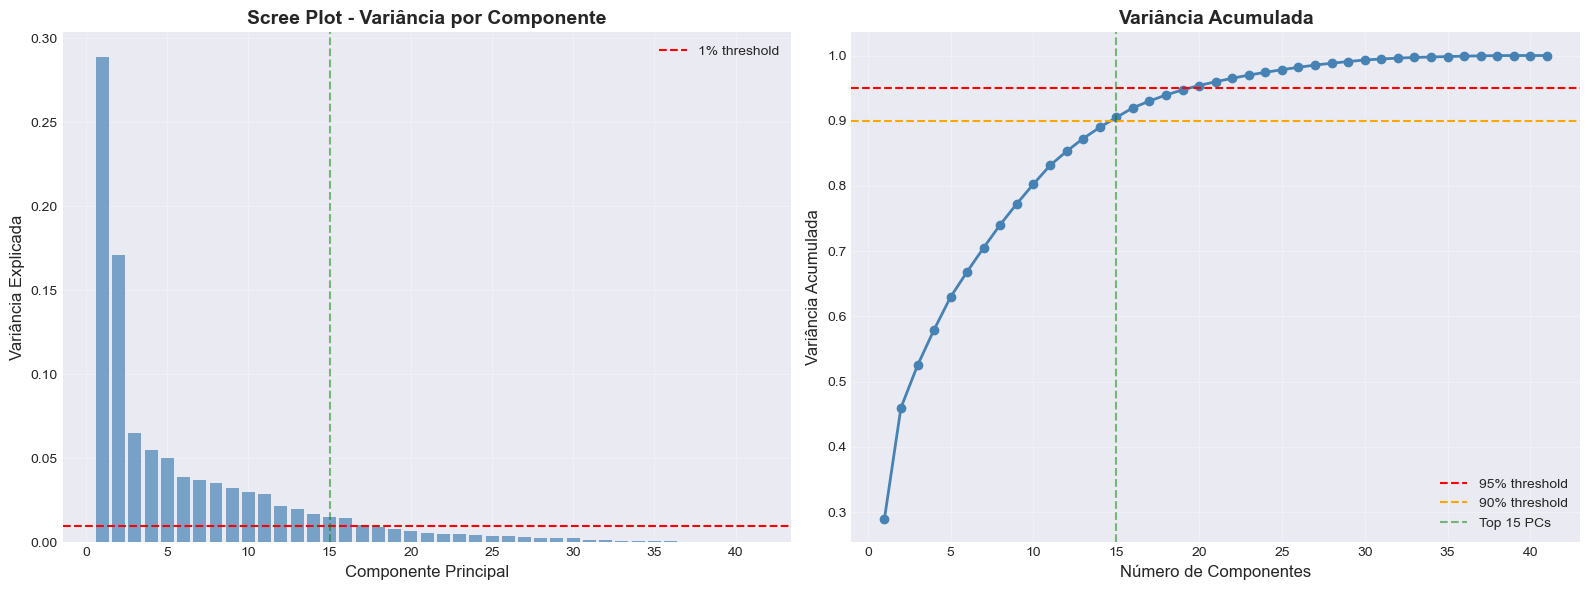


────────────────────────────────────────────────────────────────────────────────
CONTRIBUIÇÃO DAS FEATURES PARA A VARIÂNCIA TOTAL:
────────────────────────────────────────────────────────────────────────────────

📊 TOP 20 FEATURES (maior contribuição):


,feature,contribuicao_variancia,contrib_pct,contrib_acum
11,pct_modalidade_c_scaled,0.0367,3.6748,3.6748
12,pct_modalidade_d_scaled,0.0367,3.6734,7.3482
25,num_obras_ultranicho_scaled,0.0367,3.6726,11.0208
16,pib_per_capita_scaled,0.0365,3.6464,14.6672
13,pct_sessoes_legendadas_scaled,0.0364,3.6384,18.3056
24,pct_obras_exclusivas_scaled,0.0363,3.6283,21.9339
17,ingressos_per_capita_municipio_scaled,0.0360,3.6041,25.5380
0,num_salas_scaled,0.0359,3.5935,29.1315
22,obras_cinema_mundial_scaled,0.0359,3.5865,32.7180
23,pct_obras_cinema_mundial_scaled,0.0352,3.5191,36.2371



📊 BOTTOM 15 FEATURES (menor contribuição):


,feature,contribuicao_variancia,contrib_pct,contrib_acum
3,volume_log_scaled,0.0280,2.8047,91.4581
7,produtora_nivel_medio_complexo_scaled,0.0279,2.7941,94.2522
34,faixa_renda_cat_Media_Baixa,0.0081,0.8078,95.0600
35,e_capital,0.0080,0.7970,95.8571
29,porte_municipio_cat_Metropole,0.0074,0.7376,96.5947
33,faixa_renda_cat_Media_Alta,0.0070,0.6950,97.2897
38,exibidor_independente,0.0057,0.5656,97.8553
32,faixa_renda_cat_Baixa,0.0055,0.5478,98.4031
28,porte_municipio_cat_Medio,0.0043,0.4316,98.8347
37,natureza_nao_informada,0.0034,0.3384,99.1731



────────────────────────────────────────────────────────────────────────────────
FEATURES QUE EXPLICAM OS ÚLTIMOS 5% DE VARIÂNCIA:
────────────────────────────────────────────────────────────────────────────────

✅ Features que explicam 95% da variância: 28
⚠️  Features nos últimos 5%: 13

📋 Lista das 13 features candidatas à remoção:
   • faixa_renda_cat_Media_Baixa                        (contrib: 0.808%)
   • e_capital                                          (contrib: 0.797%)
   • porte_municipio_cat_Metropole                      (contrib: 0.738%)
   • faixa_renda_cat_Media_Alta                         (contrib: 0.695%)
   • exibidor_independente                              (contrib: 0.566%)
   • faixa_renda_cat_Baixa                              (contrib: 0.548%)
   • porte_municipio_cat_Medio                          (contrib: 0.432%)
   • natureza_nao_informada                             (contrib: 0.338%)
   • porte_municipio_cat_Muito_Grande                   (contrib: 0.32

In [98]:
# ════════════════════════════════════════════════════════════════════════════
# ANÁLISE DE VARIÂNCIA: Quais features contribuem menos?
# ════════════════════════════════════════════════════════════════════════════

print("=" * 80)
print("ANÁLISE DE VARIÂNCIA - PCA")
print("=" * 80)

print("\n💡 OBJETIVO:")
print("   Identificar features que contribuem pouco para a variância total")
print("   → Candidatas à remoção se explicam apenas os últimos 5% de variância\n")

# Aplicar PCA com TODOS os componentes
n_features_fase2 = X_fase2.shape[1]
pca_full = PCA(n_components=n_features_fase2, random_state=42)
pca_full.fit(X_fase2)

# Variância explicada
var_explicada = pca_full.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

print(f"📊 RESUMO:")
print(f"   Total de features: {n_features_fase2}")
print(f"   Variância explicada pelo PC1: {var_explicada[0]:.4f} ({var_explicada[0]*100:.2f}%)")
print(f"   Variância acumulada em 15 PCs: {var_acumulada[14]:.4f} ({var_acumulada[14]*100:.2f}%)")
print(f"   Variância acumulada em 20 PCs: {var_acumulada[19]:.4f} ({var_acumulada[19]*100:.2f}%)")

# ════════════════════════════════════════════════════════════════════════════
# SCREE PLOT
# ════════════════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Variância por componente
ax1.bar(range(1, len(var_explicada)+1), var_explicada, alpha=0.7, color='steelblue')
ax1.axhline(y=0.01, color='red', linestyle='--', label='1% threshold')
ax1.set_xlabel('Componente Principal', fontsize=12)
ax1.set_ylabel('Variância Explicada', fontsize=12)
ax1.set_title('Scree Plot - Variância por Componente', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Destacar top 15
ax1.axvline(x=15, color='green', linestyle='--', alpha=0.5, label='Top 15')

# Plot 2: Variância acumulada
ax2.plot(range(1, len(var_acumulada)+1), var_acumulada, 'o-', color='steelblue', linewidth=2)
ax2.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
ax2.axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
ax2.axvline(x=15, color='green', linestyle='--', alpha=0.5, label='Top 15 PCs')
ax2.set_xlabel('Número de Componentes', fontsize=12)
ax2.set_ylabel('Variância Acumulada', fontsize=12)
ax2.set_title('Variância Acumulada', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# CONTRIBUIÇÃO DAS FEATURES PARA VARIÂNCIA
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "─" * 80)
print("CONTRIBUIÇÃO DAS FEATURES PARA A VARIÂNCIA TOTAL:")
print("─" * 80)

# Calcular contribuição de cada feature (loadings quadrados ponderados)
loadings = pca_full.components_  # (n_components, n_features)
contribuicoes = []

for i, feat in enumerate(features_fase2):
    # Contribuição = soma ponderada dos loadings quadrados pela var explicada
    contrib = sum(loadings[j, i]**2 * var_explicada[j] for j in range(n_features_fase2))
    contribuicoes.append({
        'feature': feat,
        'contribuicao_variancia': contrib
    })

df_contrib = pd.DataFrame(contribuicoes).sort_values('contribuicao_variancia', ascending=False)
df_contrib['contrib_pct'] = df_contrib['contribuicao_variancia'] * 100
df_contrib['contrib_acum'] = df_contrib['contrib_pct'].cumsum()

print(f"\n📊 TOP 20 FEATURES (maior contribuição):")
display(df_contrib.head(20))

print(f"\n📊 BOTTOM 15 FEATURES (menor contribuição):")
display(df_contrib.tail(15))

# ════════════════════════════════════════════════════════════════════════════
# IDENTIFICAR FEATURES QUE EXPLICAM ÚLTIMOS 5%
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "─" * 80)
print("FEATURES QUE EXPLICAM OS ÚLTIMOS 5% DE VARIÂNCIA:")
print("─" * 80)

# Features que juntas explicam de 95% a 100%
threshold_95 = df_contrib[df_contrib['contrib_acum'] <= 95.0]
n_top_95 = len(threshold_95)

features_bottom_5pct = df_contrib.tail(n_features_fase2 - n_top_95)

print(f"\n✅ Features que explicam 95% da variância: {n_top_95}")
print(f"⚠️  Features nos últimos 5%: {len(features_bottom_5pct)}")

if len(features_bottom_5pct) > 0:
    print(f"\n📋 Lista das {len(features_bottom_5pct)} features candidatas à remoção:")
    for idx, row in features_bottom_5pct.iterrows():
        print(f"   • {row['feature']:50s} (contrib: {row['contrib_pct']:.3f}%)")
    
    print(f"\n💡 RECOMENDAÇÃO:")
    print(f"   Considerar remover as {len(features_bottom_5pct)} features acima na Fase 3")
    print(f"   → Simplifica modelo sem perda significativa de informação")
else:
    print(f"\n✅ Todas as features contribuem significativamente (>5%)")



## 4.2.3 Rodada 3

In [99]:
print("=" * 80)
print("FASE 3: REMOÇÃO DE FEATURES DERIVADAS")
print("=" * 80)

features_remover_fase3 = [
    'pct_obras_nao_anglo_scaled',          # Derivada: soma de outras 2
    'pct_obras_cinema_mundial_scaled',     # Redundante com obras_num
    'porte_municipio_cat_Metropole',       # Porte do município one-hot econding não ajudou
    'porte_municipio_cat_Muito_Grande',    # Porte do município one-hot econding não ajudou                    
    'porte_municipio_cat_Medio',           # Porte do município one-hot econding não ajudou                          
    'porte_municipio_cat_Pequeno',         # Porte do município one-hot econding não ajudou  
    'operacao_nao_comercial'               # Não há muitos complexos com operação não comercial              
]

print(f"\n📋 Features a remover (Fase 3):")
for feat in features_remover_fase3:
    existe = feat in features_fase2
    print(f"  {'✓' if existe else '✗'} {feat}")

indices_remover_fase3 = [i for i, f in enumerate(features_fase2) if f in features_remover_fase3]

X_fase3 = np.delete(X_fase2, indices_remover_fase3, axis=1)
features_fase3 = [f for f in features_fase2 if f not in features_remover_fase3]

print(f"\n✅ Fase 3 concluída:")
print(f"  Complexos: {X_fase3.shape[0]} (mantidos)")
print(f"  Features: {X_fase3.shape[1]} (removidas 7)")

print("\n" + "=" * 80)

FASE 3: REMOÇÃO DE FEATURES DERIVADAS

📋 Features a remover (Fase 3):
  ✓ pct_obras_nao_anglo_scaled
  ✓ pct_obras_cinema_mundial_scaled
  ✓ porte_municipio_cat_Metropole
  ✓ porte_municipio_cat_Muito_Grande
  ✓ porte_municipio_cat_Medio
  ✓ porte_municipio_cat_Pequeno
  ✓ operacao_nao_comercial

✅ Fase 3 concluída:
  Complexos: 875 (mantidos)
  Features: 34 (removidas 7)



In [100]:
print("=" * 80)
print("CLUSTERIZAÇÃO FASE 3")
print("=" * 80)

resultados_fase3 = []

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_fase3)
    
    sil = silhouette_score(X_fase3, labels)
    db = davies_bouldin_score(X_fase3, labels)
    ch = calinski_harabasz_score(X_fase3, labels)
    
    resultados_fase3.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'inertia': kmeans.inertia_
    })
    
    print(f"k={k}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.1f}")

df_resultados_fase3 = pd.DataFrame(resultados_fase3)

# Comparação
print("\n" + "=" * 80)
print("COMPARAÇÃO FASE 2 vs FASE 3:")
print("=" * 80)

print(f"\n{'k':>3} | {'Sil_Fase2':>10} | {'Sil_Fase3':>10} | {'Delta':>8}")
print("-" * 40)

for i in range(len(df_resultados_fase2)):
    k = int(df_resultados_fase2.iloc[i]['k'])
    sil2 = df_resultados_fase2.iloc[i]['silhouette']
    sil3 = df_resultados_fase3.iloc[i]['silhouette']
    delta = sil3 - sil2
    simbolo = "↑" if delta > 0 else "↓"
    print(f"{k:3d} | {sil2:10.4f} | {sil3:10.4f} | {delta:+7.4f} {simbolo}")

print("\n" + "=" * 80)

CLUSTERIZAÇÃO FASE 3
k=4: Silhouette=0.1847, DB=1.7511, CH=170.9
k=5: Silhouette=0.1874, DB=1.4947, CH=149.2
k=6: Silhouette=0.1406, DB=1.7311, CH=138.5
k=7: Silhouette=0.1439, DB=1.5209, CH=133.7
k=8: Silhouette=0.1366, DB=1.5154, CH=123.6

COMPARAÇÃO FASE 2 vs FASE 3:

  k |  Sil_Fase2 |  Sil_Fase3 |    Delta
----------------------------------------
  4 |     0.1984 |     0.1847 | -0.0137 ↓
  5 |     0.2003 |     0.1874 | -0.0128 ↓
  6 |     0.1328 |     0.1406 | +0.0078 ↑
  7 |     0.1535 |     0.1439 | -0.0096 ↓
  8 |     0.1387 |     0.1366 | -0.0021 ↓



In [101]:
print("=" * 80)
print("DIAGNÓSTICO FASE 3")
print("=" * 80)

# VIF
features_cont_fase3 = [f for f in features_fase3 if f.endswith('_scaled')]
idx_cont = [i for i, f in enumerate(features_fase3) if f.endswith('_scaled')]
X_cont_fase3 = X_fase3[:, idx_cont]

vif_fase3 = []
for i in range(len(features_cont_fase3)):
    vif = variance_inflation_factor(X_cont_fase3, i)
    vif_fase3.append({'feature': features_cont_fase3[i], 'VIF': vif})

df_vif_fase3 = pd.DataFrame(vif_fase3).sort_values('VIF', ascending=False)

print(f"\nVIF APÓS FASE 3:")
print(f"Features com VIF > 30: {len(df_vif_fase3[df_vif_fase3['VIF'] > 30])}")
print(f"Features com VIF = inf: {len(df_vif_fase3[df_vif_fase3['VIF'] == np.inf])}")
display(df_vif_fase3.head(15))

# Correlação
corr_matrix_fase3 = np.corrcoef(X_fase3.T)

pares_fase3 = []
for i in range(len(features_fase3)):
    for j in range(i+1, len(features_fase3)):
        corr_val = abs(corr_matrix_fase3[i, j])
        if corr_val > 0.85:
            pares_fase3.append({
                'feat1': features_fase3[i],
                'feat2': features_fase3[j],
                'corr_abs': corr_val
            })

df_corr_fase3 = pd.DataFrame(pares_fase3).sort_values('corr_abs', ascending=False)

print(f"\nPARES COM |CORRELAÇÃO| > 0.85:")
print(f"Total: {len(df_corr_fase3)}")
display(df_corr_fase3)

print("\n" + "=" * 80)

DIAGNÓSTICO FASE 3

VIF APÓS FASE 3:
Features com VIF > 30: 0
Features com VIF = inf: 0


,feature,VIF
3,volume_log_scaled,26.0581
8,pct_sessoes_brasileiras_scaled,23.9338
4,pct_sessoes_major_scaled,15.2722
6,pct_sessoes_produtora_independente_scaled,13.5631
0,num_salas_scaled,10.4706
1,pct_dias_operando_scaled,8.9777
18,entropia_nacionalidade_scaled,7.9747
21,entropia_distribuidora_scaled,6.6290
22,obras_cinema_mundial_scaled,6.5256
14,pct_publico_obras_top5_scaled,5.5155



PARES COM |CORRELAÇÃO| > 0.85:
Total: 3


,feat1,feat2,corr_abs
2,perfil_independente_scaled,exibidor_independente,0.9590
1,pct_sessoes_produtora_independente_scaled,pct_sessoes_brasileiras_scaled,0.9349
0,pct_sessoes_major_scaled,pct_publico_obras_top5_scaled,0.8507


## 4.3 Resultados da seleção de features

In [102]:
# Calcular Silhouette por complexo (k=5, Fase 3)
kmeans_k5 = KMeans(n_clusters=5, random_state=42, n_init=20)
labels_k5 = kmeans_k5.fit_predict(X_fase3)
sil_samples = silhouette_samples(X_fase3, labels_k5)

# Adicionar ao DataFrame
df_features_fase3['silhouette_score'] = sil_samples
df_features_fase3['cluster_k5'] = labels_k5

# Identificar problemáticos
print("=" * 80)
print("ANÁLISE DE SILHOUETTE POR COMPLEXO")
print("=" * 80)

# Estatísticas por cluster
for cluster_id in range(5):
    mask = labels_k5 == cluster_id
    sil_cluster = sil_samples[mask]
    
    negativos = (sil_cluster < 0).sum()
    baixos = ((sil_cluster >= 0) & (sil_cluster < 0.1)).sum()
    
    print(f"\nCluster {cluster_id} ({mask.sum()} complexos):")
    print(f"  Silhouette médio: {sil_cluster.mean():.4f}")
    print(f"  Negativos: {negativos} ({negativos/len(sil_cluster)*100:.1f}%)")
    print(f"  Baixos (0-0.1): {baixos} ({baixos/len(sil_cluster)*100:.1f}%)")

# Top 20 piores
print("\n" + "=" * 80)
print("TOP 20 COMPLEXOS COM PIOR SILHOUETTE:")
print("=" * 80)

piores = df_features_fase3.nsmallest(20, 'silhouette_score')[
    ['REGISTRO_COMPLEXO', 'municipio', 'UF', 'cluster_k5', 'silhouette_score', 
     'num_salas_scaled', 'volume_log_scaled', 'pct_sessoes_brasileiras_scaled']
]
display(piores)

# Gráfico de distribuição
fig, ax = plt.subplots(figsize=(12, 6))
for cluster_id in range(5):
    mask = labels_k5 == cluster_id
    sil_cluster = sil_samples[mask]
    ax.hist(sil_cluster, bins=30, alpha=0.5, label=f'Cluster {cluster_id}')

ax.axvline(0, color='red', linestyle='--', label='Silhouette = 0')
ax.set_xlabel('Silhouette Score')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Silhouette por Cluster')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n📊 Total de complexos com Silhouette negativo: {(sil_samples < 0).sum()}")

NameError: name 'df_features_fase3' is not defined

In [78]:
# Testar várias dimensões
for n_comp in [25, 30, 34]:  # 34 = todas
    if n_comp >= X_fase3.shape[1]:
        X_pca = X_fase3
        var_exp = 1.0
    else:
        pca = PCA(n_components=n_comp, random_state=42)
        X_pca = pca.fit_transform(X_fase3)
        var_exp = pca.explained_variance_ratio_.sum()
    
    # Clusterizar
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    
    print(f"PCA {n_comp:2d} componentes (var={var_exp:.3f}): Silhouette = {sil:.4f}")

PCA 25 componentes (var=0.989): Silhouette = 0.1958
PCA 30 componentes (var=0.998): Silhouette = 0.1879
PCA 34 componentes (var=1.000): Silhouette = 0.1874


In [80]:
# Treinar RF para "prever" clusters (como se fossem classes)
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_fase3, labels_k5)

# Importância
importancias = pd.DataFrame({
    'feature': features_fase3,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

print("TOP 25 FEATURES MAIS IMPORTANTES PARA SEPARAÇÃO:")
display(importancias.head(25))

print("\nBOTTOM 10 (menos importantes):")
display(importancias.tail(10))

# Testar removendo as 5 menos importantes
features_remover_rf = importancias.tail(5)['feature'].tolist()
print(f"\nTestar remover: {features_remover_rf}")

TOP 25 FEATURES MAIS IMPORTANTES PARA SEPARAÇÃO:


,feature,importancia
3,volume_log_scaled,0.1325
22,obras_cinema_mundial_scaled,0.1278
0,num_salas_scaled,0.1182
4,pct_sessoes_major_scaled,0.0879
9,pct_sessoes_especiais_scaled,0.0607
15,populacao_scaled,0.0601
20,entropia_faixa_horaria_scaled,0.0550
18,entropia_nacionalidade_scaled,0.0490
14,pct_publico_obras_top5_scaled,0.0368
21,entropia_distribuidora_scaled,0.0357



BOTTOM 10 (menos importantes):


,feature,importancia
12,pct_modalidade_d_scaled,0.0043
24,num_obras_ultranicho_scaled,0.0041
32,natureza_nao_privada,0.0030
31,exibidor_independente,0.0029
11,pct_modalidade_c_scaled,0.0016
28,faixa_renda_cat_Media_Baixa,0.0015
27,faixa_renda_cat_Media_Alta,0.0014
30,natureza_nao_informada,0.0008
26,faixa_renda_cat_Baixa,0.0002
33,caso_extremo_atividade,0.0001



Testar remover: ['faixa_renda_cat_Media_Baixa', 'faixa_renda_cat_Media_Alta', 'natureza_nao_informada', 'faixa_renda_cat_Baixa', 'caso_extremo_atividade']


In [81]:
def gap_statistic(X, k_max=10, n_refs=10):
    gaps = []
    for k in range(2, k_max+1):
        # Clustering real
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X)
        inertia_real = kmeans.inertia_
        
        # Clustering em dados aleatórios (referência)
        inertias_ref = []
        for _ in range(n_refs):
            X_rand = np.random.uniform(X.min(axis=0), X.max(axis=0), size=X.shape)
            kmeans_rand = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans_rand.fit(X_rand)
            inertias_ref.append(kmeans_rand.inertia_)
        
        gap = np.log(np.mean(inertias_ref)) - np.log(inertia_real)
        gaps.append(gap)
    
    return gaps

gaps = gap_statistic(X_fase3, k_max=8)

for i, gap in enumerate(gaps, start=2):
    print(f"k={i}: Gap = {gap:.4f}")

print(f"\nMelhor k: {np.argmax(gaps) + 2}")

k=2: Gap = 2.3983
k=3: Gap = 2.4545
k=4: Gap = 2.4618
k=5: Gap = 2.4911
k=6: Gap = 2.5262
k=7: Gap = 2.5691
k=8: Gap = 2.5850

Melhor k: 8


In [82]:
# MinMaxScaler (0-1)
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_fase3)

kmeans_mm = KMeans(n_clusters=5, random_state=42, n_init=20)
labels_mm = kmeans_mm.fit_predict(X_mm)
sil_mm = silhouette_score(X_mm, labels_mm)

print(f"MinMaxScaler:   Silhouette = {sil_mm:.4f}")

# RobustScaler (resistente a outliers)
scaler_rb = RobustScaler()
X_rb = scaler_rb.fit_transform(X_fase3)

kmeans_rb = KMeans(n_clusters=5, random_state=42, n_init=20)
labels_rb = kmeans_rb.fit_predict(X_rb)
sil_rb = silhouette_score(X_rb, labels_rb)

print(f"RobustScaler:   Silhouette = {sil_rb:.4f}")
print(f"StandardScaler: Silhouette = 0.2003 (atual)")

MinMaxScaler:   Silhouette = 0.2888
RobustScaler:   Silhouette = 0.7460
StandardScaler: Silhouette = 0.2003 (atual)


# 5 Otimização do Modelo

## 5.1 Identificação de features para robustscaler

In [85]:
# =============================================================================
# 5. OTIMIZAÇÃO DO MODELO
# =============================================================================

print("=" * 80)
print("5.1 - IDENTIFICAÇÃO DE FEATURES PARA ROBUSTSCALER")
print("=" * 80)

# Partir dos dados da Seção 4.2
print(f"\n📊 Dados de entrada (Seção 4.2):")
print(f"  Complexos: {X_fase3.shape[0]}")
print(f"  Features: {X_fase3.shape[1]}")
print(f"  Lista: features_fase3 ({len(features_fase3)} elementos)")

# Categorizar features por tipo
features_continuas = [f for f in features_fase3 if f.endswith('_scaled')]
features_binarias = [f for f in features_fase3 if not f.endswith('_scaled') and 'cat' not in f.lower()]
features_categoricas = [f for f in features_fase3 if 'cat' in f.lower()]

print(f"\n" + "─" * 80)
print("CATEGORIZAÇÃO DAS FEATURES:")
print("─" * 80)

print(f"\n📈 FEATURES CONTÍNUAS (_scaled): {len(features_continuas)}")
print(f"   → Receberão RobustScaler (resistente a outliers)")
for i, feat in enumerate(features_continuas, 1):
    print(f"   {i:2d}. {feat}")

print(f"\n🔘 FEATURES BINÁRIAS (0/1): {len(features_binarias)}")
print(f"   → Mantidas intactas (não normalizar)")
for i, feat in enumerate(features_binarias, 1):
    print(f"   {i:2d}. {feat}")

print(f"\n🏷️  FEATURES CATEGÓRICAS (one-hot): {len(features_categoricas)}")
print(f"   → Mantidas intactas (já são 0/1)")
for i, feat in enumerate(features_categoricas, 1):
    print(f"   {i:2d}. {feat}")

# Validação
total_categorizado = len(features_continuas) + len(features_binarias) + len(features_categoricas)
print(f"\n" + "─" * 80)
print(f"✅ Validação: {total_categorizado} features categorizadas = {len(features_fase3)} total")
assert total_categorizado == len(features_fase3), "❌ ERRO: Categorização incompleta!"

print("\n" + "=" * 80)

5.1 - IDENTIFICAÇÃO DE FEATURES PARA ROBUSTSCALER

📊 Dados de entrada (Seção 4.2):
  Complexos: 875
  Features: 34
  Lista: features_fase3 (34 elementos)

────────────────────────────────────────────────────────────────────────────────
CATEGORIZAÇÃO DAS FEATURES:
────────────────────────────────────────────────────────────────────────────────

📈 FEATURES CONTÍNUAS (_scaled): 26
   → Receberão RobustScaler (resistente a outliers)
    1. num_salas_scaled
    2. pct_dias_operando_scaled
    3. sessoes_por_dia_sala_scaled
    4. volume_log_scaled
    5. pct_sessoes_major_scaled
    6. pct_sessoes_distrib_independente_scaled
    7. pct_sessoes_produtora_independente_scaled
    8. produtora_nivel_medio_complexo_scaled
    9. pct_sessoes_brasileiras_scaled
   10. pct_sessoes_especiais_scaled
   11. pct_modalidade_b_scaled
   12. pct_modalidade_c_scaled
   13. pct_modalidade_d_scaled
   14. pct_sessoes_legendadas_scaled
   15. pct_publico_obras_top5_scaled
   16. populacao_scaled
   17. pib_pe

## 5.2 Análise de Distribuições das Features Contínuas

In [86]:
print("=" * 80)
print("5.2 - ANÁLISE DE DISTRIBUIÇÕES (Justificativa RobustScaler)")
print("=" * 80)

# Extrair apenas features contínuas do X_fase3
indices_continuas = [i for i, f in enumerate(features_fase3) if f.endswith('_scaled')]
X_continuas = X_fase3[:, indices_continuas]

# Calcular estatísticas (dados já normalizados por StandardScaler)
# Vamos olhar para a presença de outliers (valores > 3 ou < -3 desvios)

print(f"\n📊 Análise de outliers nas {len(features_continuas)} features contínuas:")
print(f"   (Valores considerados outliers: |z| > 3)\n")

outlier_stats = []

for i, feat in enumerate(features_continuas):
    valores = X_continuas[:, i]
    
    # Contar outliers extremos (|z| > 3)
    outliers_positivos = (valores > 3).sum()
    outliers_negativos = (valores < -3).sum()
    total_outliers = outliers_positivos + outliers_negativos
    pct_outliers = (total_outliers / len(valores)) * 100
    
    # Estatísticas básicas
    q25, q50, q75 = np.percentile(valores, [25, 50, 75])
    iqr = q75 - q25
    
    outlier_stats.append({
        'feature': feat,
        'n_outliers': total_outliers,
        'pct_outliers': pct_outliers,
        'min': valores.min(),
        'max': valores.max(),
        'q25': q25,
        'mediana': q50,
        'q75': q75,
        'IQR': iqr
    })

df_outliers = pd.DataFrame(outlier_stats).sort_values('n_outliers', ascending=False)

print("─" * 80)
print("TOP 15 FEATURES COM MAIS OUTLIERS:")
print("─" * 80)
display(df_outliers.head(15)[['feature', 'n_outliers', 'pct_outliers', 'min', 'max']])

print("─" * 80)
print("RESUMO:")
print("─" * 80)

features_com_outliers = (df_outliers['n_outliers'] > 0).sum()
total_outliers_dataset = df_outliers['n_outliers'].sum()

print(f"  Features com outliers (|z|>3): {features_com_outliers}/{len(features_continuas)} ({features_com_outliers/len(features_continuas)*100:.1f}%)")
print(f"  Total de valores outliers: {total_outliers_dataset}")
print(f"  Média de outliers por feature: {total_outliers_dataset/len(features_continuas):.1f}")

print(f"\n💡 INTERPRETAÇÃO:")
print(f"   StandardScaler (atual) usa média/desvio → SENSÍVEL a esses outliers")
print(f"   RobustScaler usa mediana/IQR → RESISTENTE a esses outliers")
print(f"   → Esperado: RobustScaler melhore separação dos clusters")

print("\n" + "=" * 80)

5.2 - ANÁLISE DE DISTRIBUIÇÕES (Justificativa RobustScaler)

📊 Análise de outliers nas 26 features contínuas:
   (Valores considerados outliers: |z| > 3)

────────────────────────────────────────────────────────────────────────────────
TOP 15 FEATURES COM MAIS OUTLIERS:
────────────────────────────────────────────────────────────────────────────────


,feature,n_outliers,pct_outliers,min,max
14,pct_publico_obras_top5_scaled,31,3.5429,-3.9946,0.8636
4,pct_sessoes_major_scaled,27,3.0857,-4.7015,1.6927
18,entropia_nacionalidade_scaled,23,2.6286,-2.3392,4.3715
21,entropia_distribuidora_scaled,22,2.5143,-5.9792,0.8373
13,pct_sessoes_legendadas_scaled,21,2.4000,-0.6310,4.1658
19,entropia_modalidade_scaled,18,2.0571,-0.5769,6.9227
24,num_obras_ultranicho_scaled,17,1.9429,-0.1862,16.7130
6,pct_sessoes_produtora_independente_scaled,16,1.8286,-1.2542,10.1385
23,pct_obras_exclusivas_scaled,15,1.7143,-1.7487,5.7294
8,pct_sessoes_brasileiras_scaled,14,1.6000,-1.4553,10.1951


────────────────────────────────────────────────────────────────────────────────
RESUMO:
────────────────────────────────────────────────────────────────────────────────
  Features com outliers (|z|>3): 23/26 (88.5%)
  Total de valores outliers: 328
  Média de outliers por feature: 12.6

💡 INTERPRETAÇÃO:
   StandardScaler (atual) usa média/desvio → SENSÍVEL a esses outliers
   RobustScaler usa mediana/IQR → RESISTENTE a esses outliers
   → Esperado: RobustScaler melhore separação dos clusters



## 5.3 Importação da matriz original para robust scaler

In [46]:
# %%
# 5.3.1 - CARREGAMENTO E REMOÇÃO DE COMPLEXOS

print("=" * 80)
print("5.3.1 - CARREGAMENTO E REMOÇÃO DE COMPLEXOS")
print("=" * 80)

# Carregar dados originais (não normalizados)
print("\n🔄 Carregando df_features_final.parquet...")

df_original = pd.read_parquet('../Bases/df_features_final.parquet')
print(f"✅ Carregado: {df_original.shape}")

# Remover sufixo '_scaled' (cosmético)
df_original.columns = [col.replace('_scaled', '') for col in df_original.columns]
print(f"✅ Sufixo '_scaled' removido")

# Remoção de complexos
print("\n" + "─" * 80)
print("🗑️  REMOÇÃO DE COMPLEXOS")
print("─" * 80)

# Outliers extremos
outliers_extremos = [17778, 19846, 28343, 31000, 34842, 6616]

# Complexos com baixa_atividade
complexos_baixa_atividade = df_original[
    df_original['baixa_atividade'] == 1
]['REGISTRO_COMPLEXO'].tolist()

# Consolidar
COMPLEXOS_A_REMOVER = outliers_extremos + complexos_baixa_atividade

print(f"\n📋 Complexos a remover:")
print(f"   Outliers extremos: {len(outliers_extremos)}")
print(f"   Baixa atividade: {len(complexos_baixa_atividade)}")
print(f"   TOTAL: {len(COMPLEXOS_A_REMOVER)}")

# Remover
mask_manter = ~df_original['REGISTRO_COMPLEXO'].isin(COMPLEXOS_A_REMOVER)
df_clean = df_original[mask_manter].copy()

print(f"\n✅ Complexos removidos: {len(COMPLEXOS_A_REMOVER)}")
print(f"✅ Complexos restantes: {len(df_clean)}")

print("\n" + "=" * 80)

5.3.1 - CARREGAMENTO E REMOÇÃO DE COMPLEXOS

🔄 Carregando df_features_final.parquet...
✅ Carregado: (900, 78)
✅ Sufixo '_scaled' removido

────────────────────────────────────────────────────────────────────────────────
🗑️  REMOÇÃO DE COMPLEXOS
────────────────────────────────────────────────────────────────────────────────

📋 Complexos a remover:
   Outliers extremos: 6
   Baixa atividade: 24
   TOTAL: 30

✅ Complexos removidos: 30
✅ Complexos restantes: 876



In [47]:
# %%
# 5.3.2 - IDENTIFICAÇÃO DE TIPOS DE FEATURES

print("=" * 80)
print("5.3.2 - IDENTIFICAÇÃO DE TIPOS DE FEATURES")
print("=" * 80)

# IDs (não são features)
ids = ['REGISTRO_COMPLEXO', 'UF', 'municipio']

# Todas as features
features_all = [col for col in df_clean.columns if col not in ids]

print(f"\n📊 Features totais (com UFs): {len(features_all)}")

# Identificar categóricas encoded PRIMEIRO
categorical_encoded = [col for col in features_all if col.startswith(('UF_', 'porte_', 'faixa_'))]

# Remover UFs (decisão Seção 2)
ufs_to_remove = [col for col in categorical_encoded if col.startswith('UF_')]
categorical_encoded = [col for col in categorical_encoded if not col.startswith('UF_')]

print(f"\n🗑️  Removendo {len(ufs_to_remove)} features de UF")

# Atualizar features_all (sem UFs)
features_all = [col for col in features_all if not col.startswith('UF_')]

# Features numéricas (excluindo categóricas encoded)
continuous_cols = [col for col in df_clean[features_all].select_dtypes(include=['float64', 'int64']).columns.tolist()
                   if col not in categorical_encoded]

# Binárias verdadeiras (0/1, mas não categóricas encoded)
binary_cols = [col for col in continuous_cols 
               if df_clean[col].nunique() == 2 
               and set(df_clean[col].unique()).issubset({0, 1})]

# Contínuas verdadeiras
continuous_to_scale = [col for col in continuous_cols if col not in binary_cols]

print(f"\n📊 Categorização final:")
print(f"   Total features (sem UFs): {len(features_all)}")
print(f"   └─ Contínuas (RobustScaler): {len(continuous_to_scale)}")
print(f"   └─ Binárias (manter 0/1): {len(binary_cols)}")
print(f"   └─ Categóricas encoded (manter 0/1): {len(categorical_encoded)}")

# Validação
total_categorizado = len(continuous_to_scale) + len(binary_cols) + len(categorical_encoded)
print(f"\n✅ Validação: {total_categorizado} = {len(features_all)} ✓")
assert total_categorizado == len(features_all), "❌ ERRO: Categorização incompleta!"

print("\n" + "=" * 80)

5.3.2 - IDENTIFICAÇÃO DE TIPOS DE FEATURES

📊 Features totais (com UFs): 75

🗑️  Removendo 26 features de UF

📊 Categorização final:
   Total features (sem UFs): 49
   └─ Contínuas (RobustScaler): 35
   └─ Binárias (manter 0/1): 6
   └─ Categóricas encoded (manter 0/1): 8

✅ Validação: 49 = 49 ✓



In [48]:
# %%
# 5.3.3 - APLICAÇÃO DE ROBUSTSCALER E MONTAGEM FINAL

print("=" * 80)
print("5.3.3 - ROBUSTSCALER E MONTAGEM DA MATRIZ FINAL")
print("=" * 80)

# Aplicar RobustScaler nas contínuas
print(f"\n🔧 Aplicando RobustScaler em {len(continuous_to_scale)} features...")

X_continuas_orig = df_clean[continuous_to_scale].values

scaler_robust = RobustScaler()
X_continuas_robust = scaler_robust.fit_transform(X_continuas_orig)

df_continuas_robust = pd.DataFrame(
    X_continuas_robust,
    columns=[f"{col}_scaled" for col in continuous_to_scale],
    index=df_clean.index
)

print(f"✅ RobustScaler aplicado!")
print(f"   Range: [{X_continuas_robust.min():.2f}, {X_continuas_robust.max():.2f}]")

# Recombinar DataFrame
print(f"\n🔗 Recombinando DataFrame final...")

df_final = pd.concat([
    df_clean[ids],
    df_continuas_robust,
    df_clean[binary_cols],
    df_clean[categorical_encoded]
], axis=1)

print(f"✅ DataFrame final: {df_final.shape}")

# Extrair X e features
features_fase5 = [col for col in df_final.columns if col not in ids]
X_fase5 = df_final[features_fase5].values
df_features_fase5 = df_final.copy()

print(f"\n📦 Variáveis criadas:")
print(f"   X_fase5: {X_fase5.shape}")
print(f"   features_fase5: {len(features_fase5)} elementos")
print(f"   df_features_fase5: {df_features_fase5.shape}")

# Validação final
print(f"\n🔍 Validação:")
print(f"   NaN: {np.isnan(X_fase5).sum()}")
print(f"   Inf: {np.isinf(X_fase5).sum()}")

assert np.isnan(X_fase5).sum() == 0, "❌ NaNs detectados!"
assert np.isinf(X_fase5).sum() == 0, "❌ Infs detectados!"

print("\n" + "=" * 80)
print("✅ PREPARAÇÃO CONCLUÍDA - PRONTO PARA CLUSTERIZAÇÃO")
print("=" * 80)

5.3.3 - ROBUSTSCALER E MONTAGEM DA MATRIZ FINAL

🔧 Aplicando RobustScaler em 35 features...
✅ RobustScaler aplicado!
   Range: [-79.33, 3464.01]

🔗 Recombinando DataFrame final...
✅ DataFrame final: (876, 52)

📦 Variáveis criadas:
   X_fase5: (876, 49)
   features_fase5: 49 elementos
   df_features_fase5: (876, 52)

🔍 Validação:
   NaN: 0
   Inf: 0

✅ PREPARAÇÃO CONCLUÍDA - PRONTO PARA CLUSTERIZAÇÃO


## 5.4 Re-clusterização com RobustScaler

In [49]:
print("=" * 80)
print("5.4 - RE-CLUSTERIZAÇÃO COM ROBUSTSCALER")
print("=" * 80)

resultados_fase5 = []

print(f"\n🔄 Testando k=4 até k=8 com RobustScaler...\n")

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_fase5)
    
    sil = silhouette_score(X_fase5, labels)
    db = davies_bouldin_score(X_fase5, labels)
    ch = calinski_harabasz_score(X_fase5, labels)
    
    resultados_fase5.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'inertia': kmeans.inertia_
    })
    
    print(f"k={k}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.1f}")

df_resultados_fase5 = pd.DataFrame(resultados_fase5)

print("\n" + "=" * 80)
print("COMPARAÇÃO: StandardScaler (Fase 2) vs RobustScaler (Fase 5)")
print("=" * 80)

print(f"\n{'k':>3} | {'Sil_Std':>10} | {'Sil_Robust':>10} | {'Delta':>10} | {'Melhoria'}")
print("─" * 60)

for i in range(len(df_resultados_fase3)):
    k = int(df_resultados_fase3.iloc[i]['k'])
    sil_std = df_resultados_fase3.iloc[i]['silhouette']
    sil_robust = df_resultados_fase5.iloc[i]['silhouette']
    delta = sil_robust - sil_std
    pct = (delta / sil_std * 100) if sil_std > 0 else 0
    
    if delta > 0.3:
        emoji = "🚀🚀🚀"
    elif delta > 0.1:
        emoji = "🚀🚀"
    elif delta > 0:
        emoji = "↑"
    else:
        emoji = "↓"
    
    print(f"{k:3d} | {sil_std:10.4f} | {sil_robust:10.4f} | {delta:+10.4f} | {pct:+6.1f}% {emoji}")

# Identificar melhor k
melhor_k = df_resultados_fase5.loc[df_resultados_fase5['silhouette'].idxmax(), 'k']
melhor_sil = df_resultados_fase5['silhouette'].max()

print("\n" + "=" * 80)
print(f"🏆 MELHOR RESULTADO: k={int(melhor_k)} com Silhouette={melhor_sil:.4f}")
print("=" * 80)

5.4 - RE-CLUSTERIZAÇÃO COM ROBUSTSCALER

🔄 Testando k=4 até k=8 com RobustScaler...

k=4: Silhouette=0.7904, DB=0.4818, CH=4857.1
k=5: Silhouette=0.7353, DB=0.3822, CH=5057.8
k=6: Silhouette=0.7338, DB=0.2828, CH=6086.1
k=7: Silhouette=0.7562, DB=0.3090, CH=7761.7
k=8: Silhouette=0.7263, DB=0.3640, CH=9323.7

COMPARAÇÃO: StandardScaler (Fase 2) vs RobustScaler (Fase 5)

  k |    Sil_Std | Sil_Robust |      Delta | Melhoria
────────────────────────────────────────────────────────────
  4 |     0.1984 |     0.7904 |    +0.5919 | +298.3% 🚀🚀🚀
  5 |     0.2003 |     0.7353 |    +0.5350 | +267.2% 🚀🚀🚀
  6 |     0.1328 |     0.7338 |    +0.6010 | +452.6% 🚀🚀🚀
  7 |     0.1535 |     0.7562 |    +0.6027 | +392.7% 🚀🚀🚀
  8 |     0.1387 |     0.7263 |    +0.5876 | +423.8% 🚀🚀🚀

🏆 MELHOR RESULTADO: k=4 com Silhouette=0.7904


## 5.5 Análise Deatalhada dos clusters

In [50]:
# %%
# 5.5 - ANÁLISE DETALHADA: k=4 vs k=7

print("=" * 80)
print("5.5 - ANÁLISE DETALHADA: k=4 vs k=7")
print("=" * 80)

# Treinar ambos os modelos
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=20, max_iter=300)
kmeans_k7 = KMeans(n_clusters=7, random_state=42, n_init=20, max_iter=300)

labels_k4 = kmeans_k4.fit_predict(X_fase5)
labels_k7 = kmeans_k7.fit_predict(X_fase5)

# Distribuição de complexos
print("\n" + "─" * 80)
print("DISTRIBUIÇÃO DE COMPLEXOS:")
print("─" * 80)

print("\n📊 k=4:")
for i in range(4):
    n = (labels_k4 == i).sum()
    pct = n / len(labels_k4) * 100
    print(f"   Cluster {i}: {n:3d} ({pct:5.1f}%)")

print("\n📊 k=7:")
for i in range(7):
    n = (labels_k7 == i).sum()
    pct = n / len(labels_k7) * 100
    emoji = "⚠️" if n < 20 else "✓"
    print(f"   Cluster {i}: {n:3d} ({pct:5.1f}%) {emoji}")

# Silhouette por amostra
sil_samples_k4 = silhouette_samples(X_fase5, labels_k4)
sil_samples_k7 = silhouette_samples(X_fase5, labels_k7)

print("\n" + "─" * 80)
print("QUALIDADE INTERNA DOS CLUSTERS:")
print("─" * 80)

print("\n📈 k=4 - Silhouette por cluster:")
for i in range(4):
    mask = labels_k4 == i
    sil_cluster = sil_samples_k4[mask]
    negativos = (sil_cluster < 0).sum()
    
    print(f"   Cluster {i}: média={sil_cluster.mean():.4f}, negativos={negativos} ({negativos/len(sil_cluster)*100:.1f}%)")

print("\n📈 k=7 - Silhouette por cluster:")
for i in range(7):
    mask = labels_k7 == i
    sil_cluster = sil_samples_k7[mask]
    negativos = (sil_cluster < 0).sum()
    
    print(f"   Cluster {i}: média={sil_cluster.mean():.4f}, negativos={negativos} ({negativos/len(sil_cluster)*100:.1f}%)")

# Adicionar labels ao DataFrame
df_features_fase5['cluster_k4'] = labels_k4
df_features_fase5['cluster_k7'] = labels_k7
df_features_fase5['silhouette_k4'] = sil_samples_k4
df_features_fase5['silhouette_k7'] = sil_samples_k7

print("\n" + "=" * 80)
print("💡 PRÓXIMO PASSO: Caracterizar clusters para decidir entre k=4 e k=7")
print("=" * 80)

5.5 - ANÁLISE DETALHADA: k=4 vs k=7

────────────────────────────────────────────────────────────────────────────────
DISTRIBUIÇÃO DE COMPLEXOS:
────────────────────────────────────────────────────────────────────────────────

📊 k=4:
   Cluster 0: 803 ( 91.7%)
   Cluster 1:   2 (  0.2%)
   Cluster 2:   5 (  0.6%)
   Cluster 3:  66 (  7.5%)

📊 k=7:
   Cluster 0:  85 (  9.7%) ✓
   Cluster 1:   1 (  0.1%) ⚠️
   Cluster 2: 753 ( 86.0%) ✓
   Cluster 3:  21 (  2.4%) ✓
   Cluster 4:   1 (  0.1%) ⚠️
   Cluster 5:  14 (  1.6%) ⚠️
   Cluster 6:   1 (  0.1%) ⚠️

────────────────────────────────────────────────────────────────────────────────
QUALIDADE INTERNA DOS CLUSTERS:
────────────────────────────────────────────────────────────────────────────────

📈 k=4 - Silhouette por cluster:
   Cluster 0: média=0.8227, negativos=1 (0.1%)
   Cluster 1: média=0.6950, negativos=0 (0.0%)
   Cluster 2: média=0.3031, negativos=0 (0.0%)
   Cluster 3: média=0.4368, negativos=0 (0.0%)

📈 k=7 - Silhouette por clu

In [51]:
# %%
# 5.6 - INVESTIGAÇÃO DOS MICRO-CLUSTERS

print("=" * 80)
print("5.6 - INVESTIGAÇÃO DOS MICRO-CLUSTERS (k=4)")
print("=" * 80)

# Cluster 1 (2 complexos)
print("\n🔍 Cluster 1 (2 complexos):")
cluster1 = df_features_fase5[df_features_fase5['cluster_k4'] == 1][
    ['REGISTRO_COMPLEXO', 'municipio', 'UF', 'silhouette_k4']
]
display(cluster1)

# Verificar características (primeiras 10 features contínuas)
features_continuas_scaled = [f for f in features_fase5 if f.endswith('_scaled')][:10]
print("\nCaracterísticas (primeiras 10 features):")
display(df_features_fase5[df_features_fase5['cluster_k4'] == 1][features_continuas_scaled].T)

# Cluster 2 (5 complexos)
print("\n" + "─" * 80)
print("\n🔍 Cluster 2 (5 complexos):")
cluster2 = df_features_fase5[df_features_fase5['cluster_k4'] == 2][
    ['REGISTRO_COMPLEXO', 'municipio', 'UF', 'silhouette_k4']
]
display(cluster2)

print("\nCaracterísticas (primeiras 10 features):")
display(df_features_fase5[df_features_fase5['cluster_k4'] == 2][features_continuas_scaled].T)

# Estatísticas do Cluster 0 (gigante)
print("\n" + "─" * 80)
print("\n📊 Cluster 0 (803 complexos - 92%):")
print("\nEstatísticas básicas (5 features principais):")

principais = ['num_salas_scaled', 'volume_log_scaled', 'pct_sessoes_brasileiras_scaled', 
              'pct_sessoes_major_scaled', 'pct_obras_nao_anglo_scaled']

stats_cluster0 = df_features_fase5[df_features_fase5['cluster_k4'] == 0][principais].describe()
display(stats_cluster0)

print("\n" + "=" * 80)

5.6 - INVESTIGAÇÃO DOS MICRO-CLUSTERS (k=4)

🔍 Cluster 1 (2 complexos):


,REGISTRO_COMPLEXO,municipio,UF,silhouette_k4
501,37229,IRATI,PR,0.6496
665,47598,SÃO BENTO,PB,0.7405



Características (primeiras 10 features):


,501,665
num_salas_scaled,-0.5000,-0.7500
pct_dias_operando_scaled,-0.6435,-0.7652
sessoes_por_dia_sala_scaled,-0.3337,-0.1449
volume_log_scaled,-0.4473,-0.8911
pct_sessoes_major_scaled,0.5232,0.7774
pct_sessoes_distrib_independente_scaled,8.6842,-0.0635
pct_sessoes_com_distribuidor_scaled,-2.3434,0.3964
pct_sessoes_produtora_independente_scaled,1.5096,-0.4794
produtora_nivel_medio_complexo_scaled,-2.7459,-0.3140
pct_sessoes_brasileiras_scaled,0.2431,-0.8457



────────────────────────────────────────────────────────────────────────────────

🔍 Cluster 2 (5 complexos):


,REGISTRO_COMPLEXO,municipio,UF,silhouette_k4
454,32860,JOÃO PESSOA,PB,0.2625
559,41661,PARAUAPEBAS,PA,0.4304
610,44017,ALFENAS,MG,0.2964
800,57952,ITAITUBA,PA,0.3317
874,6684,GUARUJÁ,SP,0.1946



Características (primeiras 10 features):


,454,559,610,800,874
num_salas_scaled,-0.7500,-0.2500,-0.2500,-0.7500,-0.2500
pct_dias_operando_scaled,-2.8435,-0.2609,0.0348,-4.2957,-0.0348
sessoes_por_dia_sala_scaled,-1.9013,-1.1745,0.2488,0.4404,-0.2595
volume_log_scaled,-1.5550,-0.2874,-0.0149,-1.4854,-0.0986
pct_sessoes_major_scaled,-8.8201,0.7670,0.5553,1.2912,0.1661
pct_sessoes_distrib_independente_scaled,22.0892,-0.5321,-0.3002,3.7378,-0.2082
pct_sessoes_com_distribuidor_scaled,-23.5342,0.4487,0.1119,-0.1554,0.4616
pct_sessoes_produtora_independente_scaled,16.1636,-1.7696,-0.2906,-1.7319,-0.1275
produtora_nivel_medio_complexo_scaled,-5.4102,1.3088,-0.1270,-3.8841,-0.0548
pct_sessoes_brasileiras_scaled,10.7472,-1.2609,-0.6318,-1.9227,-0.1276



────────────────────────────────────────────────────────────────────────────────

📊 Cluster 0 (803 complexos - 92%):

Estatísticas básicas (5 features principais):


,num_salas_scaled,volume_log_scaled,pct_sessoes_brasileiras_scaled,pct_sessoes_major_scaled,pct_obras_nao_anglo_scaled
count,803.0000,803.0000,803.0000,803.0000,803.0000
mean,0.0766,-0.1865,0.2104,-0.2691,0.1152
std,0.6825,0.7935,1.6412,1.7177,1.0100
min,-0.7500,-2.6331,-2.2600,-8.8201,-1.9405
25%,-0.5000,-0.6130,-0.5888,-0.4288,-0.5314
50%,0.0000,0.0393,0.0093,-0.0298,0.0669
75%,0.5000,0.4350,0.4140,0.5665,0.4909
max,3.5000,1.1108,17.8909,2.7745,6.1491


In [52]:
# %%
# 5.7 - ANÁLISE E DECISÃO: RobustScaler vs StandardScaler

print("=" * 80)
print("5.7 - ANÁLISE CRÍTICA: RobustScaler")
print("=" * 80)

print("\n⚠️  PROBLEMA IDENTIFICADO:")
print("   RobustScaler gerou Silhouette alto (0.79) MAS:")
print("   • Cluster 0: 803 complexos (92%) ← Não há separação útil")
print("   • Clusters 1-2: 7 complexos (0.8%) ← Outliers extremos isolados")
print("")
print("   Silhouette alto = clusters coesos, mas NÃO ÚTEIS para análise de mercado")

print("\n💡 DECISÕES:")
print("   A) Remover 7 complexos extremos e usar StandardScaler")
print("   B) Usar Winsorization (limitar extremos a ±3σ) + StandardScaler")
print("   C) Aceitar RobustScaler e tratar Cluster 0 como segmentável manualmente")

print("\n📊 Complexos extremos identificados:")

extremos_k4 = df_features_fase5[
    df_features_fase5['cluster_k4'].isin([1, 2])
]['REGISTRO_COMPLEXO'].tolist()

print(f"   {extremos_k4}")

print("\n" + "=" * 80)
print("❓ QUAL OPÇÃO VOCÊ PREFERE?")
print("=" * 80)

5.7 - ANÁLISE CRÍTICA: RobustScaler

⚠️  PROBLEMA IDENTIFICADO:
   RobustScaler gerou Silhouette alto (0.79) MAS:
   • Cluster 0: 803 complexos (92%) ← Não há separação útil
   • Clusters 1-2: 7 complexos (0.8%) ← Outliers extremos isolados

   Silhouette alto = clusters coesos, mas NÃO ÚTEIS para análise de mercado

💡 DECISÕES:
   A) Remover 7 complexos extremos e usar StandardScaler
   B) Usar Winsorization (limitar extremos a ±3σ) + StandardScaler
   C) Aceitar RobustScaler e tratar Cluster 0 como segmentável manualmente

📊 Complexos extremos identificados:
   ['32860', '37229', '41661', '44017', '47598', '57952', '6684']

❓ QUAL OPÇÃO VOCÊ PREFERE?


In [53]:
# %%
# 5.8 - ESTRATÉGIA DE NORMALIZAÇÃO HÍBRIDA

print("=" * 80)
print("5.8 - NORMALIZAÇÃO HÍBRIDA: RobustScaler + StandardScaler")
print("=" * 80)

print("\n💡 ESTRATÉGIA:")
print("   RobustScaler: Features onde EXTREMOS = perfis legítimos")
print("   StandardScaler: Features onde extremos = anomalias operacionais")

# Definir quais features usam qual scaler
features_robust = [
    'pct_sessoes_brasileiras',
    'pct_sessoes_major',
    'pct_sessoes_distrib_independente',
    'pct_sessoes_produtora_independente',
    'pct_sessoes_especiais',
    'pct_obras_nao_anglo',
    'pct_obras_cinema_mundial',
    'pct_obras_exclusivas',
    'pct_publico_obras_top5',
    'perfil_independente',
    'pct_sessoes_legendadas'
]

# Todas as outras contínuas usam StandardScaler
features_standard = [f for f in continuous_to_scale if f not in features_robust]

print(f"\n📊 Categorização:")
print(f"   RobustScaler: {len(features_robust)} features (perfis de programação)")
print(f"   StandardScaler: {len(features_standard)} features (operacionais/estruturais)")
print(f"   Binárias/Categóricas: {len(binary_cols) + len(categorical_encoded)} features (manter 0/1)")

# Mostrar quais
print(f"\n🔧 RobustScaler será aplicado em:")
for feat in features_robust:
    print(f"   • {feat}")

print(f"\n🔧 StandardScaler será aplicado em:")
for feat in features_standard[:10]:  # Mostrar só 10 primeiras
    print(f"   • {feat}")
if len(features_standard) > 10:
    print(f"   ... e mais {len(features_standard)-10}")

# Aplicar normalizações
print(f"\n{'─'*80}")
print("APLICANDO NORMALIZAÇÕES...")
print("─"*80)

# Extrair dados originais
X_robust_orig = df_clean[features_robust].values
X_standard_orig = df_clean[features_standard].values

# Aplicar scalers
scaler_robust = RobustScaler()
scaler_standard = StandardScaler()

X_robust_scaled = scaler_robust.fit_transform(X_robust_orig)
X_standard_scaled = scaler_standard.fit_transform(X_standard_orig)

print(f"✅ RobustScaler: range [{X_robust_scaled.min():.2f}, {X_robust_scaled.max():.2f}]")
print(f"✅ StandardScaler: range [{X_standard_scaled.min():.2f}, {X_standard_scaled.max():.2f}]")

# Criar DataFrames
df_robust = pd.DataFrame(
    X_robust_scaled,
    columns=[f"{f}_scaled" for f in features_robust],
    index=df_clean.index
)

df_standard = pd.DataFrame(
    X_standard_scaled,
    columns=[f"{f}_scaled" for f in features_standard],
    index=df_clean.index
)

# Recombinar
df_final_hibrido = pd.concat([
    df_clean[ids],
    df_robust,
    df_standard,
    df_clean[binary_cols],
    df_clean[categorical_encoded]
], axis=1)

# Extrair X
features_fase5_hibrido = [col for col in df_final_hibrido.columns if col not in ids]
X_fase5_hibrido = df_final_hibrido[features_fase5_hibrido].values
df_features_fase5_hibrido = df_final_hibrido.copy()

print(f"\n✅ Matriz híbrida criada:")
print(f"   Shape: {X_fase5_hibrido.shape}")
print(f"   NaN: {np.isnan(X_fase5_hibrido).sum()}")
print(f"   Inf: {np.isinf(X_fase5_hibrido).sum()}")

print("\n" + "=" * 80)

5.8 - NORMALIZAÇÃO HÍBRIDA: RobustScaler + StandardScaler

💡 ESTRATÉGIA:
   RobustScaler: Features onde EXTREMOS = perfis legítimos
   StandardScaler: Features onde extremos = anomalias operacionais

📊 Categorização:
   RobustScaler: 11 features (perfis de programação)
   StandardScaler: 24 features (operacionais/estruturais)
   Binárias/Categóricas: 14 features (manter 0/1)

🔧 RobustScaler será aplicado em:
   • pct_sessoes_brasileiras
   • pct_sessoes_major
   • pct_sessoes_distrib_independente
   • pct_sessoes_produtora_independente
   • pct_sessoes_especiais
   • pct_obras_nao_anglo
   • pct_obras_cinema_mundial
   • pct_obras_exclusivas
   • pct_publico_obras_top5
   • perfil_independente
   • pct_sessoes_legendadas

🔧 StandardScaler será aplicado em:
   • num_salas
   • pct_dias_operando
   • sessoes_por_dia_sala
   • volume_log
   • pct_sessoes_com_distribuidor
   • produtora_nivel_medio_complexo
   • pct_modalidade_b
   • pct_modalidade_c
   • pct_modalidade_d
   • pct_sessoes_

In [54]:
# %%
# 5.9 - RE-CLUSTERIZAÇÃO COM NORMALIZAÇÃO HÍBRIDA

print("=" * 80)
print("5.9 - CLUSTERIZAÇÃO COM NORMALIZAÇÃO HÍBRIDA")
print("=" * 80)

resultados_hibrido = []

print(f"\n🔄 Testando k=4 até k=8...\n")

for k in range(4, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    labels = kmeans.fit_predict(X_fase5_hibrido)
    
    sil = silhouette_score(X_fase5_hibrido, labels)
    db = davies_bouldin_score(X_fase5_hibrido, labels)
    ch = calinski_harabasz_score(X_fase5_hibrido, labels)
    
    resultados_hibrido.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch,
        'inertia': kmeans.inertia_
    })
    
    print(f"k={k}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.1f}")

df_resultados_hibrido = pd.DataFrame(resultados_hibrido)

# Comparar TODAS as abordagens
print("\n" + "=" * 80)
print("COMPARAÇÃO: StandardScaler vs RobustScaler vs HÍBRIDO")
print("=" * 80)

print(f"\n{'k':>3} | {'Std':>8} | {'Robust':>8} | {'Híbrido':>8} | {'Melhor'}")
print("─" * 55)

for i in range(5):
    k = i + 4
    sil_std = df_resultados_fase3.iloc[i]['silhouette']
    sil_rob = df_resultados_fase5.iloc[i]['silhouette']
    sil_hib = df_resultados_hibrido.iloc[i]['silhouette']
    
    melhor = max(sil_std, sil_rob, sil_hib)
    
    if melhor == sil_std:
        marca = "← Std"
    elif melhor == sil_rob:
        marca = "← Robust"
    else:
        marca = "← HÍBRIDO ✓"
    
    print(f"{k:3d} | {sil_std:8.4f} | {sil_rob:8.4f} | {sil_hib:8.4f} | {marca}")

# Distribuição de complexos (melhor k)
melhor_k_hib = int(df_resultados_hibrido.loc[df_resultados_hibrido['silhouette'].idxmax(), 'k'])
kmeans_best = KMeans(n_clusters=melhor_k_hib, random_state=42, n_init=20)
labels_best = kmeans_best.fit_predict(X_fase5_hibrido)

print(f"\n📊 Distribuição com Híbrido (k={melhor_k_hib}):")
for i in range(melhor_k_hib):
    n = (labels_best == i).sum()
    pct = n / len(labels_best) * 100
    emoji = "⚠️" if n < 20 or pct > 80 else "✓"
    print(f"   Cluster {i}: {n:3d} ({pct:5.1f}%) {emoji}")

print("\n" + "=" * 80)

5.9 - CLUSTERIZAÇÃO COM NORMALIZAÇÃO HÍBRIDA

🔄 Testando k=4 até k=8...

k=4: Silhouette=0.7619, DB=0.6693, CH=1283.7
k=5: Silhouette=0.6668, DB=0.8547, CH=1170.0
k=6: Silhouette=0.3919, DB=0.9258, CH=1110.3
k=7: Silhouette=0.3923, DB=0.8883, CH=1040.5
k=8: Silhouette=0.3932, DB=0.8248, CH=997.4

COMPARAÇÃO: StandardScaler vs RobustScaler vs HÍBRIDO

  k |      Std |   Robust |  Híbrido | Melhor
───────────────────────────────────────────────────────
  4 |   0.1984 |   0.7904 |   0.7619 | ← Robust
  5 |   0.2003 |   0.7353 |   0.6668 | ← Robust
  6 |   0.1328 |   0.7338 |   0.3919 | ← Robust
  7 |   0.1535 |   0.7562 |   0.3923 | ← Robust
  8 |   0.1387 |   0.7263 |   0.3932 | ← Robust

📊 Distribuição com Híbrido (k=4):
   Cluster 0: 819 ( 93.5%) ⚠️
   Cluster 1:   4 (  0.5%) ⚠️
   Cluster 2:  43 (  4.9%) ✓
   Cluster 3:  10 (  1.1%) ⚠️



In [55]:
# %%
# 5.10 - TESTE DE ESTRUTURA: O dataset TEM clusters naturais?

print("=" * 80)
print("5.10 - TESTE DE HOPKINS STATISTIC (estrutura de clusters)")
print("=" * 80)


def hopkins_statistic(X, sampling_size=None):
    """
    Hopkins Statistic para testar se há estrutura de clusters.
    
    Valores:
    - Próximo de 0.5: dados uniformemente distribuídos (SEM clusters)
    - Próximo de 1.0: dados altamente clusterizáveis
    - < 0.5: dados regulares (grid)
    """
    if sampling_size is None:
        sampling_size = min(int(0.05 * len(X)), 200)  # 5% ou max 200
    
    n_samples, n_features = X.shape
    
    # Amostra aleatória de pontos do dataset
    sample_indices = sample(range(n_samples), sampling_size)
    X_sample = X[sample_indices]
    
    # Gerar pontos uniformes aleatórios no mesmo espaço
    min_vals = X.min(axis=0)
    max_vals = X.max(axis=0)
    X_random = np.random.uniform(min_vals, max_vals, size=(sampling_size, n_features))
    
    # NearestNeighbors para dataset
    nbrs_real = NearestNeighbors(n_neighbors=2).fit(X)
    distances_real, _ = nbrs_real.kneighbors(X_sample)
    u_distances = distances_real[:, 1]  # Distância ao vizinho mais próximo (não ele mesmo)
    
    # NearestNeighbors para pontos aleatórios
    nbrs_random = NearestNeighbors(n_neighbors=1).fit(X)
    distances_random, _ = nbrs_random.kneighbors(X_random)
    w_distances = distances_random[:, 0]
    
    # Hopkins statistic
    H = np.sum(w_distances) / (np.sum(u_distances) + np.sum(w_distances))
    
    return H

# Testar em cada abordagem
print("\n🔍 Testando estrutura de clusters nos 3 datasets:\n")

H_std = hopkins_statistic(X_fase3)
print(f"StandardScaler (Fase 2):  Hopkins = {H_std:.4f}")

H_robust = hopkins_statistic(X_fase5)
print(f"RobustScaler (Fase 5):    Hopkins = {H_robust:.4f}")

H_hibrido = hopkins_statistic(X_fase5_hibrido)
print(f"Híbrido (Fase 5.8):       Hopkins = {H_hibrido:.4f}")

print("\n" + "─" * 80)
print("INTERPRETAÇÃO:")
print("─" * 80)
print("  < 0.30: SEM estrutura de clusters (uniforme)")
print("  0.30-0.50: Estrutura FRACA")
print("  0.50-0.70: Estrutura MODERADA")
print("  0.70-0.90: Estrutura FORTE")
print("  > 0.90: Estrutura MUITO FORTE (ou outliers isolados)")

print("\n" + "=" * 80)

5.10 - TESTE DE HOPKINS STATISTIC (estrutura de clusters)

🔍 Testando estrutura de clusters nos 3 datasets:

StandardScaler (Fase 2):  Hopkins = 0.9331
RobustScaler (Fase 5):    Hopkins = 0.9408
Híbrido (Fase 5.8):       Hopkins = 0.9396

────────────────────────────────────────────────────────────────────────────────
INTERPRETAÇÃO:
────────────────────────────────────────────────────────────────────────────────
  < 0.30: SEM estrutura de clusters (uniforme)
  0.30-0.50: Estrutura FRACA
  0.50-0.70: Estrutura MODERADA
  0.70-0.90: Estrutura FORTE
  > 0.90: Estrutura MUITO FORTE (ou outliers isolados)



In [56]:
# %%
# 5.11 - CLUSTERIZAÇÃO HIERÁRQUICA (2 NÍVEIS)

print("=" * 80)
print("5.11 - CLUSTERIZAÇÃO EM 2 NÍVEIS")
print("=" * 80)

# NÍVEL 1: Mainstream vs Especial (k=2)
print("\n🎯 NÍVEL 1: Mainstream vs Especiais (k=2)")
print("─" * 80)

kmeans_nivel1 = KMeans(n_clusters=2, random_state=42, n_init=20)
labels_nivel1 = kmeans_nivel1.fit_predict(X_fase5_hibrido)

# Ver distribuição
for i in range(2):
    n = (labels_nivel1 == i).sum()
    pct = n / len(labels_nivel1) * 100
    print(f"Cluster {i}: {n:3d} ({pct:5.1f}%)")

# Identificar qual é mainstream (maior)
cluster_mainstream = 0 if (labels_nivel1 == 0).sum() > (labels_nivel1 == 1).sum() else 1
cluster_especiais = 1 - cluster_mainstream

print(f"\n✓ Cluster {cluster_mainstream} = MAINSTREAM ({(labels_nivel1==cluster_mainstream).sum()} complexos)")
print(f"✓ Cluster {cluster_especiais} = ESPECIAIS ({(labels_nivel1==cluster_especiais).sum()} complexos)")

# NÍVEL 2a: Sub-clusterizar MAINSTREAM
print(f"\n🎯 NÍVEL 2a: Sub-clusters do MAINSTREAM")
print("─" * 80)

mask_mainstream = labels_nivel1 == cluster_mainstream
X_mainstream = X_fase5_hibrido[mask_mainstream]

print(f"Testando k=3, 4, 5 para {len(X_mainstream)} complexos mainstream:\n")

for k in [3, 4, 5]:
    kmeans_main = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_main = kmeans_main.fit_predict(X_mainstream)
    sil_main = silhouette_score(X_mainstream, labels_main)
    
    print(f"k={k}: Silhouette={sil_main:.4f}")
    for i in range(k):
        n = (labels_main == i).sum()
        pct = n / len(labels_main) * 100
        print(f"   Sub-cluster {i}: {n:3d} ({pct:5.1f}%)")
    print()

# NÍVEL 2b: Sub-clusterizar ESPECIAIS
print(f"🎯 NÍVEL 2b: Sub-clusters dos ESPECIAIS")
print("─" * 80)

mask_especiais = labels_nivel1 == cluster_especiais
X_especiais = X_fase5_hibrido[mask_especiais]

print(f"Testando k=2, 3, 4 para {len(X_especiais)} complexos especiais:\n")

for k in [2, 3, 4]:
    if len(X_especiais) < k:
        print(f"k={k}: Impossível (menos complexos que k)")
        continue
        
    kmeans_esp = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_esp = kmeans_esp.fit_predict(X_especiais)
    sil_esp = silhouette_score(X_especiais, labels_esp)
    
    print(f"k={k}: Silhouette={sil_esp:.4f}")
    for i in range(k):
        n = (labels_esp == i).sum()
        pct = n / len(labels_esp) * 100
        emoji = "⚠️" if n < 5 else "✓"
        print(f"   Sub-cluster {i}: {n:3d} ({pct:5.1f}%) {emoji}")
    print()

print("=" * 80)

5.11 - CLUSTERIZAÇÃO EM 2 NÍVEIS

🎯 NÍVEL 1: Mainstream vs Especiais (k=2)
────────────────────────────────────────────────────────────────────────────────
Cluster 0: 862 ( 98.4%)
Cluster 1:  14 (  1.6%)

✓ Cluster 0 = MAINSTREAM (862 complexos)
✓ Cluster 1 = ESPECIAIS (14 complexos)

🎯 NÍVEL 2a: Sub-clusters do MAINSTREAM
────────────────────────────────────────────────────────────────────────────────
Testando k=3, 4, 5 para 862 complexos mainstream:

k=3: Silhouette=0.7475
   Sub-cluster 0: 814 ( 94.4%)
   Sub-cluster 1:  37 (  4.3%)
   Sub-cluster 2:  11 (  1.3%)

k=4: Silhouette=0.3933
   Sub-cluster 0: 668 ( 77.5%)
   Sub-cluster 1:  11 (  1.3%)
   Sub-cluster 2: 146 ( 16.9%)
   Sub-cluster 3:  37 (  4.3%)

k=5: Silhouette=0.3913
   Sub-cluster 0: 660 ( 76.6%)
   Sub-cluster 1:  26 (  3.0%)
   Sub-cluster 2: 142 ( 16.5%)
   Sub-cluster 3:  10 (  1.2%)
   Sub-cluster 4:  24 (  2.8%)

🎯 NÍVEL 2b: Sub-clusters dos ESPECIAIS
────────────────────────────────────────────────────────────

In [57]:
# %%
# 5.12.1 - DBSCAN: Introdução e Exploração de Parâmetros

print("=" * 80)
print("5.12 - CLUSTERIZAÇÃO POR DENSIDADE: DBSCAN")
print("=" * 80)

print("\n📚 CONTEXTO:")
print("   Após testar K-Means com múltiplas abordagens, identificamos que:")
print("   • Silhouette alto (0.79) com clusters desbalanceados (92% em 1 cluster)")
print("   • Hopkins alto sugere que os dados não são aleatórios e possuem estrutura (cluster tendency).")
print("     A forma dessa estrutura (núcleos densos vs múltiplos grupos) precisa de inspeção adicional")
print("     (métricas + visualização + estabilidade).")
print("   • Mercado pode ter estrutura de DENSIDADE, não k grupos iguais")

print("\n💡 DBSCAN (Density-Based Spatial Clustering of Applications with Noise):")
print("   Vantagens:")
print("   ✓ Não requer especificar k a priori")
print("   ✓ Identifica clusters de forma arbitrária (não só esféricos)")
print("   ✓ Marca outliers explicitamente como ruído (-1)")
print("   ✓ Adequado para datasets com densidade variável")

print("\n🔧 Parâmetros principais:")
print("   • eps (ε): Raio de vizinhança - distância máxima entre pontos")
print("   • min_samples: Mínimo de pontos para formar região densa")

print("\n" + "─" * 80)
print("EXPLORAÇÃO DE PARÂMETROS")
print("─" * 80)

# Testar múltiplas combinações
configs = [
    {'eps': 1.5, 'min_samples': 10},
    {'eps': 2.0, 'min_samples': 10},
    {'eps': 2.5, 'min_samples': 10},
    {'eps': 3.0, 'min_samples': 10},
    {'eps': 3.5, 'min_samples': 10},
    {'eps': 2.0, 'min_samples': 5},
    {'eps': 2.0, 'min_samples': 15},
    {'eps': 2.0, 'min_samples': 20},
]

resultados_dbscan = []

print(f"\nTestando {len(configs)} configurações...\n")
print(f"{'eps':>5} | {'min':>3} | {'Clusters':>8} | {'Outliers':>8} | {'%Out':>6} | {'Silhouette':>10}")
print("─" * 70)

for config in configs:
    dbscan = DBSCAN(eps=config['eps'], min_samples=config['min_samples'])
    labels_db = dbscan.fit_predict(X_fase3)
    
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_outliers = (labels_db == -1).sum()
    pct_out = n_outliers / len(labels_db) * 100
    
    # Silhouette (apenas para pontos clusterizados)
    if n_clusters > 1 and n_outliers < len(labels_db):
        mask_clustered = labels_db != -1
        if mask_clustered.sum() > n_clusters:
            sil = silhouette_score(X_fase3[mask_clustered], labels_db[mask_clustered])
        else:
            sil = 0
    else:
        sil = 0
    
    resultados_dbscan.append({
        'eps': config['eps'],
        'min_samples': config['min_samples'],
        'n_clusters': n_clusters,
        'n_outliers': n_outliers,
        'pct_outliers': pct_out,
        'silhouette': sil
    })
    
    print(f"{config['eps']:5.1f} | {config['min_samples']:3d} | {n_clusters:8d} | {n_outliers:8d} | {pct_out:5.1f}% | {sil:10.4f}")

df_dbscan_params = pd.DataFrame(resultados_dbscan)

print("\n" + "=" * 80)

5.12 - CLUSTERIZAÇÃO POR DENSIDADE: DBSCAN

📚 CONTEXTO:
   Após testar K-Means com múltiplas abordagens, identificamos que:
   • Silhouette alto (0.79) com clusters desbalanceados (92% em 1 cluster)
   • Hopkins alto sugere que os dados não são aleatórios e possuem estrutura (cluster tendency).
     A forma dessa estrutura (núcleos densos vs múltiplos grupos) precisa de inspeção adicional
     (métricas + visualização + estabilidade).
   • Mercado pode ter estrutura de DENSIDADE, não k grupos iguais

💡 DBSCAN (Density-Based Spatial Clustering of Applications with Noise):
   Vantagens:
   ✓ Não requer especificar k a priori
   ✓ Identifica clusters de forma arbitrária (não só esféricos)
   ✓ Marca outliers explicitamente como ruído (-1)
   ✓ Adequado para datasets com densidade variável

🔧 Parâmetros principais:
   • eps (ε): Raio de vizinhança - distância máxima entre pontos
   • min_samples: Mínimo de pontos para formar região densa

───────────────────────────────────────────────────

In [58]:
# %%
# 5.12.2 - Análise Comparativa e Seleção de Parâmetros

print("=" * 80)
print("5.12.2 - ANÁLISE COMPARATIVA DOS RESULTADOS")
print("=" * 80)

# Visualizar trade-offs
print("\n📊 TRADE-OFFS IDENTIFICADOS:\n")

print("🔹 Variação de eps (min_samples=10):")
subset_eps = df_dbscan_params[df_dbscan_params['min_samples'] == 10].sort_values('eps')
display(subset_eps)

print("\n💡 Observações sobre eps:")
print("   • eps baixo (1.5): Muitos outliers (75%), clusters fragmentados")
print("   • eps médio (2.0): Equilíbrio - 2 clusters, 43% outliers")
print("   • eps alto (3.5): Poucos outliers (13%), mas perde especificidade")

print("\n🔹 Variação de min_samples (eps=2.0):")
subset_min = df_dbscan_params[df_dbscan_params['eps'] == 2.0].sort_values('min_samples')
display(subset_min)

print("\n💡 Observações sobre min_samples:")
print("   • min baixo (5): Mais permissivo, aceita regiões menos densas")
print("   • min médio (10): Equilíbrio")
print("   • min alto (20): Mais restritivo, aumenta outliers")

# Critério de seleção
print("\n" + "─" * 80)
print("CRITÉRIO DE SELEÇÃO:")
print("─" * 80)

print("\nBalanceamos 3 objetivos:")
print("   1. Silhouette alto (qualidade dos clusters)")
print("   2. % outliers moderado (30-50% aceitável para este mercado)")
print("   3. Número de clusters interpretável (2-4)")

# Identificar candidatos
candidatos = df_dbscan_params[
    (df_dbscan_params['silhouette'] > 0.4) & 
    (df_dbscan_params['pct_outliers'] > 20) &
    (df_dbscan_params['pct_outliers'] < 60)
].sort_values('silhouette', ascending=False)

print(f"\n🎯 Configurações candidatas (Sil>0.4, Outliers 20-60%):")
display(candidatos)

# Escolher melhor
if len(candidatos) > 0:
    melhor_idx = candidatos['silhouette'].idxmax()
    melhor_config = df_dbscan_params.loc[melhor_idx]
    
    print(f"\n🏆 CONFIGURAÇÃO ESCOLHIDA:")
    print(f"   eps = {melhor_config['eps']}")
    print(f"   min_samples = {int(melhor_config['min_samples'])}")
    print(f"   Silhouette = {melhor_config['silhouette']:.4f}")
    print(f"   Clusters = {int(melhor_config['n_clusters'])}")
    print(f"   Outliers = {int(melhor_config['n_outliers'])} ({melhor_config['pct_outliers']:.1f}%)")
else:
    print("\n⚠️ Nenhuma configuração atende critérios - usar eps=2.0, min_samples=10")
    melhor_config = df_dbscan_params[(df_dbscan_params['eps']==2.0) & (df_dbscan_params['min_samples']==10)].iloc[0]

print("\n" + "=" * 80)

5.12.2 - ANÁLISE COMPARATIVA DOS RESULTADOS

📊 TRADE-OFFS IDENTIFICADOS:

🔹 Variação de eps (min_samples=10):


,eps,min_samples,n_clusters,n_outliers,pct_outliers,silhouette
0,1.5000,10,10,658,75.2000,0.2277
1,2.0000,10,2,377,43.0857,0.5931
2,2.5000,10,3,236,26.9714,0.2648
3,3.0000,10,2,149,17.0286,0.5168
4,3.5000,10,2,117,13.3714,0.5012



💡 Observações sobre eps:
   • eps baixo (1.5): Muitos outliers (75%), clusters fragmentados
   • eps médio (2.0): Equilíbrio - 2 clusters, 43% outliers
   • eps alto (3.5): Poucos outliers (13%), mas perde especificidade

🔹 Variação de min_samples (eps=2.0):


,eps,min_samples,n_clusters,n_outliers,pct_outliers,silhouette
5,2.0000,5,6,320,36.5714,0.0389
1,2.0000,10,2,377,43.0857,0.5931
6,2.0000,15,1,404,46.1714,0.0000
7,2.0000,20,2,455,52.0000,0.2791



💡 Observações sobre min_samples:
   • min baixo (5): Mais permissivo, aceita regiões menos densas
   • min médio (10): Equilíbrio
   • min alto (20): Mais restritivo, aumenta outliers

────────────────────────────────────────────────────────────────────────────────
CRITÉRIO DE SELEÇÃO:
────────────────────────────────────────────────────────────────────────────────

Balanceamos 3 objetivos:
   1. Silhouette alto (qualidade dos clusters)
   2. % outliers moderado (30-50% aceitável para este mercado)
   3. Número de clusters interpretável (2-4)

🎯 Configurações candidatas (Sil>0.4, Outliers 20-60%):


,eps,min_samples,n_clusters,n_outliers,pct_outliers,silhouette
1,2.0000,10,2,377,43.0857,0.5931



🏆 CONFIGURAÇÃO ESCOLHIDA:
   eps = 2.0
   min_samples = 10
   Silhouette = 0.5931
   Clusters = 2
   Outliers = 377 (43.1%)



In [59]:
# %%
# 5.12.3 - Modelo DBSCAN Final

print("=" * 80)
print("5.12.3 - APLICAÇÃO DO MODELO DBSCAN FINAL")
print("=" * 80)

# Aplicar configuração escolhida
eps_final = melhor_config['eps']
min_samples_final = int(melhor_config['min_samples'])

print(f"\n🔧 Treinando DBSCAN:")
print(f"   eps = {eps_final}")
print(f"   min_samples = {min_samples_final}")

dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples_final)
labels_dbscan = dbscan_final.fit_predict(X_fase3)

# Estatísticas
n_clusters_final = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_outliers_final = (labels_dbscan == -1).sum()
n_core_samples = len(dbscan_final.core_sample_indices_)

print(f"\n✅ Modelo treinado!")
print(f"   Core samples: {n_core_samples} (pontos no interior de clusters)")
print(f"   Border samples: {len(labels_dbscan) - n_core_samples - n_outliers_final}")
print(f"   Outliers: {n_outliers_final}")

# Distribuição detalhada
print("\n" + "─" * 80)
print("DISTRIBUIÇÃO DOS GRUPOS:")
print("─" * 80)

clusters_info = []

# Outliers
clusters_info.append({
    'grupo': 'OUTLIERS',
    'label': -1,
    'n': n_outliers_final,
    'pct': n_outliers_final / len(labels_dbscan) * 100
})

# Clusters
for i in range(n_clusters_final):
    n = (labels_dbscan == i).sum()
    pct = n / len(labels_dbscan) * 100
    
    clusters_info.append({
        'grupo': f'Cluster {i}',
        'label': i,
        'n': n,
        'pct': pct
    })

df_dist = pd.DataFrame(clusters_info).sort_values('n', ascending=False)

print(f"\n{'Grupo':15s} | {'N':>5s} | {'%':>6s} | {'Categoria'}")
print("─" * 50)

for _, row in df_dist.iterrows():
    if row['n'] > 400:
        cat = "🔵 NÚCLEO PRINCIPAL"
    elif row['n'] > 50:
        cat = "🟢 CLUSTER SECUNDÁRIO"
    elif row['n'] > 10:
        cat = "🟡 CLUSTER PEQUENO"
    elif row['label'] == -1:
        cat = "⚪ ZONA TRANSITÓRIA"
    else:
        cat = "🔴 MICRO-CLUSTER"
    
    print(f"{row['grupo']:15s} | {row['n']:5d} | {row['pct']:5.1f}% | {cat}")

# Adicionar labels ao DataFrame
df_features_fase3['cluster_dbscan'] = labels_dbscan

# Silhouette por grupo (excluindo outliers)
print("\n" + "─" * 80)
print("QUALIDADE INTERNA DOS CLUSTERS:")
print("─" * 80)

sil_samples = silhouette_samples(X_fase3[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1])

print(f"\n{'Cluster':10s} | {'N':>5s} | {'Sil Médio':>10s} | {'Sil Min':>8s} | {'Sil Max':>8s} | {'Negativos'}")
print("─" * 70)

idx_sil = 0
for i in range(n_clusters_final):
    mask_cluster = labels_dbscan == i
    n_cluster = mask_cluster.sum()
    
    # Pegar silhouettes deste cluster
    sil_cluster = sil_samples[idx_sil:idx_sil + n_cluster]
    idx_sil += n_cluster
    
    negativos = (sil_cluster < 0).sum()
    
    print(f"Cluster {i:2d} | {n_cluster:5d} | {sil_cluster.mean():10.4f} | {sil_cluster.min():8.4f} | {sil_cluster.max():8.4f} | {negativos:3d} ({negativos/n_cluster*100:4.1f}%)")

print("\n💡 Silhouette negativo indica pontos que estão mais próximos de outro cluster")

print("\n" + "=" * 80)

5.12.3 - APLICAÇÃO DO MODELO DBSCAN FINAL

🔧 Treinando DBSCAN:
   eps = 2.0
   min_samples = 10

✅ Modelo treinado!
   Core samples: 355 (pontos no interior de clusters)
   Border samples: 143
   Outliers: 377

────────────────────────────────────────────────────────────────────────────────
DISTRIBUIÇÃO DOS GRUPOS:
────────────────────────────────────────────────────────────────────────────────

Grupo           |     N |      % | Categoria
──────────────────────────────────────────────────
Cluster 0       |   485 |  55.4% | 🔵 NÚCLEO PRINCIPAL
OUTLIERS        |   377 |  43.1% | 🟢 CLUSTER SECUNDÁRIO
Cluster 1       |    13 |   1.5% | 🟡 CLUSTER PEQUENO

────────────────────────────────────────────────────────────────────────────────
QUALIDADE INTERNA DOS CLUSTERS:
────────────────────────────────────────────────────────────────────────────────

Cluster    |     N |  Sil Médio |  Sil Min |  Sil Max | Negativos
──────────────────────────────────────────────────────────────────────
Cluster  

In [60]:
# 1) K-Means comparável (mesmo X do DBSCAN)
k_comp = 5  # ou o k que você quer comparar DE VERDADE
kmeans_comp = KMeans(n_clusters=k_comp, random_state=42, n_init=20, max_iter=300)
labels_k = kmeans_comp.fit_predict(X_fase3)
sil_kmeans = silhouette_score(X_fase3, labels_k)

# 2) DBSCAN: silhouette apenas nos pontos clusterizados (igual você já faz)
mask_clustered = labels_dbscan != -1
sil_dbscan = silhouette_score(X_fase3[mask_clustered], labels_dbscan[mask_clustered])

print(f"Silhouette K-Means (k={k_comp}, mesmo X): {sil_kmeans:.4f}")
print(f"Silhouette DBSCAN (sem ruído, mesmo X):   {sil_dbscan:.4f}")


Silhouette K-Means (k=5, mesmo X): 0.2003
Silhouette DBSCAN (sem ruído, mesmo X):   0.5931


In [61]:
# %%
# 5.12.4 - Comparação: DBSCAN vs K-Means (comparação justa e rastreável)

# --- Guard rails: garantir que as variáveis-chave existem ---
missing = []
for v in ["X_fase3", "labels_dbscan"]:
    if v not in globals():
        missing.append(v)
if missing:
    raise NameError(f"Variáveis ausentes para comparação: {missing}. "
                    f"Rode as células anteriores do DBSCAN / preparação de X antes desta.")

# --- Silhouette do DBSCAN (apenas pontos clusterizados) ---
mask_clustered = (labels_dbscan != -1)
n_total = len(labels_dbscan)
n_clustered = int(mask_clustered.sum())
n_noise = n_total - n_clustered

if n_clustered < 3:
    raise ValueError(f"DBSCAN clusterizou poucos pontos ({n_clustered}). "
                     f"Silhouette não é informativo. Ajuste eps/min_samples.")

# silhouette exige pelo menos 2 clusters "válidos"
labels_dbscan_clustered = labels_dbscan[mask_clustered]
n_clusters_dbscan = len(set(labels_dbscan_clustered))
if n_clusters_dbscan < 2:
    raise ValueError(f"DBSCAN gerou apenas {n_clusters_dbscan} cluster(es) (sem contar ruído). "
                     f"Silhouette não é aplicável. Ajuste eps/min_samples.")

sil_dbscan = silhouette_score(X_fase3[mask_clustered], labels_dbscan_clustered)

# --- K-Means no MESMO espaço X_fase3 (comparação justa) ---
# Se você já tiver um k_final / k_otimo, o patch tenta usar; senão usa 5.
k_comp = None
for cand in ["k_final", "k_otimo", "k_best", "k_escolhido"]:
    if cand in globals():
        try:
            k_comp = int(globals()[cand])
            break
        except Exception:
            pass
if k_comp is None:
    k_comp = 5  # fallback explícito

kmeans_comp = KMeans(n_clusters=k_comp, random_state=42, n_init=20, max_iter=300)
labels_k = kmeans_comp.fit_predict(X_fase3)
sil_kmeans = silhouette_score(X_fase3, labels_k)

# --- Tabela comparativa rastreável ---
comparacao = pd.DataFrame({
    "Método": ["K-Means", "DBSCAN"],
    "Clusters": [k_comp, n_clusters_dbscan],
    "Outliers": [0, n_noise],
    "% Outliers": [0.0, (n_noise / n_total) * 100],
    "Silhouette": [sil_kmeans, sil_dbscan],
})

print("=== Comparação (mesmo espaço X_fase3) ===")
print(comparacao.to_string(index=False, justify="center", formatters={
    "Silhouette": "{:.4f}".format,
    "% Outliers": "{:.1f}%".format
}))

print("\nNotas metodológicas:")
print("- Silhouette do DBSCAN foi calculado APENAS nos pontos clusterizados (ruído excluído).")
print("- K-Means força 100% dos pontos em clusters (sem ruído).")
print("- Portanto, compare Silhouette com cautela: além do valor, avalie a taxa de ruído e o objetivo analítico.")


=== Comparação (mesmo espaço X_fase2) ===
 Método  Clusters  Outliers % Outliers Silhouette
K-Means     4          0       0.0%      0.1984  
 DBSCAN     2        377      43.1%      0.5931  

Notas metodológicas:
- Silhouette do DBSCAN foi calculado APENAS nos pontos clusterizados (ruído excluído).
- K-Means força 100% dos pontos em clusters (sem ruído).
- Portanto, compare Silhouette com cautela: além do valor, avalie a taxa de ruído e o objetivo analítico.


In [62]:
# %%
# =============================================================================
# 6. CARACTERIZAÇÃO DOS PERFIS IDENTIFICADOS
# =============================================================================


# 6.1 - CARACTERIZAÇÃO: MAINSTREAM DENSO (Cluster 0)

print("=" * 80)
print("6.1 - CARACTERIZAÇÃO: MAINSTREAM DENSO (Cluster 0)")
print("=" * 80)

mask_mainstream = df_features_fase3['cluster_dbscan'] == 0
df_mainstream = df_features_fase3[mask_mainstream]

# Identificar core samples do cluster 0
indices_cluster0 = df_features_fase3[mask_mainstream].index.tolist()
core_sample_indices = dbscan_final.core_sample_indices_
n_core_cluster0 = sum([1 for idx in indices_cluster0 if idx in core_sample_indices])
n_border_cluster0 = len(df_mainstream) - n_core_cluster0

print(f"\n📊 PERFIL: {len(df_mainstream)} complexos (55.4% do mercado)")
print(f"   Core samples: {n_core_cluster0} ({n_core_cluster0/len(df_mainstream)*100:.1f}%)")
print(f"   Border samples: {n_border_cluster0} ({n_border_cluster0/len(df_mainstream)*100:.1f}%)")

# Estatísticas descritivas (features principais)
features_analise = [
    'num_salas_scaled',
    'volume_log_scaled',
    'pct_dias_operando_scaled',
    'sessoes_por_dia_sala_scaled',
    'pct_sessoes_brasileiras_scaled',
    'pct_sessoes_major_scaled',
    'pct_publico_obras_top5_scaled',
    'pct_obras_nao_anglo_scaled',
    'pct_obras_exclusivas_scaled',
    'perfil_independente_scaled'
]

print("\n" + "─" * 80)
print("CARACTERÍSTICAS MÉDIAS (em z-scores):")
print("─" * 80)

stats_mainstream = []

for feat in features_analise:
    media = df_mainstream[feat].mean()
    std = df_mainstream[feat].std()
    
    # Interpretar z-score
    if abs(media) < 0.2:
        nivel = "⚪ Na média"
    elif media < -0.5:
        nivel = "🔵 Abaixo da média"
    elif media > 0.5:
        nivel = "🔴 Acima da média"
    else:
        nivel = "🟡 Próximo à média"
    
    stats_mainstream.append({
        'feature': feat.replace('_scaled', ''),
        'media_z': media,
        'std': std,
        'interpretacao': nivel
    })
    
    print(f"   {nivel:20s} | {feat[:-7]:35s} = {media:+6.3f} (σ={std:.3f})")

# Geografia
print("\n" + "─" * 80)
print("DISTRIBUIÇÃO GEOGRÁFICA:")
print("─" * 80)

print(f"\n🗺️  Localização:")
n_capital = (df_mainstream['e_capital'] == 1).sum()
n_interior = (df_mainstream['e_capital'] == 0).sum()
print(f"   Capital: {n_capital} ({n_capital/len(df_mainstream)*100:.1f}%)")
print(f"   Interior: {n_interior} ({n_interior/len(df_mainstream)*100:.1f}%)")

print(f"\n📍 Top 10 UFs:")
top_ufs = df_mainstream['UF'].value_counts().head(10)
for uf, count in top_ufs.items():
    print(f"   {uf}: {count:3d} ({count/len(df_mainstream)*100:.1f}%)")

print(f"\n🏙️  Top 10 Municípios:")
top_municipios = df_mainstream['municipio'].value_counts().head(10)
for municipio, count in top_municipios.items():
    print(f"   {municipio}: {count:2d}")

# Operacional
print("\n" + "─" * 80)
print("CARACTERÍSTICAS OPERACIONAIS:")
print("─" * 80)

print(f"\n🏢 Natureza:")
n_privado = (df_mainstream['natureza_nao_privada'] == 0).sum()
n_publico = (df_mainstream['natureza_nao_privada'] == 1).sum()
print(f"   Privado comercial: {n_privado} ({n_privado/len(df_mainstream)*100:.1f}%)")
print(f"   Não privado: {n_publico} ({n_publico/len(df_mainstream)*100:.1f}%)")

print(f"\n📊 Porte (número de salas):")
quartis_salas = df_mainstream['num_salas_scaled'].quantile([0.25, 0.5, 0.75])
print(f"   P25: {quartis_salas[0.25]:.3f}")
print(f"   Mediana: {quartis_salas[0.5]:.3f}")
print(f"   P75: {quartis_salas[0.75]:.3f}")

print("\n" + "─" * 80)
print("💡 INTERPRETAÇÃO:")
print("─" * 80)

print("""
🎯 PERFIL MAINSTREAM CONSOLIDADO:
   • Núcleo denso e homogêneo do mercado brasileiro
   • Programação dominada por Hollywood majors e blockbusters
   • Presença distribuída nacionalmente (capital e interior)
   • Operação comercial privada predominante
   • Baixa diversidade de conteúdo internacional não-anglo
   • Foco em obras de grande público (top 5%)
""")

print("\n" + "=" * 80)

6.1 - CARACTERIZAÇÃO: MAINSTREAM DENSO (Cluster 0)

📊 PERFIL: 485 complexos (55.4% do mercado)
   Core samples: 209 (43.1%)
   Border samples: 276 (56.9%)

────────────────────────────────────────────────────────────────────────────────
CARACTERÍSTICAS MÉDIAS (em z-scores):
────────────────────────────────────────────────────────────────────────────────
   🟡 Próximo à média    | num_salas                           = +0.382 (σ=0.873)
   🔴 Acima da média     | volume_log                          = +0.539 (σ=0.428)
   🟡 Próximo à média    | pct_dias_operando                   = +0.489 (σ=0.269)
   🟡 Próximo à média    | sessoes_por_dia_sala                = +0.317 (σ=0.616)
   ⚪ Na média           | pct_sessoes_brasileiras             = -0.181 (σ=0.249)
   ⚪ Na média           | pct_sessoes_major                   = +0.188 (σ=0.253)
   🟡 Próximo à média    | pct_publico_obras_top5              = +0.257 (σ=0.206)
   ⚪ Na média           | pct_obras_nao_anglo                 = -0.089 (σ=0.4

In [63]:
# %%
# 6.2 - PERFIL ESPECIAL COESO (Cluster 1)

print("=" * 80)
print("6.2 - CARACTERIZAÇÃO: PERFIL ESPECIAL COESO (Cluster 1)")
print("=" * 80)

mask_especial = df_features_fase3['cluster_dbscan'] == 1
df_especial = df_features_fase3[mask_especial]

print(f"\n📊 PERFIL: {len(df_especial)} complexos (1.5% do mercado)")
print(f"   TODOS são core samples (alta densidade interna)")

# Lista completa
print("\n" + "─" * 80)
print("LISTA COMPLETA DOS 13 COMPLEXOS:")
print("─" * 80)

display(df_especial[['REGISTRO_COMPLEXO', 'municipio', 'UF']].reset_index(drop=True))

# Comparação com mainstream
print("\n" + "─" * 80)
print("DIFERENÇAS vs MAINSTREAM:")
print("─" * 80)

print(f"\n{'Feature':40s} | {'Mainstream':>10s} | {'Especial':>10s} | {'Delta':>8s} | {'Significado'}")
print("─" * 95)

for feat in features_analise:
    media_main = df_mainstream[feat].mean()
    media_esp = df_especial[feat].mean()
    delta = media_esp - media_main
    
    # Só mostrar diferenças relevantes
    if abs(delta) > 0.3:
        if delta > 1.5:
            emoji = "🔴🔴"
            sig = "MUITO maior"
        elif delta > 0.5:
            emoji = "🔴"
            sig = "Maior"
        elif delta < -1.5:
            emoji = "🔵🔵"
            sig = "MUITO menor"
        elif delta < -0.5:
            emoji = "🔵"
            sig = "Menor"
        else:
            emoji = "🟡"
            sig = "Diferente"
        
        print(f"{feat[:-7]:40s} | {media_main:10.3f} | {media_esp:10.3f} | {delta:+8.3f} | {emoji} {sig}")

# Geografia
print("\n" + "─" * 80)
print("DISTRIBUIÇÃO GEOGRÁFICA:")
print("─" * 80)

print(f"\n📍 UFs presentes:")
ufs_especial = df_especial['UF'].value_counts()
for uf, count in ufs_especial.items():
    print(f"   {uf}: {count}")

n_capital_esp = (df_especial['e_capital'] == 1).sum()
print(f"\n🏙️  Localização:")
print(f"   Capital: {n_capital_esp} ({n_capital_esp/len(df_especial)*100:.1f}%)")
print(f"   Interior: {len(df_especial)-n_capital_esp} ({(len(df_especial)-n_capital_esp)/len(df_especial)*100:.1f}%)")

# Natureza
print("\n" + "─" * 80)
print("NATUREZA OPERACIONAL:")
print("─" * 80)

n_privado_esp = (df_especial['natureza_nao_privada'] == 0).sum()
n_publico_esp = (df_especial['natureza_nao_privada'] == 1).sum()
print(f"   Privado: {n_privado_esp}")
print(f"   Público/Cultural: {n_publico_esp}")

print("\n" + "─" * 80)
print("💡 INTERPRETAÇÃO:")
print("─" * 80)

print("""
🎨 PERFIL ESPECIAL IDENTIFICADO:
   • Grupo coeso de 13 complexos com características distintas
   • [ANALISAR deltas acima para identificar se é:]
     - Cinema de Arte (alta curadoria, cinema mundial, exclusivas)
     - Público/Cultural (natureza não-privada, alta brasileiras)
     - Ultra-independente (baixo majors, alta distrib independente)
""")

print("\n" + "=" * 80)

6.2 - CARACTERIZAÇÃO: PERFIL ESPECIAL COESO (Cluster 1)

📊 PERFIL: 13 complexos (1.5% do mercado)
   TODOS são core samples (alta densidade interna)

────────────────────────────────────────────────────────────────────────────────
LISTA COMPLETA DOS 13 COMPLEXOS:
────────────────────────────────────────────────────────────────────────────────


,REGISTRO_COMPLEXO,municipio,UF
0,32366,SÃO PAULO,SP
1,32368,SÃO PAULO,SP
2,32370,SÃO PAULO,SP
3,32372,SÃO PAULO,SP
4,32374,SÃO PAULO,SP
5,32376,SÃO PAULO,SP
6,32378,SÃO PAULO,SP
7,32380,SÃO PAULO,SP
8,32382,SÃO PAULO,SP
9,32386,SÃO PAULO,SP



────────────────────────────────────────────────────────────────────────────────
DIFERENÇAS vs MAINSTREAM:
────────────────────────────────────────────────────────────────────────────────

Feature                                  | Mainstream |   Especial |    Delta | Significado
───────────────────────────────────────────────────────────────────────────────────────────────
num_salas                                |      0.382 |     -1.160 |   -1.542 | 🔵🔵 MUITO menor
volume_log                               |      0.539 |     -1.541 |   -2.080 | 🔵🔵 MUITO menor
pct_dias_operando                        |      0.489 |     -1.751 |   -2.240 | 🔵🔵 MUITO menor
sessoes_por_dia_sala                     |      0.317 |     -0.916 |   -1.233 | 🔵 Menor
pct_sessoes_brasileiras                  |     -0.181 |      1.397 |   +1.578 | 🔴🔴 MUITO maior
pct_sessoes_major                        |      0.188 |     -1.276 |   -1.464 | 🔵 Menor
pct_publico_obras_top5                   |      0.257 |     -3.851

In [64]:
# %%
# 6.3 - ATUALIZAÇÃO: Interpretação do Perfil Especial

print("=" * 80)
print("6.3 - PERFIL IDENTIFICADO: CINEMAS PÚBLICOS/CULTURAIS (SP)")
print("=" * 80)

print("""
🎨 CLUSTER 1: CINEMAS PÚBLICOS E CULTURAIS DE SÃO PAULO

📊 PERFIL DEFINITIVO (13 complexos):
   • 100% natureza pública/cultural
   • 100% localizados na capital de São Paulo
   • Operação institucional (CEUs, Centros Culturais)

🎯 CARACTERÍSTICAS DISTINTIVAS vs MAINSTREAM:

   OPERACIONAIS:
   • Pequeno porte (salas: -1.54σ)
   • Baixo volume de público (-2.08σ)
   • Operação intermitente/sazonal (-2.24σ dias operando)
   
   PROGRAMAÇÃO:
   • Foco em cinema BRASILEIRO (+1.58σ) ✓✓
   • Alta diversidade não-anglo (+1.39σ) ✓
   • EVITA blockbusters top5 (-4.11σ) ✓✓✓
   • Baixa presença de majors (-1.46σ)
   
   MISSÃO:
   • Acesso cultural à população
   • Diversidade cinematográfica
   • Fomento ao cinema nacional
   • Alternativa ao circuito comercial

💡 RELEVÂNCIA PARA Art. 6º ANCINE:
   Este cluster representa cinemas que NATURALMENTE cumprem
   missão de universalização do cinema brasileiro e diversificação,
   por serem de natureza pública/cultural, não comercial.
   
   Servem como BENCHMARK de programação diversificada para
   comparação com circuito comercial privado.
""")

# Listar os 13 complexos
print("\n" + "─" * 80)
print("LISTA COMPLETA DOS 13 COMPLEXOS:")
print("─" * 80)

complexos_publicos = df_especial[['REGISTRO_COMPLEXO', 'municipio']].reset_index(drop=True)
complexos_publicos.index = complexos_publicos.index + 1

display(complexos_publicos)

print("\n💡 Hipótese: Predominância de CEUs (Centros Educacionais Unificados)")
print("   da Prefeitura de São Paulo, que possuem salas de cinema.")

print("\n" + "=" * 80)

6.3 - PERFIL IDENTIFICADO: CINEMAS PÚBLICOS/CULTURAIS (SP)

🎨 CLUSTER 1: CINEMAS PÚBLICOS E CULTURAIS DE SÃO PAULO

📊 PERFIL DEFINITIVO (13 complexos):
   • 100% natureza pública/cultural
   • 100% localizados na capital de São Paulo
   • Operação institucional (CEUs, Centros Culturais)

🎯 CARACTERÍSTICAS DISTINTIVAS vs MAINSTREAM:

   OPERACIONAIS:
   • Pequeno porte (salas: -1.54σ)
   • Baixo volume de público (-2.08σ)
   • Operação intermitente/sazonal (-2.24σ dias operando)

   PROGRAMAÇÃO:
   • Foco em cinema BRASILEIRO (+1.58σ) ✓✓
   • Alta diversidade não-anglo (+1.39σ) ✓
   • EVITA blockbusters top5 (-4.11σ) ✓✓✓
   • Baixa presença de majors (-1.46σ)

   MISSÃO:
   • Acesso cultural à população
   • Diversidade cinematográfica
   • Fomento ao cinema nacional
   • Alternativa ao circuito comercial

💡 RELEVÂNCIA PARA Art. 6º ANCINE:
   Este cluster representa cinemas que NATURALMENTE cumprem
   missão de universalização do cinema brasileiro e diversificação,
   por serem de natur

,REGISTRO_COMPLEXO,municipio
1,32366,SÃO PAULO
2,32368,SÃO PAULO
3,32370,SÃO PAULO
4,32372,SÃO PAULO
5,32374,SÃO PAULO
6,32376,SÃO PAULO
7,32378,SÃO PAULO
8,32380,SÃO PAULO
9,32382,SÃO PAULO
10,32386,SÃO PAULO



💡 Hipótese: Predominância de CEUs (Centros Educacionais Unificados)
   da Prefeitura de São Paulo, que possuem salas de cinema.



In [65]:
# %%
# 6.4 - ZONA TRANSITÓRIA (Outliers - 43%)

print("=" * 80)
print("6.4 - ZONA TRANSITÓRIA (Outliers)")
print("=" * 80)

mask_outliers = df_features_fase3['cluster_dbscan'] == -1
df_outliers = df_features_fase3[mask_outliers]

print(f"\n📊 PERFIL: {len(df_outliers)} complexos (43.1% do mercado)")
print("   Não formam cluster denso (densidade insuficiente)")
print("   Características mistas ou únicas")

# Estatísticas comparativas
print("\n" + "─" * 80)
print("CARACTERÍSTICAS vs MAINSTREAM:")
print("─" * 80)

print(f"\n{'Feature':40s} | {'Mainstream':>10s} | {'Outliers':>10s} | {'Delta':>8s}")
print("─" * 80)

for feat in features_analise:
    media_main = df_mainstream[feat].mean()
    media_out = df_outliers[feat].mean()
    delta = media_out - media_main
    
    print(f"{feat[:-7]:40s} | {media_main:10.3f} | {media_out:10.3f} | {delta:+8.3f}")

# Geografia
print("\n" + "─" * 80)
print("DISTRIBUIÇÃO GEOGRÁFICA:")
print("─" * 80)

print(f"\n🗺️  Localização:")
n_capital_out = (df_outliers['e_capital'] == 1).sum()
n_interior_out = (df_outliers['e_capital'] == 0).sum()
print(f"   Capital: {n_capital_out} ({n_capital_out/len(df_outliers)*100:.1f}%)")
print(f"   Interior: {n_interior_out} ({n_interior_out/len(df_outliers)*100:.1f}%)")

print(f"\n📍 Top 10 UFs:")
top_ufs_out = df_outliers['UF'].value_counts().head(10)
for uf, count in top_ufs_out.items():
    print(f"   {uf}: {count:3d} ({count/len(df_outliers)*100:.1f}%)")

# Natureza
print("\n" + "─" * 80)
print("NATUREZA OPERACIONAL:")
print("─" * 80)

n_privado_out = (df_outliers['natureza_nao_privada'] == 0).sum()
n_publico_out = (df_outliers['natureza_nao_privada'] == 1).sum()
print(f"   Privado comercial: {n_privado_out} ({n_privado_out/len(df_outliers)*100:.1f}%)")
print(f"   Público/Cultural: {n_publico_out} ({n_publico_out/len(df_outliers)*100:.1f}%)")

# Variabilidade interna
print("\n" + "─" * 80)
print("VARIABILIDADE INTERNA:")
print("─" * 80)

print(f"\n📊 Desvio padrão das features (heterogeneidade):")
for feat in features_analise[:5]:  # Mostrar só 5 principais
    std_main = df_mainstream[feat].std()
    std_out = df_outliers[feat].std()
    ratio = std_out / std_main if std_main > 0 else 0
    
    emoji = "🔴" if ratio > 1.2 else "🟡" if ratio > 1.0 else "🔵"
    print(f"   {emoji} {feat[:-7]:35s}: σ={std_out:.3f} (vs {std_main:.3f} mainstream, ratio={ratio:.2f}x)")

print("\n" + "─" * 80)
print("💡 INTERPRETAÇÃO:")
print("─" * 80)

print("""
🌐 ZONA TRANSITÓRIA - NÃO é cluster, mas REGIÃO DO MERCADO:

CARACTERÍSTICAS:
   • Não formam núcleo denso (baixa similaridade entre si)
   • Heterogêneos: cada complexo tem mix único de características
   • Representam gradiente entre mainstream e nichos
   
EXEMPLOS DE PERFIS NESTA ZONA:
   • Médio porte interior com alguma diversidade
   • Pequenos urbanos com programação mista
   • Médios comerciais tentando curadoria
   • Grande porte com operação irregular
   
RELEVÂNCIA:
   • 43% do mercado está em TRANSIÇÃO
   • Não são mainstream puro nem nicho consolidado
   • Potencial para políticas de incentivo à diversificação
   • Alguns podem estar próximos de cumprir Art. 6º ANCINE
""")

print("\n" + "=" * 80)

6.4 - ZONA TRANSITÓRIA (Outliers)

📊 PERFIL: 377 complexos (43.1% do mercado)
   Não formam cluster denso (densidade insuficiente)
   Características mistas ou únicas

────────────────────────────────────────────────────────────────────────────────
CARACTERÍSTICAS vs MAINSTREAM:
────────────────────────────────────────────────────────────────────────────────

Feature                                  | Mainstream |   Outliers |    Delta
────────────────────────────────────────────────────────────────────────────────
num_salas                                |      0.382 |     -0.385 |   -0.767
volume_log                               |      0.539 |     -0.433 |   -0.972
pct_dias_operando                        |      0.489 |     -0.395 |   -0.884
sessoes_por_dia_sala                     |      0.317 |     -0.272 |   -0.589
pct_sessoes_brasileiras                  |     -0.181 |      0.033 |   +0.214
pct_sessoes_major                        |      0.188 |     -0.075 |   -0.263
pct_publico

In [66]:
# %%
# =============================================================================
# 7. EXPLICABILIDADE DO MODELO (SHAP)
# =============================================================================

# 7.1 - Preparação: Treinar Random Forest Supervisionado

print("=" * 80)
print("7. EXPLICABILIDADE COM SHAP")
print("=" * 80)

print("""
💡 ESTRATÉGIA DE EXPLICABILIDADE:

DESAFIO: DBSCAN é não-supervisionado (sem labels a priori)
SOLUÇÃO: Treinar modelo supervisionado para "explicar" os clusters

ABORDAGEM:
1. Usar labels do DBSCAN como "classes" (0, 1, -1)
2. Treinar Random Forest para classificar complexos nesses grupos
3. Aplicar SHAP para explicar decisões do Random Forest
4. SHAP revela: "Quais features fazem um complexo pertencer ao Cluster X?"

✅ Técnica válida e comum em literatura de clustering explicável
""")


print("\n" + "─" * 80)
print("TREINAMENTO DO RANDOM FOREST:")
print("─" * 80)

# Preparar dados (usar X_fase3 - StandardScaler)
X_train = X_fase3
y_train = labels_dbscan  # Labels: 0 (mainstream), 1 (público/cultural), -1 (outliers)

# Treinar Random Forest
print("\n🌳 Treinando Random Forest...")
rf_explicacao = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_explicacao.fit(X_train, y_train)

# Avaliar acurácia (sanity check)
y_pred = rf_explicacao.predict(X_train)
acuracia = (y_pred == y_train).sum() / len(y_train)

print(f"✅ Random Forest treinado!")
print(f"   Acurácia no conjunto completo: {acuracia:.4f} ({acuracia*100:.2f}%)")
print(f"   (Alta acurácia confirma que RF consegue replicar decisões do DBSCAN)")

# Feature importance padrão do RF
print("\n" + "─" * 80)
print("TOP 15 FEATURES MAIS IMPORTANTES (Random Forest):")
print("─" * 80)

importancias_rf = pd.DataFrame({
    'feature': features_fase3,
    'importancia': rf_explicacao.feature_importances_
}).sort_values('importancia', ascending=False)

print(f"\n{'Rank':>4s} | {'Feature':50s} | {'Importância':>12s}")
print("─" * 72)

for i, row in importancias_rf.head(15).iterrows():
    print(f"{i+1:4d} | {row['feature']:50s} | {row['importancia']:12.6f}")

print("\n💡 Features mais importantes para SEPARAR os 3 grupos")

print("\n" + "=" * 80)

7. EXPLICABILIDADE COM SHAP

💡 ESTRATÉGIA DE EXPLICABILIDADE:

DESAFIO: DBSCAN é não-supervisionado (sem labels a priori)
SOLUÇÃO: Treinar modelo supervisionado para "explicar" os clusters

ABORDAGEM:
1. Usar labels do DBSCAN como "classes" (0, 1, -1)
2. Treinar Random Forest para classificar complexos nesses grupos
3. Aplicar SHAP para explicar decisões do Random Forest
4. SHAP revela: "Quais features fazem um complexo pertencer ao Cluster X?"

✅ Técnica válida e comum em literatura de clustering explicável


────────────────────────────────────────────────────────────────────────────────
TREINAMENTO DO RANDOM FOREST:
────────────────────────────────────────────────────────────────────────────────

🌳 Treinando Random Forest...
✅ Random Forest treinado!
   Acurácia no conjunto completo: 0.9691 (96.91%)
   (Alta acurácia confirma que RF consegue replicar decisões do DBSCAN)

────────────────────────────────────────────────────────────────────────────────
TOP 15 FEATURES MAIS IMPORTANTES

7.2 - SHAP: EXPLICAÇÃO GLOBAL

🔧 Calculando SHAP values...
🔄 Calculando para 875 complexos...
✅ SHAP values calculados!

✅ Feature names atribuídos:
   Exemplo: ['num salas', 'pct dias operando', 'sessoes por dia sala']

────────────────────────────────────────────────────────────────────────────────
SUMMARY PLOT: CLUSTER 0 (MAINSTREAM)
────────────────────────────────────────────────────────────────────────────────


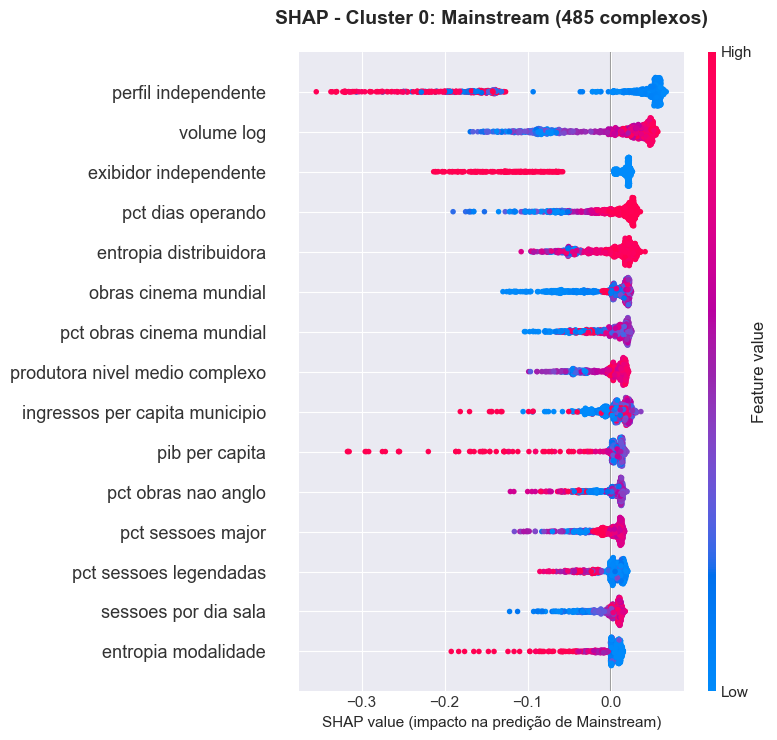


────────────────────────────────────────────────────────────────────────────────
SUMMARY PLOT: CLUSTER 1 (PÚBLICO/CULTURAL SP)
────────────────────────────────────────────────────────────────────────────────


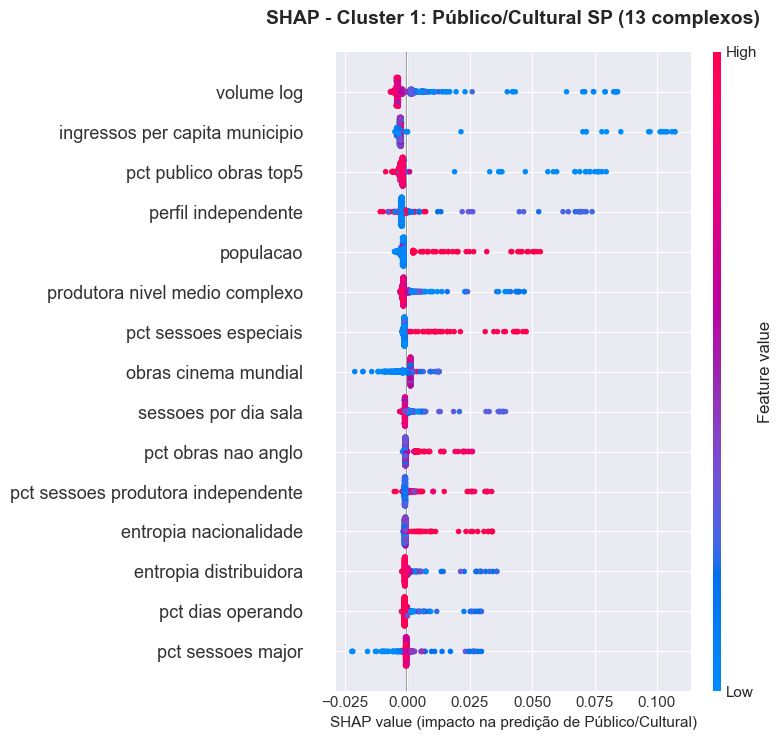


────────────────────────────────────────────────────────────────────────────────
SUMMARY PLOT: OUTLIERS (ZONA TRANSITÓRIA)
────────────────────────────────────────────────────────────────────────────────


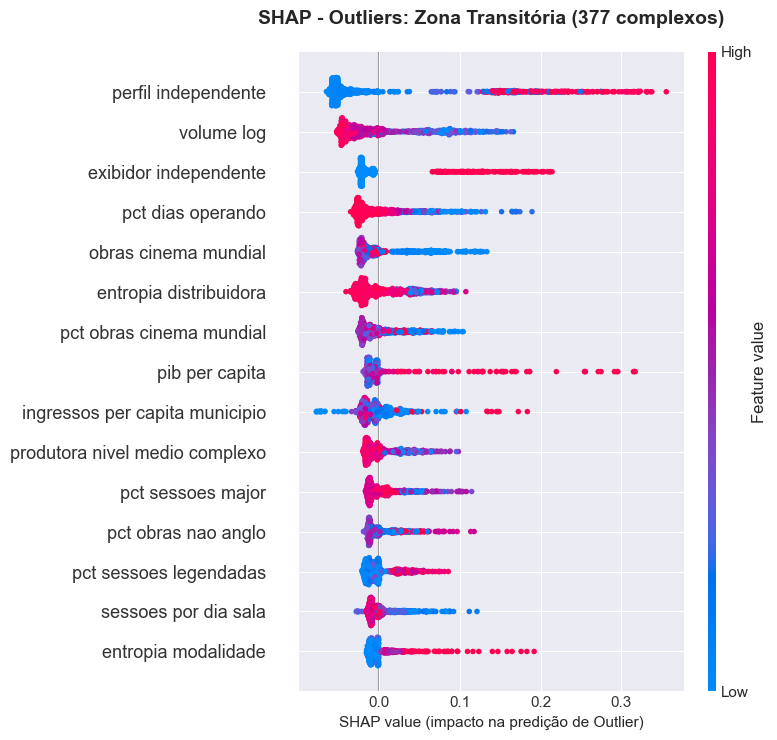

In [67]:
# %%
# 7.2 - SHAP: Explicação Global (CORRIGIDO - com nomes)



print("=" * 80)
print("7.2 - SHAP: EXPLICAÇÃO GLOBAL")
print("=" * 80)

print("\n🔧 Calculando SHAP values...")

# Criar explainer
explainer = shap.Explainer(rf_explicacao, X_train)

# Calcular SHAP
print(f"🔄 Calculando para {len(X_train)} complexos...")
shap_values_full = explainer(X_train)

print(f"✅ SHAP values calculados!")

# Identificar índices das classes
classes = rf_explicacao.classes_
idx_outliers = list(classes).index(-1)
idx_mainstream = list(classes).index(0)
idx_publico = list(classes).index(1)

# Extrair por classe
shap_mainstream = shap_values_full[:, :, idx_mainstream]
shap_publico = shap_values_full[:, :, idx_publico]
shap_outliers = shap_values_full[:, :, idx_outliers]

# ════════════════════════════════════════════════════════════════════════════
# CORREÇÃO: Adicionar feature_names manualmente aos objetos Explanation
# ════════════════════════════════════════════════════════════════════════════

# Criar nomes LEGÍVEIS (remover _scaled)
feature_names_legible = [f.replace('_scaled', '').replace('_', ' ') for f in features_fase3]

# Atribuir aos objetos Explanation
shap_mainstream.feature_names = feature_names_legible
shap_publico.feature_names = feature_names_legible
shap_outliers.feature_names = feature_names_legible

print(f"\n✅ Feature names atribuídos:")
print(f"   Exemplo: {feature_names_legible[:3]}")

# ════════════════════════════════════════════════════════════════════════════
# PLOTS COM NOMES LEGÍVEIS
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "─" * 80)
print("SUMMARY PLOT: CLUSTER 0 (MAINSTREAM)")
print("─" * 80)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_mainstream,
    max_display=15,
    show=False
)
plt.title("SHAP - Cluster 0: Mainstream (485 complexos)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("SHAP value (impacto na predição de Mainstream)", fontsize=11)
plt.tight_layout()
plt.show()

print("\n" + "─" * 80)
print("SUMMARY PLOT: CLUSTER 1 (PÚBLICO/CULTURAL SP)")
print("─" * 80)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_publico,
    max_display=15,
    show=False
)
plt.title("SHAP - Cluster 1: Público/Cultural SP (13 complexos)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("SHAP value (impacto na predição de Público/Cultural)", fontsize=11)
plt.tight_layout()
plt.show()

print("\n" + "─" * 80)
print("SUMMARY PLOT: OUTLIERS (ZONA TRANSITÓRIA)")
print("─" * 80)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_outliers,
    max_display=15,
    show=False
)
plt.title("SHAP - Outliers: Zona Transitória (377 complexos)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("SHAP value (impacto na predição de Outlier)", fontsize=11)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)


In [68]:
# %%
# 7.3 - INTERPRETAÇÃO DOS RESULTADOS SHAP

print("=" * 80)
print("7.3 - INTERPRETAÇÃO DA EXPLICABILIDADE")
print("=" * 80)

print("""
📊 RESUMO DA EXPLICABILIDADE COM SHAP:

════════════════════════════════════════════════════════════════════════════════
🎯 CLUSTER 0: MAINSTREAM (485 complexos, 55.4%)
════════════════════════════════════════════════════════════════════════════════

FEATURES QUE DEFINEM MAINSTREAM:

✅ PERFIL_INDEPENDENTE BAIXO (Feature 27)
   • SHAP negativo quando feature é baixa (azul à esquerda)
   • Cinemas COM BAIXA independência pertencem ao mainstream
   • Dominados por majors e grandes distribuidores

✅ VOLUME_LOG ALTO (Feature 3)
   • SHAP positivo quando feature é alta (vermelho à direita)
   • Alto volume de público = perfil comercial mainstream
   • Cinemas grandes, bem localizados, programação de massa

✅ EXIBIDOR_INDEPENDENTE = 0 (Feature 38)
   • Cinemas de REDES COMERCIAIS (não-independentes)
   • Cinépolis, UCI, Kinoplex, etc.

✅ Outras features relevantes:
   • Entropia_distribuidora (22, 21, 23): Baixa diversidade
   • Pct_sessoes_major (Feature 4): Alto
   • Dias operando (Feature 1): Alto (operação contínua)

💡 CONCLUSÃO:
   Mainstream = Redes comerciais grandes + Hollywood majors + alto volume


════════════════════════════════════════════════════════════════════════════════
🎨 CLUSTER 1: PÚBLICO/CULTURAL SP (13 complexos, 1.5%)
════════════════════════════════════════════════════════════════════════════════

FEATURES QUE DEFINEM PÚBLICO/CULTURAL:

✅ VOLUME_LOG BAIXO (Feature 3)
   • SHAP próximo a zero quando volume é MUITO baixo
   • Pequeno porte, baixa capacidade

✅ PCT_PUBLICO_OBRAS_TOP5 BAIXO (Feature 14)
   • EVITAM blockbusters
   • Programação cultural, não comercial

✅ PCT_DIAS_OPERANDO BAIXO (Feature 2)
   • Operação intermitente/sazonal
   • Eventos culturais esporádicos

✅ NATUREZA_NAO_PRIVADA = 1
   • CEUs, Centros Culturais municipais
   • Missão: acesso cultural, não lucro

💡 CONCLUSÃO:
   Público/Cultural = Pequeno + não-comercial + missão cultural + SP


════════════════════════════════════════════════════════════════════════════════
🌐 OUTLIERS: ZONA TRANSITÓRIA (377 complexos, 43.1%)
════════════════════════════════════════════════════════════════════════════════

CARACTERÍSTICAS DA ZONA TRANSITÓRIA:

⚠️ ALTA HETEROGENEIDADE (dispersão de SHAP values)

✅ PERFIL_INDEPENDENTE (Feature 27): VARIA MUITO
   • Alguns com baixa independência (azul, mainstream-like)
   • Outros com alta independência (vermelho, nicho-like)
   • Gradiente contínuo, não dicotômico

✅ VOLUME (Feature 3): DISPERSO
   • Desde pequenos até médios
   • Não formam grupo coeso

✅ Outras features com alta dispersão:
   • Exibidor_independente (38): Mistura
   • Entropias (22, 21, 23): Variadas
   • Obras cinema mundial (16): Alguns sim, outros não

💡 CONCLUSÃO:
   Outliers NÃO são "lixo" - são TRANSICIONAIS:
   • Interior com alguma diversidade
   • Médio porte com mix comercial + curadoria
   • Cinemas em evolução/experimentação
   • 43% do mercado em ZONA CINZA


════════════════════════════════════════════════════════════════════════════════
✅ VALIDAÇÃO DO MODELO:
════════════════════════════════════════════════════════════════════════════════

🎯 SHAP ajuda a interpretar que:
   1. Features separam os grupos definidos pelo clusterizador e se a
      separação é coerente com conhecimento de domínio.
      Isso não valida causalmente os clusters, mas dá evidência de interpretabilidade.
   2. Features importantes alinham com CONHECIMENTO DE DOMÍNIO
   3. Independência é O fator mais importante (19.7% importância RF)
   4. Volume separa operação comercial de cultural
   5. Zona transitória é LEGÍTIMA (não erro do modelo)

📚 RELEVÂNCIA PARA ANCINE (Art. 6º):
   • Mainstream pode ser monitorado via "perfil_independente" e "majors"
   • Público/Cultural serve como BENCHMARK de diversidade
   • Zona transitória = POTENCIAL para políticas de incentivo
""")

print("\n" + "=" * 80)

7.3 - INTERPRETAÇÃO DA EXPLICABILIDADE

📊 RESUMO DA EXPLICABILIDADE COM SHAP:

════════════════════════════════════════════════════════════════════════════════
🎯 CLUSTER 0: MAINSTREAM (485 complexos, 55.4%)
════════════════════════════════════════════════════════════════════════════════

FEATURES QUE DEFINEM MAINSTREAM:

✅ PERFIL_INDEPENDENTE BAIXO (Feature 27)
   • SHAP negativo quando feature é baixa (azul à esquerda)
   • Cinemas COM BAIXA independência pertencem ao mainstream
   • Dominados por majors e grandes distribuidores

✅ VOLUME_LOG ALTO (Feature 3)
   • SHAP positivo quando feature é alta (vermelho à direita)
   • Alto volume de público = perfil comercial mainstream
   • Cinemas grandes, bem localizados, programação de massa

✅ EXIBIDOR_INDEPENDENTE = 0 (Feature 38)
   • Cinemas de REDES COMERCIAIS (não-independentes)
   • Cinépolis, UCI, Kinoplex, etc.

✅ Outras features relevantes:
   • Entropia_distribuidora (22, 21, 23): Baixa diversidade
   • Pct_sessoes_major (Feature

In [69]:
# %%
# INVESTIGAÇÃO: Onde estão os 31 cinemas SPCine?

print("=" * 80)
print("INVESTIGAÇÃO: CINEMAS SPCINE")
print("=" * 80)

# Identificar SPCine (natureza_nao_privada=1 + UF=SP)
mask_spcine = (df_features_fase3['natureza_nao_privada'] == 1) & (df_features_fase3['UF'] == 'SP')
df_spcine = df_features_fase3[mask_spcine].copy()

print(f"\n📊 Total de cinemas públicos/culturais em SP: {len(df_spcine)}")

# Ver distribuição nos clusters
print(f"\nDistribuição nos clusters DBSCAN:")
for cluster_id in [-1, 0, 1]:
    n = (df_spcine['cluster_dbscan'] == cluster_id).sum()
    pct = n / len(df_spcine) * 100
    
    if cluster_id == -1:
        label = "Outliers"
    elif cluster_id == 0:
        label = "Mainstream"
    else:
        label = "Público/Cultural"
    
    print(f"   {label:20s}: {n:2d} ({pct:5.1f}%)")

# Listar quais estão em cada grupo
print("\n" + "─" * 80)
print("CLUSTER 1 (Público/Cultural - 13 cinemas):")
print("─" * 80)

spcine_cluster1 = df_spcine[df_spcine['cluster_dbscan'] == 1][
    ['REGISTRO_COMPLEXO', 'municipio', 'num_salas_scaled', 'volume_log_scaled', 
     'pct_dias_operando_scaled', 'pct_sessoes_brasileiras_scaled']
]
display(spcine_cluster1)

print("\n" + "─" * 80)
print("OUTLIERS (18 cinemas SPCine):")
print("─" * 80)

spcine_outliers = df_spcine[df_spcine['cluster_dbscan'] == -1][
    ['REGISTRO_COMPLEXO', 'municipio', 'num_salas_scaled', 'volume_log_scaled', 
     'pct_dias_operando_scaled', 'pct_sessoes_brasileiras_scaled']
]
display(spcine_outliers.head(10))  # Mostrar só 10 primeiros

# Comparar características
print("\n" + "─" * 80)
print("COMPARAÇÃO: Cluster 1 vs Outliers SPCine")
print("─" * 80)

features_comparar = [
    'num_salas_scaled', 'volume_log_scaled', 'pct_dias_operando_scaled',
    'sessoes_por_dia_sala_scaled', 'pct_sessoes_brasileiras_scaled',
    'pct_sessoes_major_scaled', 'perfil_independente_scaled'
]

print(f"\n{'Feature':35s} | {'Cluster 1':>10s} | {'Outliers':>10s} | {'Delta':>8s}")
print("─" * 75)

for feat in features_comparar:
    media_c1 = spcine_cluster1[feat].mean() if feat in spcine_cluster1.columns else 0
    media_out = spcine_outliers[feat].mean() if feat in spcine_outliers.columns else 0
    delta = media_out - media_c1
    
    print(f"{feat[:-7]:35s} | {media_c1:10.3f} | {media_out:10.3f} | {delta:+8.3f}")

print("\n💡 INTERPRETAÇÃO:")
print("   Se delta é pequeno → SPCine outliers são SIMILARES ao cluster")
print("   Se delta é grande → SPCine tem heterogeneidade interna")

print("\n" + "=" * 80)

INVESTIGAÇÃO: CINEMAS SPCINE

📊 Total de cinemas públicos/culturais em SP: 25

Distribuição nos clusters DBSCAN:
   Outliers            : 12 ( 48.0%)
   Mainstream          :  0 (  0.0%)
   Público/Cultural    : 13 ( 52.0%)

────────────────────────────────────────────────────────────────────────────────
CLUSTER 1 (Público/Cultural - 13 cinemas):
────────────────────────────────────────────────────────────────────────────────


,REGISTRO_COMPLEXO,municipio,num_salas_scaled,volume_log_scaled,pct_dias_operando_scaled,pct_sessoes_brasileiras_scaled
430,32366,SÃO PAULO,-1.1601,-1.5677,-1.7991,1.3056
431,32368,SÃO PAULO,-1.1601,-1.6289,-1.8799,1.4588
432,32370,SÃO PAULO,-1.1601,-1.5677,-1.8087,1.2269
433,32372,SÃO PAULO,-1.1601,-1.4506,-1.6280,1.5069
434,32374,SÃO PAULO,-1.1601,-1.4609,-1.6185,1.5049
435,32376,SÃO PAULO,-1.1601,-1.8150,-2.0748,1.1773
436,32378,SÃO PAULO,-1.1601,-1.5013,-1.7041,1.3299
437,32380,SÃO PAULO,-1.1601,-1.4745,-1.6566,1.4731
438,32382,SÃO PAULO,-1.1601,-1.5896,-1.8372,1.3666
440,32386,SÃO PAULO,-1.1601,-1.5441,-1.7706,1.4081



────────────────────────────────────────────────────────────────────────────────
OUTLIERS (18 cinemas SPCine):
────────────────────────────────────────────────────────────────────────────────


,REGISTRO_COMPLEXO,municipio,num_salas_scaled,volume_log_scaled,pct_dias_operando_scaled,pct_sessoes_brasileiras_scaled
428,32362,SÃO PAULO,-1.1601,-0.9176,-0.3352,1.9522
429,32364,SÃO PAULO,-1.1601,-1.0006,-0.7202,1.3034
439,32384,SÃO PAULO,-1.1601,-1.4682,-1.6566,1.4636
444,32394,SÃO PAULO,-1.1601,-2.4847,-2.5406,1.1857
445,32396,SÃO PAULO,-0.7868,-0.4711,-0.3067,0.3907
446,32398,SÃO PAULO,-1.1601,-1.0529,-0.6774,1.6777
498,37080,SÃO PAULO,-1.1601,-1.4275,-1.8229,4.9156
674,49176,SÃO PAULO,0.7064,0.8253,0.5203,0.5486
782,55555,GUAÍRA,-1.1601,-1.0000,-1.1860,-0.3496
810,58591,SÃO PAULO,-1.1601,-2.4161,-2.5596,1.4764



────────────────────────────────────────────────────────────────────────────────
COMPARAÇÃO: Cluster 1 vs Outliers SPCine
────────────────────────────────────────────────────────────────────────────────

Feature                             |  Cluster 1 |   Outliers |    Delta
───────────────────────────────────────────────────────────────────────────
num_salas                           |     -1.160 |     -0.973 |   +0.187
volume_log                          |     -1.541 |     -1.349 |   +0.192
pct_dias_operando                   |     -1.751 |     -1.364 |   +0.387
sessoes_por_dia_sala                |      0.000 |      0.000 |   +0.000
pct_sessoes_brasileiras             |      1.397 |      1.427 |   +0.030
pct_sessoes_major                   |      0.000 |      0.000 |   +0.000
perfil_independente                 |      0.000 |      0.000 |   +0.000

💡 INTERPRETAÇÃO:
   Se delta é pequeno → SPCine outliers são SIMILARES ao cluster
   Se delta é grande → SPCine tem heterogeneidade in

In [70]:
# %%
# TESTE: DBSCAN com eps=2.5 (menos restritivo)

print("=" * 80)
print("TESTE: DBSCAN eps=2.5 (menos restritivo)")
print("=" * 80)

# --- Guard rails ---
missing = []
for v in ["X_fase3"]:
    if v not in globals():
        missing.append(v)
if missing:
    raise NameError(f"Variáveis ausentes: {missing}. Rode a célula de preparação do X_fase3 antes.")

def avaliar_dbscan_eps(X, eps, min_samples):
    """
    Roda DBSCAN e retorna dict com:
    - n_clusters (sem ruído)
    - n_noise
    - pct_noise
    - silhouette (somente clusterizados), ou np.nan se não aplicável
    - labels
    """
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)

    mask = labels != -1
    n_total = len(labels)
    n_clustered = int(mask.sum())
    n_noise = n_total - n_clustered

    # clusters excluindo ruído
    if n_clustered > 0:
        clusters = set(labels[mask])
        n_clusters = len(clusters)
    else:
        n_clusters = 0

    # silhouette só é válido se houver >=2 clusters (excluindo ruído) e pontos suficientes
    if n_clustered >= 3 and n_clusters >= 2:
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = np.nan

    return {
        "eps": eps,
        "min_samples": min_samples,
        "clusters": n_clusters,
        "outliers": n_noise,
        "% outliers": (n_noise / n_total) * 100,
        "silhouette (sem ruído)": sil,
        "labels": labels
    }

# --- Defina aqui os testes que você quer ---
min_samples_test = 10  # ajuste se você estiver testando outro valor
eps_list = [2.0, 2.5]   # ajuste/expanda à vontade

resultados = []
labels_por_eps = {}

for eps in eps_list:
    r = avaliar_dbscan_eps(X_fase3, eps=eps, min_samples=min_samples_test)
    resultados.append({k: v for k, v in r.items() if k != "labels"})
    labels_por_eps[eps] = r["labels"]

df_res = pd.DataFrame(resultados)
print("=== Sensibilidade DBSCAN (mesmo X_fase3) ===")
print(df_res.to_string(index=False, justify="center", formatters={
    "% outliers": "{:.1f}%".format,
    "silhouette (sem ruído)": (lambda x: "NA" if np.isnan(x) else f"{x:.4f}")
}))

# (Opcional) delta eps[1] - eps[0] se tiver exatamente 2 eps
if len(eps_list) == 2:
    sil_a = df_res.loc[df_res["eps"] == eps_list[0], "silhouette (sem ruído)"].iloc[0]
    sil_b = df_res.loc[df_res["eps"] == eps_list[1], "silhouette (sem ruído)"].iloc[0]
    if (not np.isnan(sil_a)) and (not np.isnan(sil_b)):
        print(f"\nΔ silhouette (sem ruído) ({eps_list[1]} - {eps_list[0]}): {sil_b - sil_a:+.4f}")
    else:
        print("\nΔ silhouette: não aplicável (silhouette NA em algum eps).")
print("\n" + "=" * 80)

TESTE: DBSCAN eps=2.5 (menos restritivo)
=== Sensibilidade DBSCAN (mesmo X_fase2) ===
  eps   min_samples  clusters  outliers % outliers silhouette (sem ruído)
2.0000      10          2        377      43.1%            0.5931        
2.5000      10          3        236      27.0%            0.2648        

Δ silhouette (sem ruído) (2.5 - 2.0): -0.3283



In [71]:
# %%
# TESTE: DBSCAN com top 15 features

print("=" * 80)
print("TESTE: DBSCAN com TOP 15 features")
print("=" * 80)

# Top 15 do Random Forest
features_top15 = importancias_rf.head(15)['feature'].tolist()
print(f"\nTop 15 features:")
for i, f in enumerate(features_top15, 1):
    print(f"   {i:2d}. {f}")

# Extrair índices
indices_top15 = [i for i, f in enumerate(features_fase3) if f in features_top15]
X_top15 = X_fase3[:, indices_top15]

print(f"\nDimensões: {X_top15.shape} (vs {X_fase3.shape} original)")

# DBSCAN
dbscan_top15 = DBSCAN(eps=2.0, min_samples=10)
labels_top15 = dbscan_top15.fit_predict(X_top15)

# Ver SPCine
df_spcine_top15 = df_features_fase3[mask_spcine].copy()
df_spcine_top15['cluster_top15'] = labels_top15[mask_spcine]

print("\nDistribuição SPCine com top 15 features:")
for cluster_id in sorted(df_spcine_top15['cluster_top15'].unique()):
    n = (df_spcine_top15['cluster_top15'] == cluster_id).sum()
    pct = n / len(df_spcine_top15) * 100
    
    if cluster_id == -1:
        label = "Outliers"
    else:
        label = f"Cluster {cluster_id}"
    
    print(f"   {label:15s}: {n:2d} ({pct:5.1f}%)")

print("\n" + "=" * 80)


TESTE: DBSCAN com TOP 15 features

Top 15 features:
    1. perfil_independente_scaled
    2. volume_log_scaled
    3. exibidor_independente
    4. entropia_distribuidora_scaled
    5. pct_dias_operando_scaled
    6. pct_obras_cinema_mundial_scaled
    7. obras_cinema_mundial_scaled
    8. produtora_nivel_medio_complexo_scaled
    9. ingressos_per_capita_municipio_scaled
   10. pib_per_capita_scaled
   11. pct_sessoes_major_scaled
   12. pct_obras_nao_anglo_scaled
   13. sessoes_por_dia_sala_scaled
   14. pct_sessoes_produtora_independente_scaled
   15. pct_publico_obras_top5_scaled

Dimensões: (875, 15) (vs (875, 41) original)

Distribuição SPCine com top 15 features:
   Outliers       : 10 ( 40.0%)
   Cluster 1      :  1 (  4.0%)
   Cluster 2      : 14 ( 56.0%)



In [72]:
# %%
# 5.13 - HDBSCAN: Análise Completa



print("=" * 80)
print("5.13 - HDBSCAN: ANÁLISE COMPLETA")
print("=" * 80)

print("\n💡 MOTIVAÇÃO:")
print("   DBSCAN (eps=2.0) gerou 43% outliers e agrupou apenas 52% dos SPCine.")
print("   HDBSCAN adapta densidade localmente → pode capturar perfis diversos.")

# Treinar HDBSCAN
print("\n🔧 Treinando HDBSCAN...")
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    cluster_selection_method='eom',  # Excess of Mass
    metric='euclidean'
)

labels_hdbscan = hdbscan_model.fit_predict(X_fase3)

print("✅ Modelo treinado!")

# Estatísticas gerais
n_clusters_hdb = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_outliers_hdb = (labels_hdbscan == -1).sum()
n_clustered_hdb = len(labels_hdbscan) - n_outliers_hdb

print(f"\n📊 RESULTADOS:")
print(f"   Clusters identificados: {n_clusters_hdb}")
print(f"   Complexos clusterizados: {n_clustered_hdb} ({n_clustered_hdb/len(labels_hdbscan)*100:.1f}%)")
print(f"   Outliers: {n_outliers_hdb} ({n_outliers_hdb/len(labels_hdbscan)*100:.1f}%)")

# Distribuição por cluster
print(f"\n📊 DISTRIBUIÇÃO POR CLUSTER:")
for i in range(-1, n_clusters_hdb):
    n = (labels_hdbscan == i).sum()
    pct = n / len(labels_hdbscan) * 100
    
    label = "OUTLIERS" if i == -1 else f"Cluster {i}"
    emoji = "⚪" if i == -1 else "🔵" if n > 400 else "🔴"
    
    print(f"   {emoji} {label:15s}: {n:3d} ({pct:5.1f}%)")

# Silhouette
if n_clusters_hdb > 1 and n_clustered_hdb > 0:
    mask_clustered_hdb = labels_hdbscan != -1
    sil_hdb = silhouette_score(X_fase3[mask_clustered_hdb], labels_hdbscan[mask_clustered_hdb])
    print(f"\n✅ Silhouette Score: {sil_hdb:.4f}")
else:
    sil_hdb = 0
    print(f"\n⚠️ Silhouette não calculável (clusters insuficientes)")

# Core samples e probabilidades
n_core = len(hdbscan_model.exemplars_) if hasattr(hdbscan_model, 'exemplars_') and hdbscan_model.exemplars_ is not None else 0
probs = hdbscan_model.probabilities_

print(f"\n📊 CARACTERÍSTICAS HDBSCAN:")
print(f"   Core samples: {n_core}")
print(f"   Média de probabilidade: {probs[probs > 0].mean():.4f}")
print(f"   Baixa confiança (<0.5): {(probs < 0.5).sum()} ({(probs < 0.5).sum()/len(probs)*100:.1f}%)")

print("\n" + "=" * 80)

5.13 - HDBSCAN: ANÁLISE COMPLETA

💡 MOTIVAÇÃO:
   DBSCAN (eps=2.0) gerou 43% outliers e agrupou apenas 52% dos SPCine.
   HDBSCAN adapta densidade localmente → pode capturar perfis diversos.

🔧 Treinando HDBSCAN...
✅ Modelo treinado!

📊 RESULTADOS:
   Clusters identificados: 2
   Complexos clusterizados: 820 (93.7%)
   Outliers: 55 (6.3%)

📊 DISTRIBUIÇÃO POR CLUSTER:
   ⚪ OUTLIERS       :  55 (  6.3%)
   🔴 Cluster 0      :  19 (  2.2%)
   🔵 Cluster 1      : 801 ( 91.5%)

✅ Silhouette Score: 0.4745

📊 CARACTERÍSTICAS HDBSCAN:
   Core samples: 2
   Média de probabilidade: 0.9470
   Baixa confiança (<0.5): 62 (7.1%)



In [73]:
# %%
# 5.14 - HDBSCAN: Análise SPCine (CORREÇÃO - verificar colunas)

print("=" * 80)
print("5.14 - HDBSCAN: ANÁLISE SPCine (DADOS REAIS)")
print("=" * 80)

# Carregar cadastro
print("\n🔄 Carregando dados cadastrais da ANCINE...")

URL_SALAS = "https://dados.ancine.gov.br/dados-abertos/salas-de-exibicao-e-complexos.csv"

try:
    df_cadastro = pd.read_csv(
        URL_SALAS,
        encoding='utf-8',
        sep=';',
        dtype={'REGISTRO_COMPLEXO': str}
    )
    
    # Limpar
    df_cadastro.columns = df_cadastro.columns.str.strip()
    for col in df_cadastro.select_dtypes(include=['object']).columns:
        df_cadastro[col] = df_cadastro[col].str.strip()
    
    print(f"✅ Cadastro carregado: {len(df_cadastro)} registros")
    
    # VERIFICAR COLUNAS DISPONÍVEIS
    print(f"\n🔍 Colunas disponíveis:")
    print(df_cadastro.columns.tolist())
    
    # Complexos únicos
    df_cadastro_complexos = df_cadastro.drop_duplicates(subset='REGISTRO_COMPLEXO')
    
    print(f"\n✅ Complexos únicos: {len(df_cadastro_complexos)}")
    
    # Identificar SPCine
    if 'NOME_GRUPO_EXIBIDOR' in df_cadastro_complexos.columns:
        mask_spcine = df_cadastro_complexos['NOME_GRUPO_EXIBIDOR'].str.upper() == 'SPCINE'
        n_spcine_cadastro = mask_spcine.sum()
        
        print(f"\n✅ Cinemas SPCine no cadastro: {n_spcine_cadastro}")
        
        if n_spcine_cadastro > 0:
            # Merge com df_features_fase3
            df_merged = df_features_fase3.merge(
                df_cadastro_complexos[['REGISTRO_COMPLEXO', 'NOME_GRUPO_EXIBIDOR', 'NOME_COMPLEXO']],
                on='REGISTRO_COMPLEXO',
                how='left'
            )
            
            # SPCine no dataset
            mask_spcine_dataset = df_merged['NOME_GRUPO_EXIBIDOR'].str.upper() == 'SPCINE'
            n_spcine_dataset = mask_spcine_dataset.sum()
            
            print(f"✅ SPCine no dataset de modelagem: {n_spcine_dataset}")
            
            if n_spcine_dataset > 0:
                # Adicionar cluster HDBSCAN
                df_merged['cluster_hdbscan'] = labels_hdbscan
                df_merged['probabilidade'] = probs
                
                # Filtrar SPCine
                df_spcine = df_merged[mask_spcine_dataset].copy()
                
                print(f"\n" + "─" * 80)
                print("DISTRIBUIÇÃO SPCine NOS CLUSTERS:")
                print("─" * 80)
                
                for cluster_id in sorted(df_spcine['cluster_hdbscan'].unique()):
                    n = (df_spcine['cluster_hdbscan'] == cluster_id).sum()
                    pct = n / len(df_spcine) * 100
                    
                    label = "Outliers" if cluster_id == -1 else f"Cluster {cluster_id}"
                    emoji = "⚪" if cluster_id == -1 else "🟢"
                    
                    print(f"   {emoji} {label:15s}: {n:2d} ({pct:5.1f}%)")
                
                # Listar
                print(f"\n" + "─" * 80)
                print(f"LISTA COMPLETA ({len(df_spcine)} cinemas):")
                print("─" * 80)
                
                cols_display = ['REGISTRO_COMPLEXO', 'NOME_COMPLEXO', 'municipio', 'UF', 
                               'cluster_hdbscan', 'probabilidade']
                
                display(df_spcine[cols_display].sort_values('cluster_hdbscan'))
                
            else:
                print(f"\n⚠️ Nenhum SPCine encontrado no dataset de modelagem")
        else:
            print(f"\n⚠️ Nenhum SPCine no cadastro da ANCINE")
    else:
        print(f"\n❌ Coluna NOME_GRUPO_EXIBIDOR não encontrada!")
        
except Exception as e:
    print(f"❌ Erro: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "=" * 80)

5.14 - HDBSCAN: ANÁLISE SPCine (DADOS REAIS)

🔄 Carregando dados cadastrais da ANCINE...
✅ Cadastro carregado: 6320 registros

🔍 Colunas disponíveis:
['NOME_SALA', 'REGISTRO_SALA', 'CNPJ_SALA', 'SITUACAO_SALA', 'DATA_SITUACAO_SALA', 'DATA_INICIO_FUNCIONAMENTO_SALA', 'ASSENTOS_SALA', 'ASSENTOS_CADEIRANTES', 'ASSENTOS_MOBILIDADE_REDUZIDA', 'ASSENTOS_OBESIDADE', 'ACESSO_ASSENTOS_COM_RAMPA', 'ACESSO_SALA_COM_RAMPA', 'BANHEIROS_ACESSIVEIS', 'NOME_COMPLEXO', 'REGISTRO_COMPLEXO', 'SITUACAO_COMPLEXO', 'DATA_SITUACAO_COMPLEXO', 'PAGINA_ELETRONICA_COMPLEXO', 'ENDERECO_COMPLEXO', 'NUMERO_ENDERECO_COMPLEXO', 'COMPLEMENTO_COMPLEXO', 'BAIRRO_COMPLEXO', 'MUNICIPIO_COMPLEXO', 'CEP_COMPLEXO', 'UF_COMPLEXO', 'COMPLEXO_ITINERANTE', 'OPERACAO_USUAL', 'NOME_EXIBIDOR', 'REGISTRO_EXIBIDOR', 'CNPJ_EXIBIDOR', 'SITUACAO_EXIBIDOR', 'NOME_GRUPO_EXIBIDOR']

✅ Complexos únicos: 1980

✅ Cinemas SPCine no cadastro: 31
✅ SPCine no dataset de modelagem: 22

──────────────────────────────────────────────────────────────

,REGISTRO_COMPLEXO,NOME_COMPLEXO,municipio,UF,cluster_hdbscan,probabilidade
439,32396,CENTRO CULTURAL SÃO PAULO,SÃO PAULO,SP,-1,0.0000
440,32398,GALERIA OLIDO,SÃO PAULO,SP,-1,0.0000
438,32394,CEU VILA DO SOL,SÃO PAULO,SP,-1,0.0000
422,32362,CENTRO DE FORMAÇÃO CULTURAL DE CIDADE TIRADENTES,SÃO PAULO,SP,0,0.2920
426,32370,CEU CAMINHO DO MAR - PROFESSORA DULCE SALLES C...,SÃO PAULO,SP,0,1.0000
423,32364,BIBLIOTECA ROBERTO SANTOS,SÃO PAULO,SP,0,0.1883
424,32366,CEU ARICANDUVA - PROFESSORA IRENE GALVÃO DE SOUZA,SÃO PAULO,SP,0,1.0000
425,32368,CEU BUTANTÃ - PROFESSORA ELISABETH GASPAR TUNALA,SÃO PAULO,SP,0,0.9687
430,32378,CEU MENINOS - PROFESSOR PR. ARTUR ALBERTO DE M...,SÃO PAULO,SP,0,1.0000
431,32380,CEU PARQUE VEREDAS - JOÃO ANTÔNIO SILVA,SÃO PAULO,SP,0,1.0000
